In [2]:
import pandas as pd
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)
data.columns.tolist()

['PTNO',
 'BIRTHDT',
 'SEX',
 'DATEOFDX',
 'RACE',
 'LCDT',
 'STATUS',
 'DEATHDT',
 'INCEPT',
 'ID',
 'ASSDT',
 'EMP',
 'visit_num',
 'total_visits',
 'startdate',
 'time_first_last',
 'time_between',
 'EMPf',
 'initial_emp',
 'final_emp',
 'visit_num96',
 'total_visits96',
 'time_first_last96',
 'time_between96',
 'changed',
 'time_to_first_change',
 'SLED1_I',
 'SLED2_I',
 'SLED3_I',
 'SLED4_I',
 'SLED5_I',
 'SLED6_I',
 'SLED7_I',
 'SLED8_I',
 'SLED9_I',
 'SLED10_I',
 'SLED11_I',
 'SLED12_I',
 'SLED13_I',
 'SLED14_I',
 'SLED15_I',
 'SLED16_I',
 'SLED17_I',
 'SLED18_I',
 'SLED19_I',
 'SLED20_I',
 'SLED21_I',
 'SLED22_I',
 'SLED23_I',
 'SLED24_I',
 'SLEDAI2_I',
 'ACATARACT',
 'RETOPT',
 'COGNIMP',
 'SEIZURX6',
 'CERVASAC',
 'CPNEUR',
 'TRANMYEL',
 'GFR50',
 'PROT24',
 'ENDRENAL',
 'PULMHYP',
 'PULMFIBR',
 'SHRINKL',
 'PLEURFIBR',
 'PULMINF',
 'ANGBYP',
 'MYOCARINF',
 'CARDMYOP',
 'VALVULAR',
 'PERICARD6',
 'CLAUDIC',
 'MINORTL',
 'SIGNIFTL',
 'VENTHROMB',
 'INFRESEC',
 'MESENINS',
 'PE

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold


# Load the data - removed duplicate load
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)
origdata =  pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)
# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['severe_flare', 'mild_flare', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'AGE_DX', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n', "AMS",  'SLED1_I', 'SLED2_I', 'SLED3_I', 'SLED4_I', 'SLED5_I', 'SLED6_I',
            'SLED7_I', 'SLED8_I', 'SLED9_I', 'SLED10_I', 'SLED11_I', 'SLED12_I', 'SLED13_I', 'SLED14_I', 'SLED15_I',
            'SLED16_I', 'SLED17_I', 'SLED18_I', 'SLED19_I', 'SLED20_I', 'SLED21_I', 'SLED22_I', 'SLED23_I', 'SLED24_I',
            'SLEDAI2_I', 'ACATARACT', 'RETOPT', 'COGNIMP', 'SEIZURX6', 'CERVASAC', 'CPNEUR', 'TRANMYEL',
            'GFR50', 'PROT24', 'ENDRENAL', 'PULMHYP', 'PULMFIBR', 'SHRINKL', 'PLEURFIBR', 'PULMINF', 'ANGBYP',
            'MYOCARINF', 'CARDMYOP', 'VALVULAR', 'PERICARD6','CLAUDIC', 'MINORTL', 'SIGNIFTL', 'VENTHROMB',
            'INFRESEC', 'MESENINS', 'PERITONIT', 'STRICTURE', 'PANCREAT', 'ATROPHY', 'DEARTHRIT', 'OSTEOPOR',
            'AVASCNEC', 'OSTEOMYEL', 'RUPTEND','ALOPECIA','EXTSCARR',
             'SKULCER','GONADALF','DIABETES','MALIGNAN']  # Added score_n (SDI)

# Add total flares feature
data['total_flare'] = data['severe_flare'] + data['mild_flare']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flare']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flare']

# Add temporal features

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flare', 'mild_flare']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
# [Previous data loading and preprocessing code remains the same until sequence creation]

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y from one-hot encoded to labels for stratified k-fold
y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y  # Handle both one-hot and label encoded

# Initialize cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
cv_results = {
    'val_accuracy': [],
    'val_loss': [],
    'test_preds': [],
    'models': []
}

# Create a test set that will be used for final evaluation
X_train_all, X_test, y_train_all, y_test, seq_train_all, seq_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=y_labels)

# Cross-validation loop (on the training data only)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, np.argmax(y_train_all, axis=1))):
    print(f"\nTraining fold {fold + 1}/{n_splits}")
    
    # Split data
    X_train, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_train, y_val = y_train_all[train_idx], y_train_all[val_idx]
    
    # Calculate class weights
    classes = np.unique(np.argmax(y_train, axis=1))
    class_weights = compute_class_weight('balanced', classes=classes, y=np.argmax(y_train, axis=1))
    class_weight_dict = dict(enumerate(class_weights))
    
    # Build model
    model = Sequential([
        Masking(mask_value=0., input_shape=(None, len(features))),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(y.shape[1], activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store results
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_loss'].append(val_loss)
    cv_results['models'].append(model)
    
    print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Print cross-validation results
print("\nCross-Validation Results:")
print(f"Mean Val Accuracy: {np.mean(cv_results['val_accuracy']):.4f} (±{np.std(cv_results['val_accuracy']):.4f})")
print(f"Mean Val Loss: {np.mean(cv_results['val_loss']):.4f} (±{np.std(cv_results['val_loss']):.4f})")

# Ensemble predictions from all folds on test set
test_preds = np.zeros((len(X_test), y.shape[1]))
for model in cv_results['models']:
    test_preds += model.predict(X_test, verbose=0)
test_preds /= n_splits

# Get last observations for RF
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X_train_all, seq_train_all, features)

# Train RF with cross-validation
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_last, np.argmax(y_train_all, axis=1))  # Train on full training data

# Get RF predictions for test set
X_test_last = get_last_observations(X_test, seq_test, features)
rf_test_pred = rf.predict_proba(X_test_last)

# Combine with LSTM predictions
final_pred = 0.7 * test_preds + 0.3 * rf_test_pred  # Weighted average
y_pred_classes = np.argmax(final_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_75773/3962062279.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(



Training fold 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.1952 - loss: 5.5583 - val_accuracy: 0.1159 - val_loss: 4.9621 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.3099 - loss: 4.6662 - val_accuracy: 0.0915 - val_loss: 4.6978 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.4388 - loss: 4.1305 - val_accuracy: 0.0915 - val_loss: 4.4569 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4568 - loss: 3.7967 - val_accuracy: 0.1220 - val_loss: 4.2769 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.5275 - loss: 3.4865 - val_accuracy: 0.1463 - val_loss: 4.1208 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5705 - loss: 3.1949 - val_accuracy: 0.3354 - val_loss: 3.9290 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6177 - loss: 3.0905 - val_acc

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 823ms/step - accuracy: 0.0765 - loss: 6.0067 - val_accuracy: 0.1402 - val_loss: 4.9307 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 816ms/step - accuracy: 0.1754 - loss: 4.8184 - val_accuracy: 0.3232 - val_loss: 4.6431 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 816ms/step - accuracy: 0.3426 - loss: 4.1329 - val_accuracy: 0.3049 - val_loss: 4.4240 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 753ms/step - accuracy: 0.4599 - loss: 3.7299 - val_accuracy: 0.2561 - val_loss: 4.2524 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 774ms/step - accuracy: 0.4704 - loss: 3.7138 - val_accuracy: 0.4024 - val_loss: 4.0756 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 804ms/step - accuracy: 0.5060 - loss: 3.2769 - val_accuracy: 0.5000 - val_loss: 3.8936 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 782ms/step - accuracy: 0.5623 - l

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.2099 - loss: 5.7139 - val_accuracy: 0.0305 - val_loss: 4.9769 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 791ms/step - accuracy: 0.2420 - loss: 4.7018 - val_accuracy: 0.0488 - val_loss: 4.7178 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 871ms/step - accuracy: 0.3498 - loss: 4.2429 - val_accuracy: 0.0610 - val_loss: 4.4954 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 765ms/step - accuracy: 0.4521 - loss: 3.8177 - val_accuracy: 0.0610 - val_loss: 4.3108 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4877 - loss: 3.5299 - val_accuracy: 0.1037 - val_loss: 4.1437 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5316 - loss: 3.2455 - val_accuracy: 0.1463 - val_loss: 3.9851 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5580 - loss: 3.1406 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


Top 10 Important Features:
             Feature  Importance
9   time_since_first    0.113521
6      age_at_record    0.099075
10         visit_num    0.098316
12               AMS    0.083634
7             AGE_DX    0.065315
8    time_since_last    0.064015
79      total_flares    0.051437
5             AMDOSE    0.043452
37         SLEDAI2_I    0.042465
11           score_n    0.040001


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/604110506.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  employed_data = employed_data.groupby('PTNO', group_keys=False).apply(calculate_duration)
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/604110506.py:268: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  employed_data = employed_data.groupby('PTNO', group_keys=False)

Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing 

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/604110506.py:194: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)



=== ENHANCED EMPLOYMENT RISK REPORT ===
Total patients analyzed: 948

Risk Category Analysis:
Low Risk:
- Patients: 948
- Observations: 7356
- Employment loss rate: 0.0%
Moderate Risk:
- Patients: 113
- Observations: 219
- Employment loss rate: 0.0%
High Risk:
- Patients: 52
- Observations: 107
- Employment loss rate: 0.0%

Employment Status When Flagged:
Low Risk:
- employed: 100.0%
Moderate Risk:
- employed: 100.0%
High Risk:
- employed: 100.0%


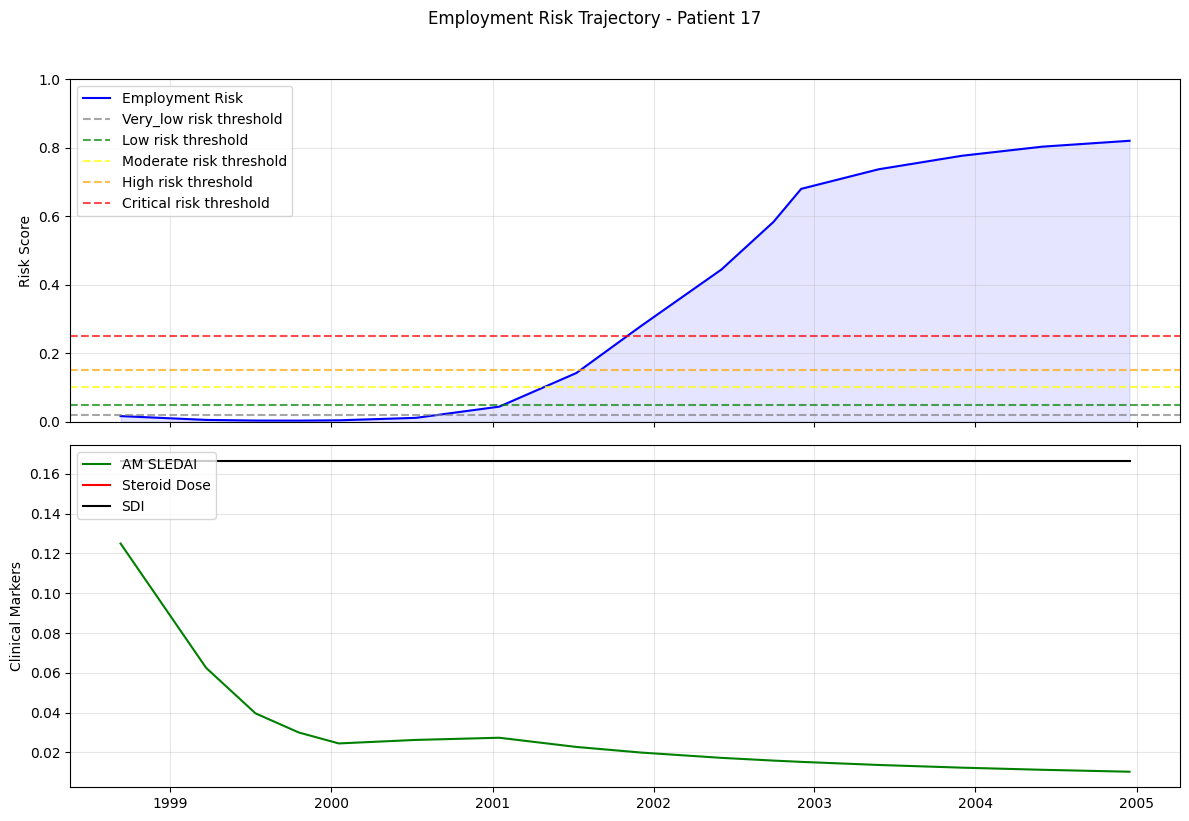

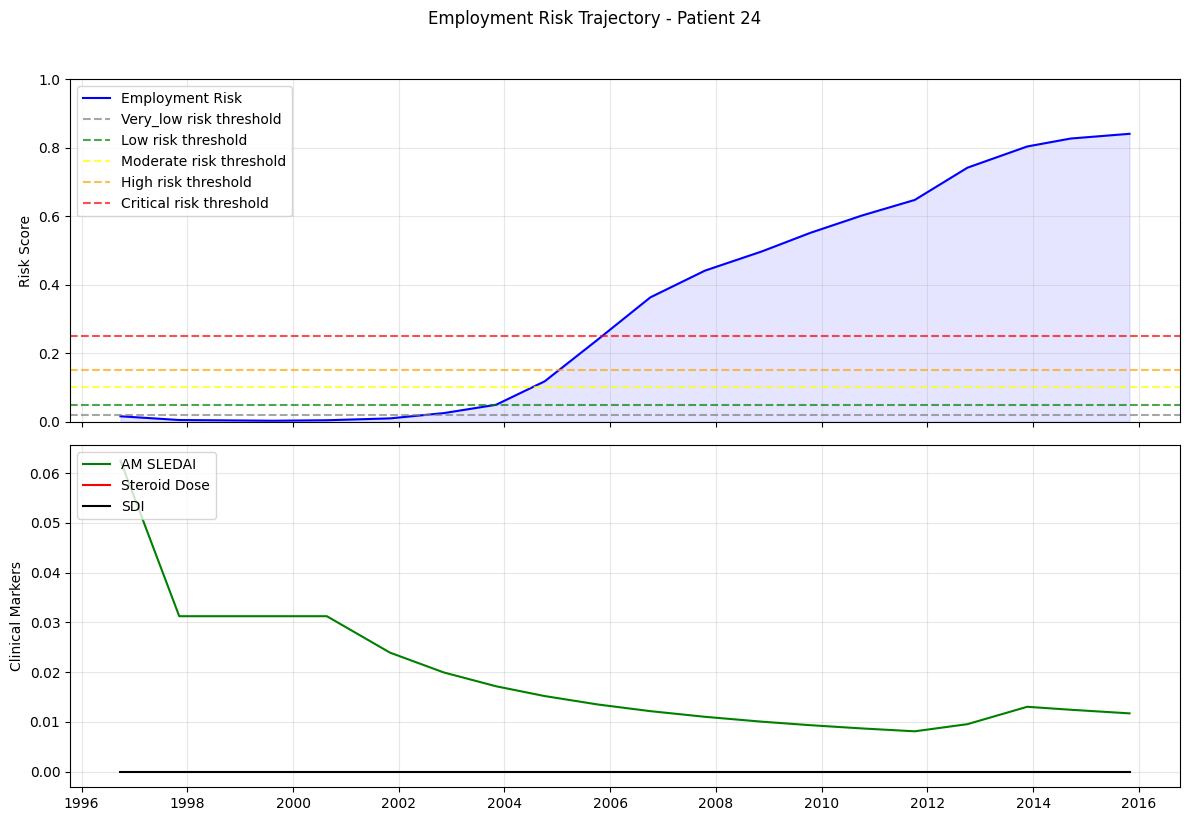

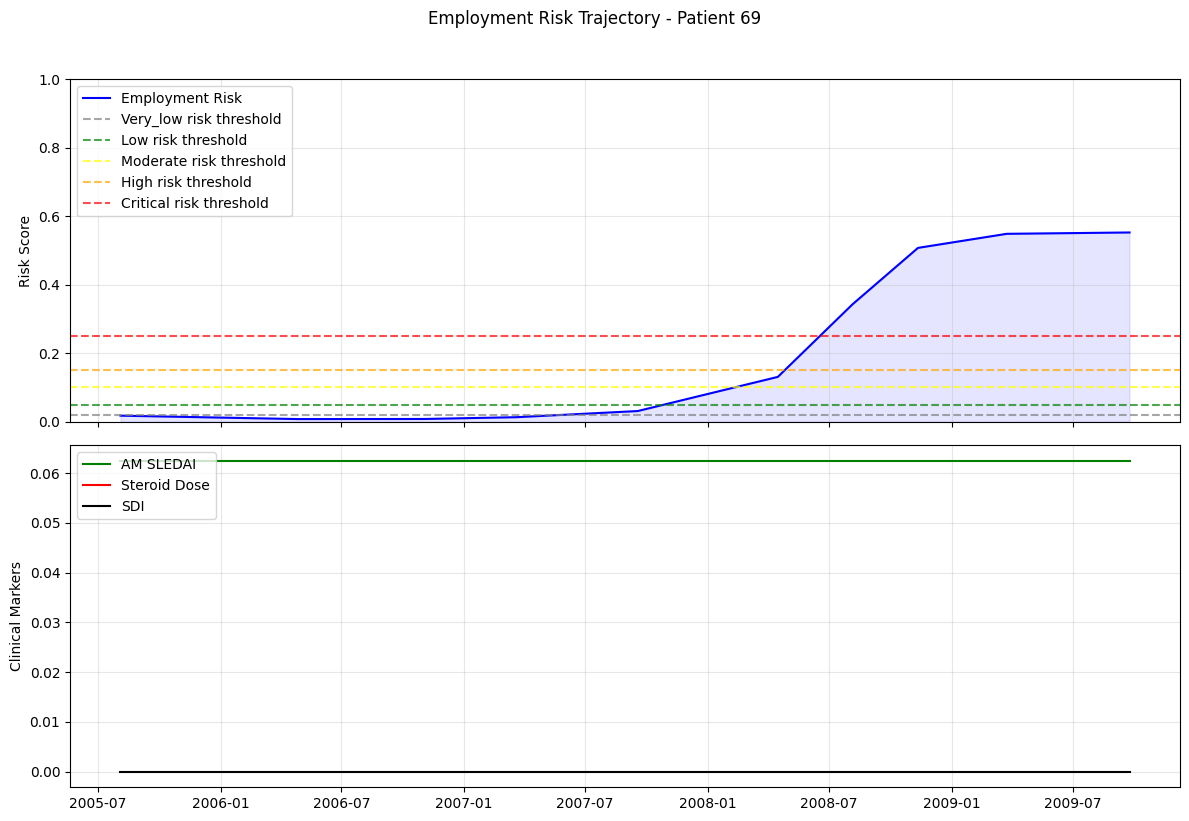

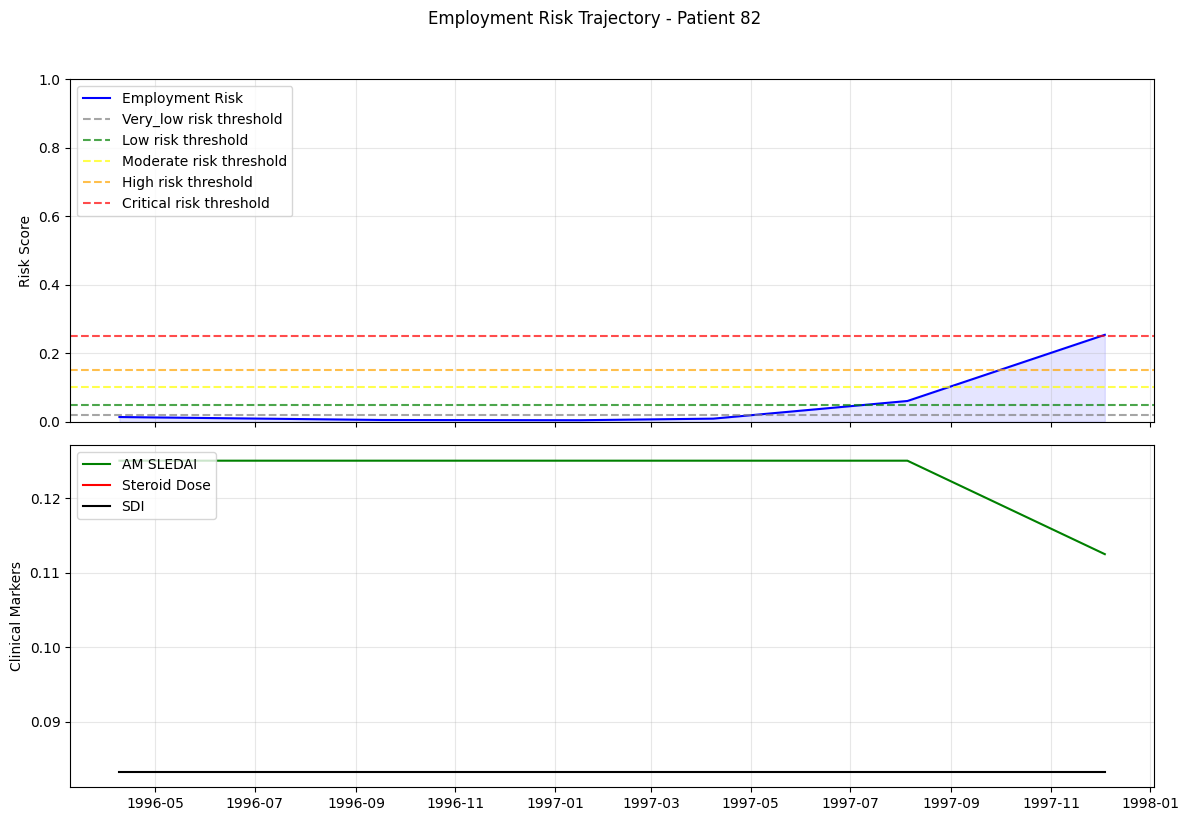

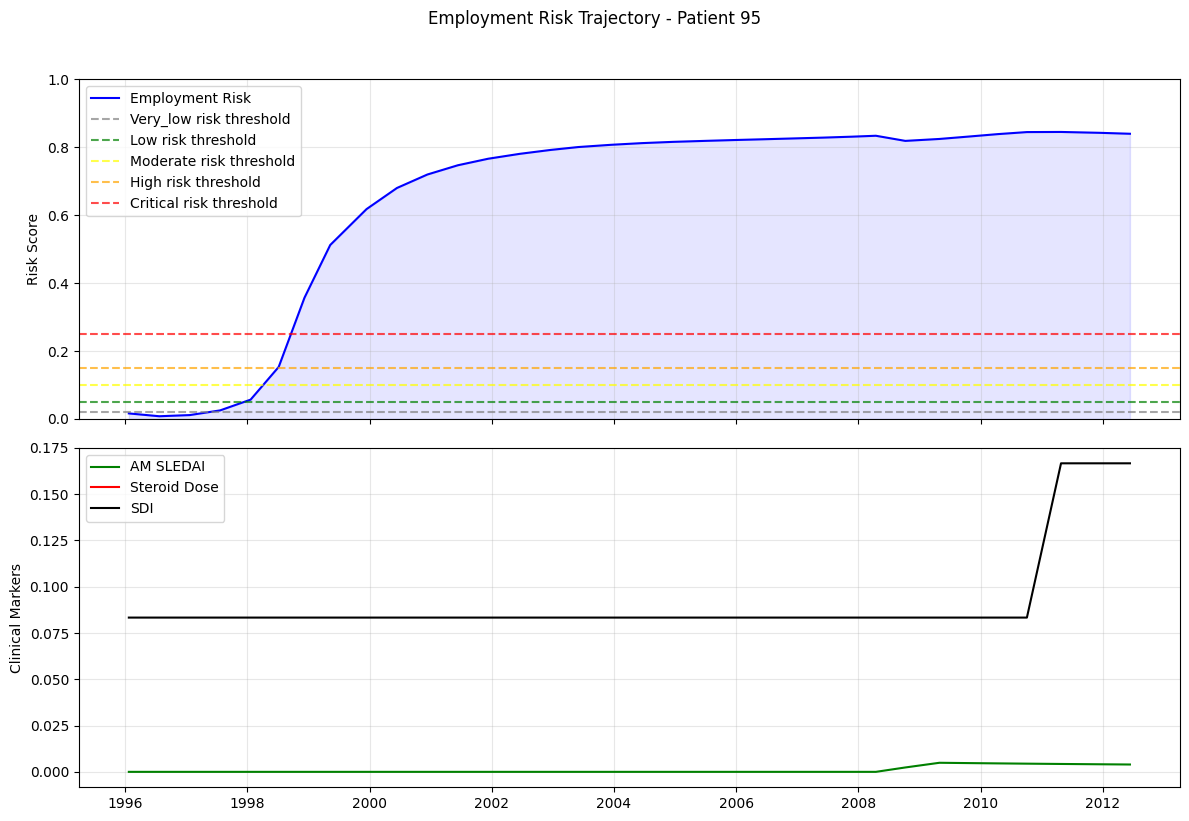

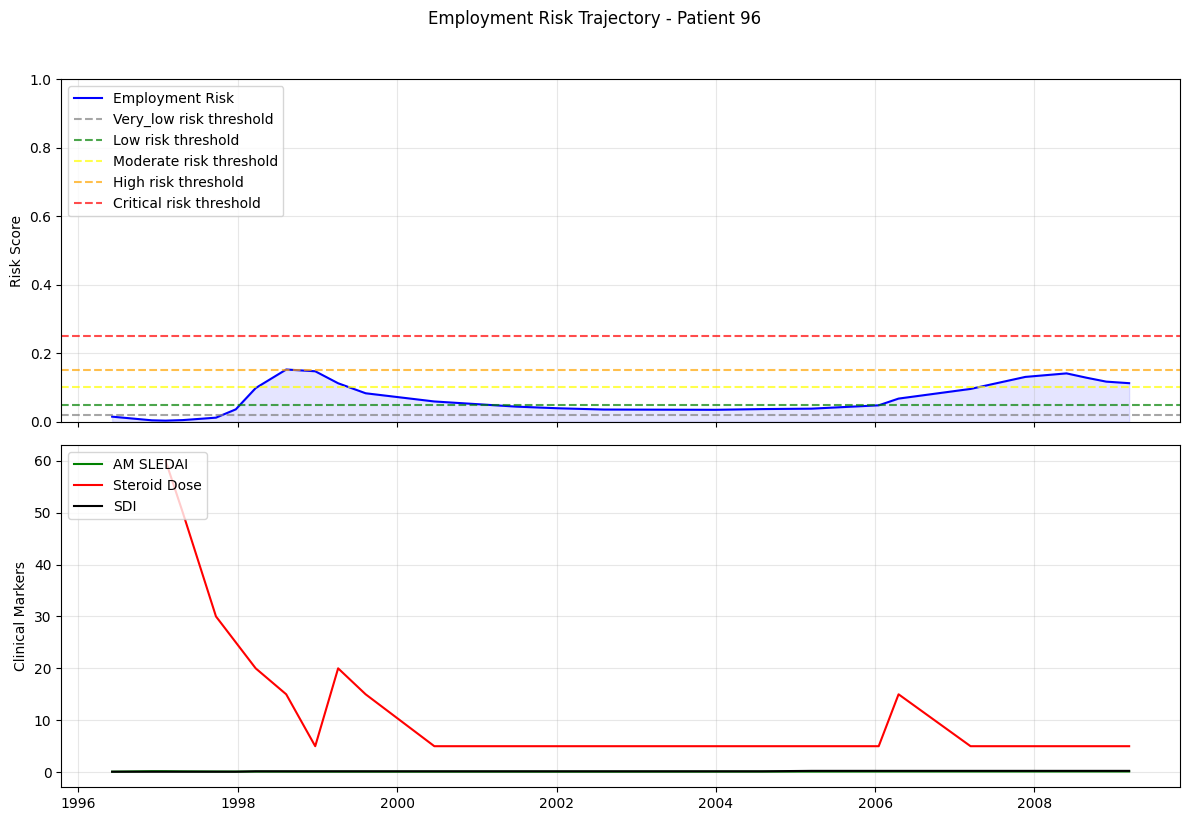

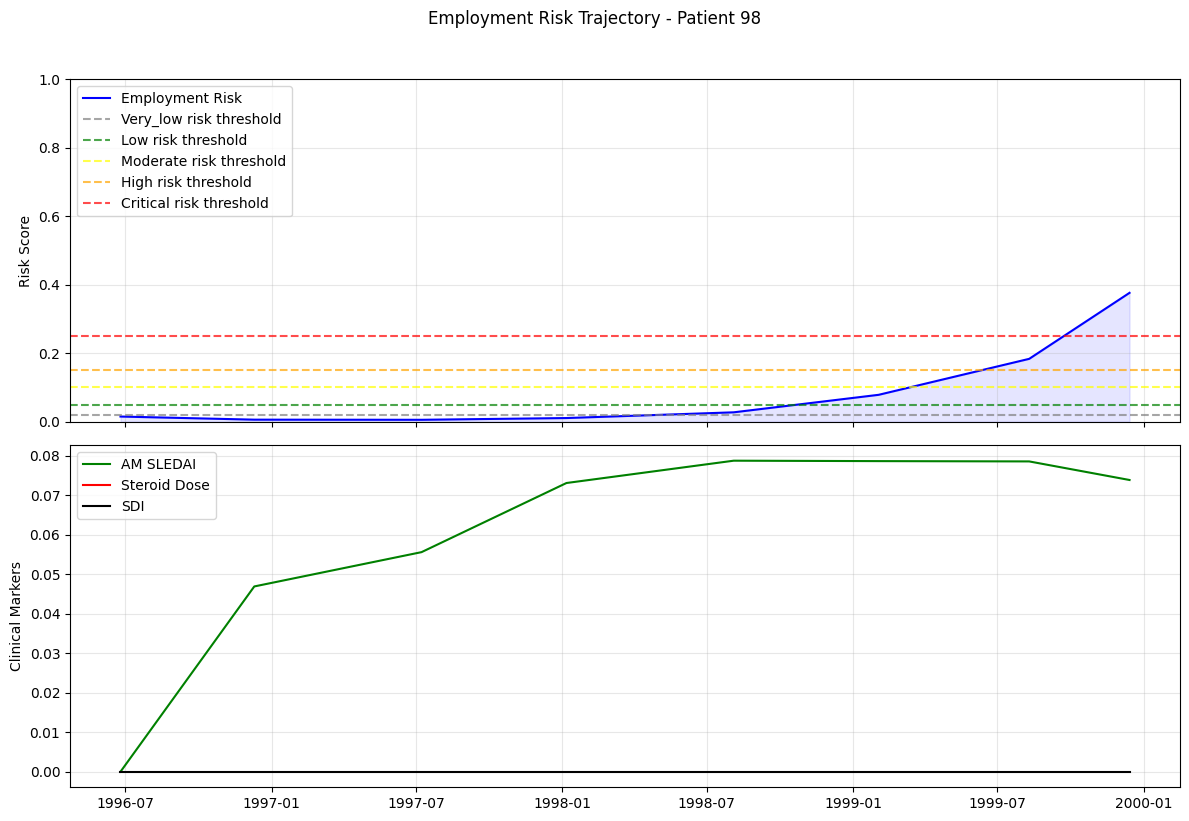

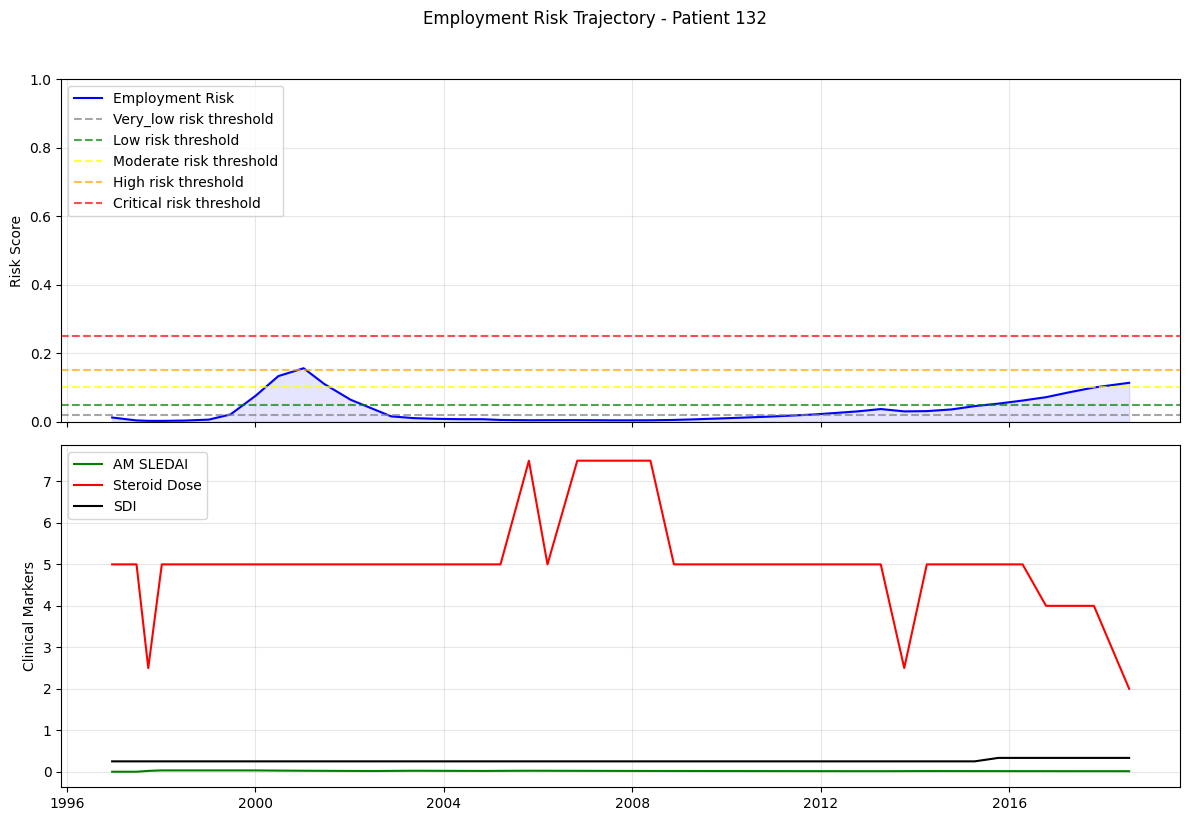

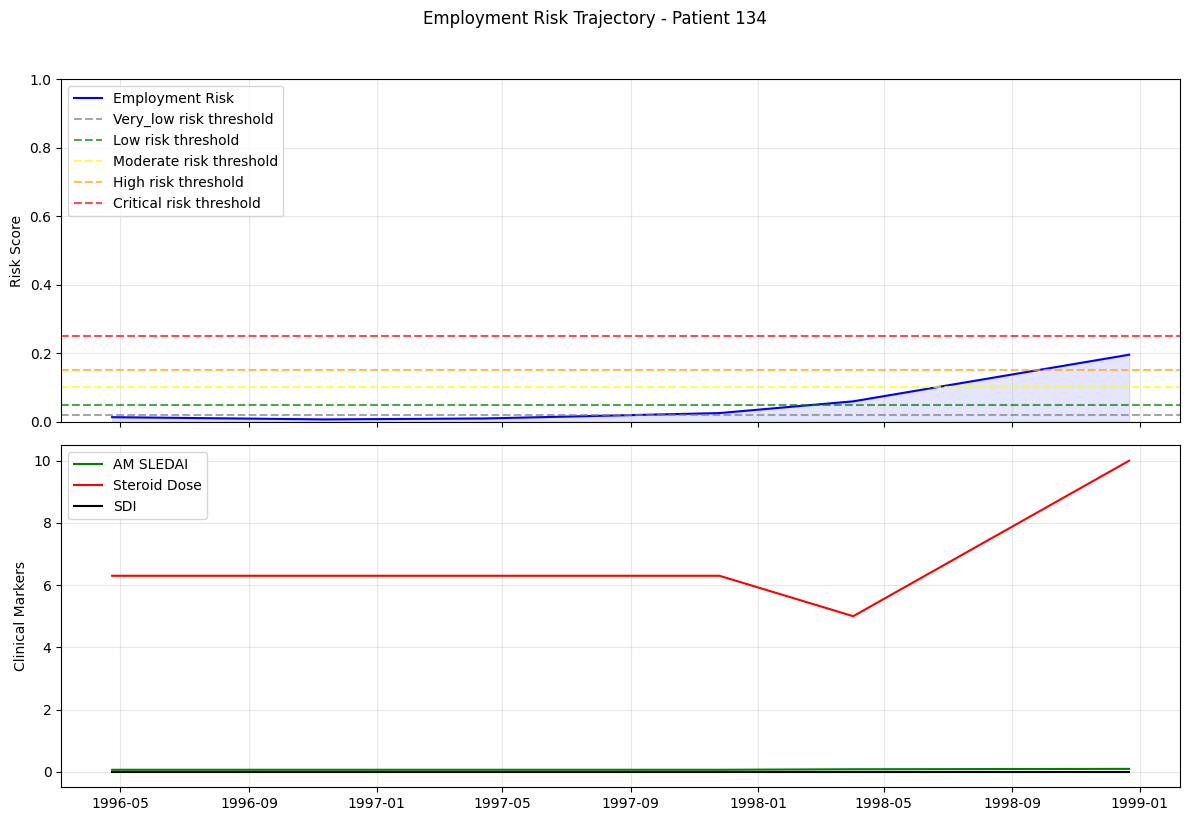

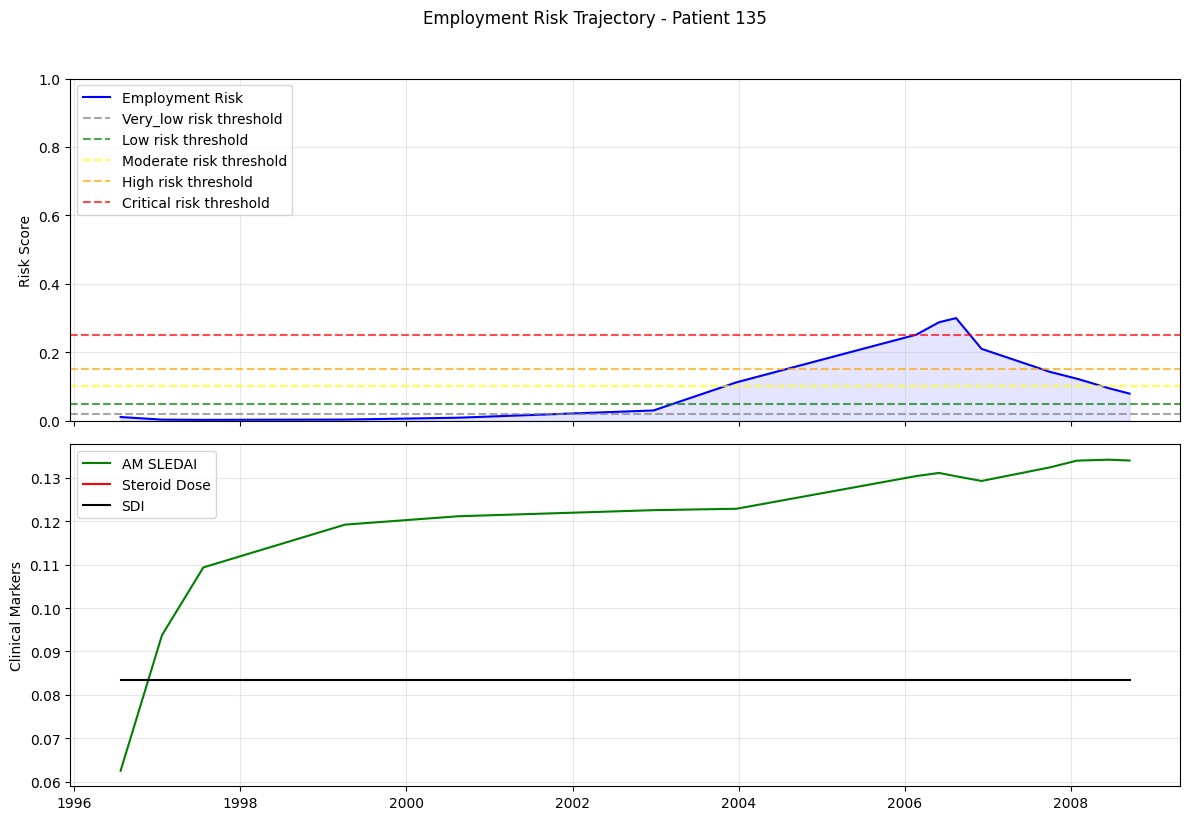

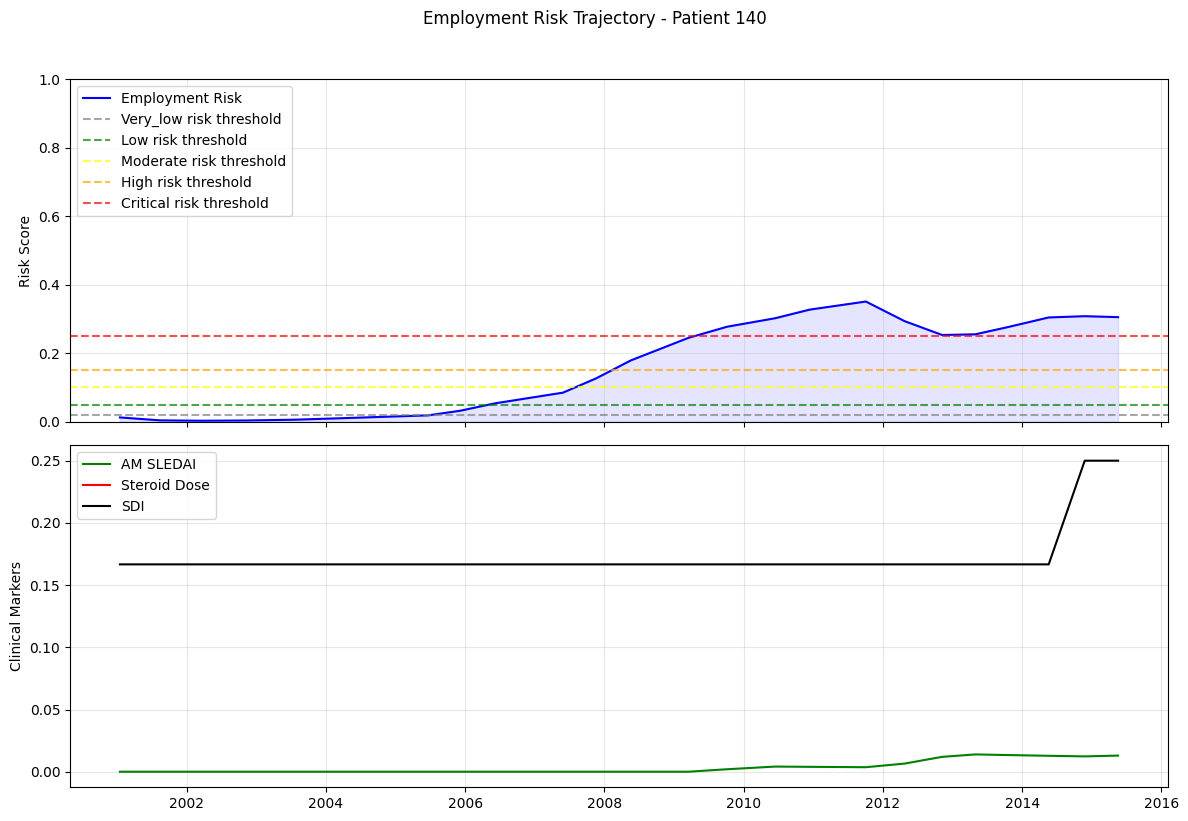

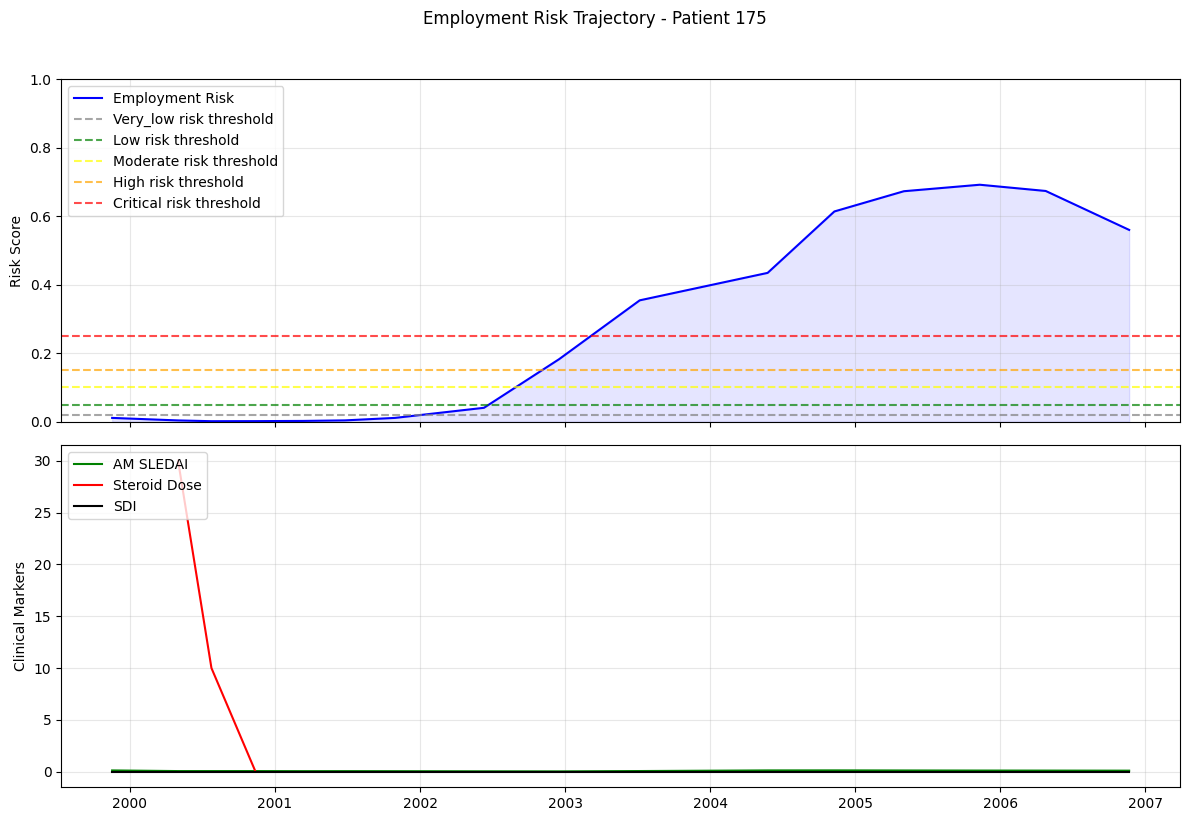

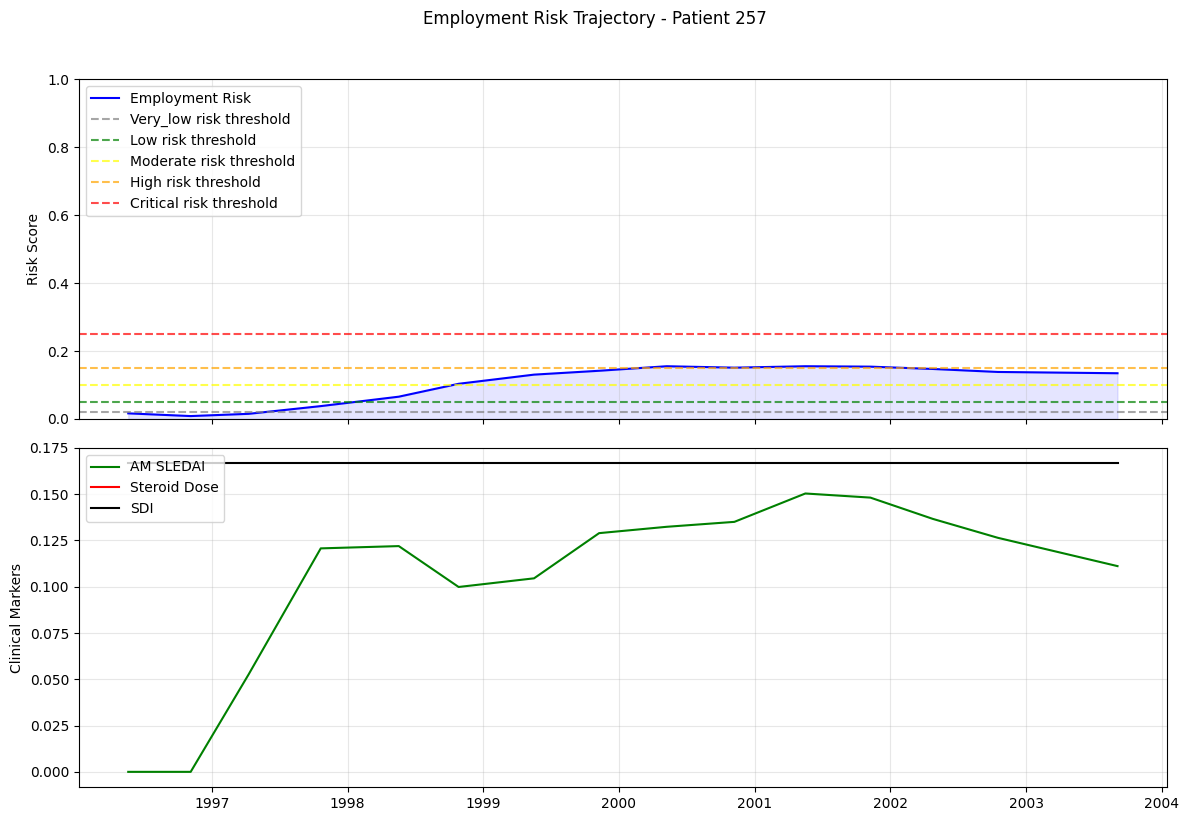

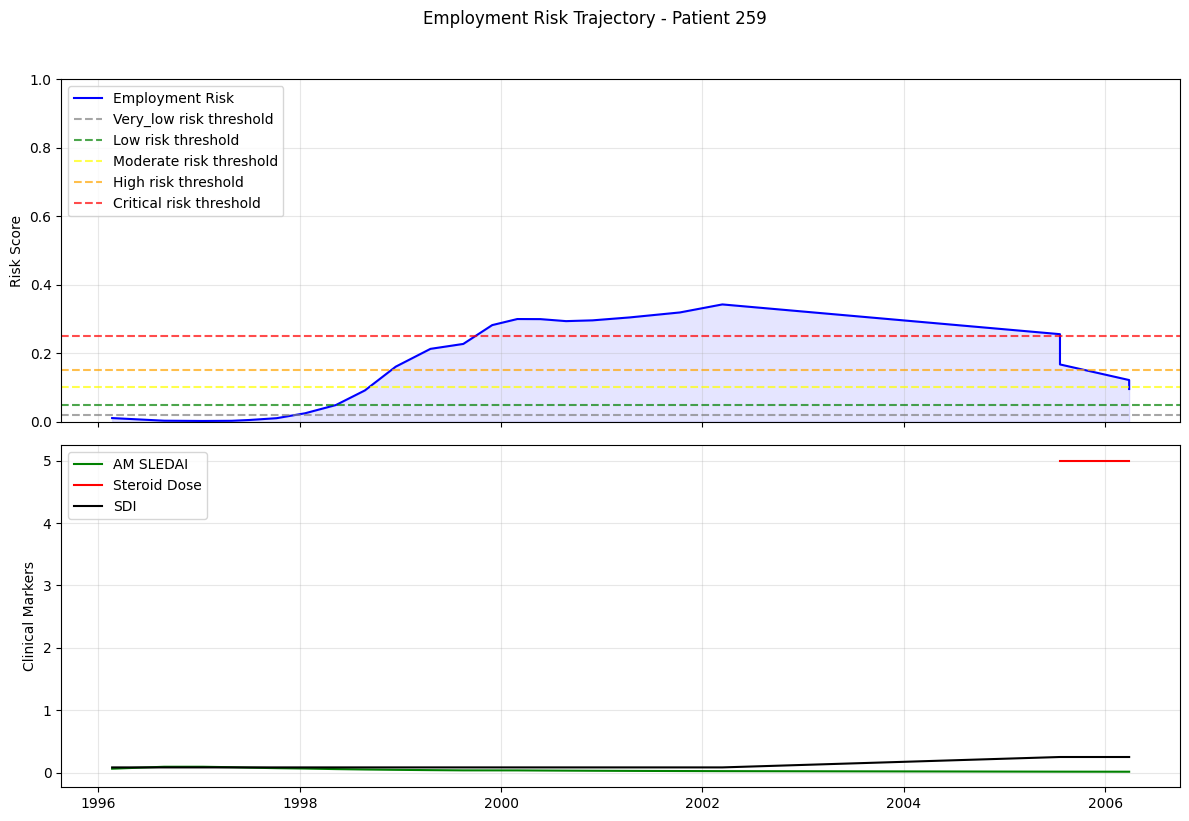

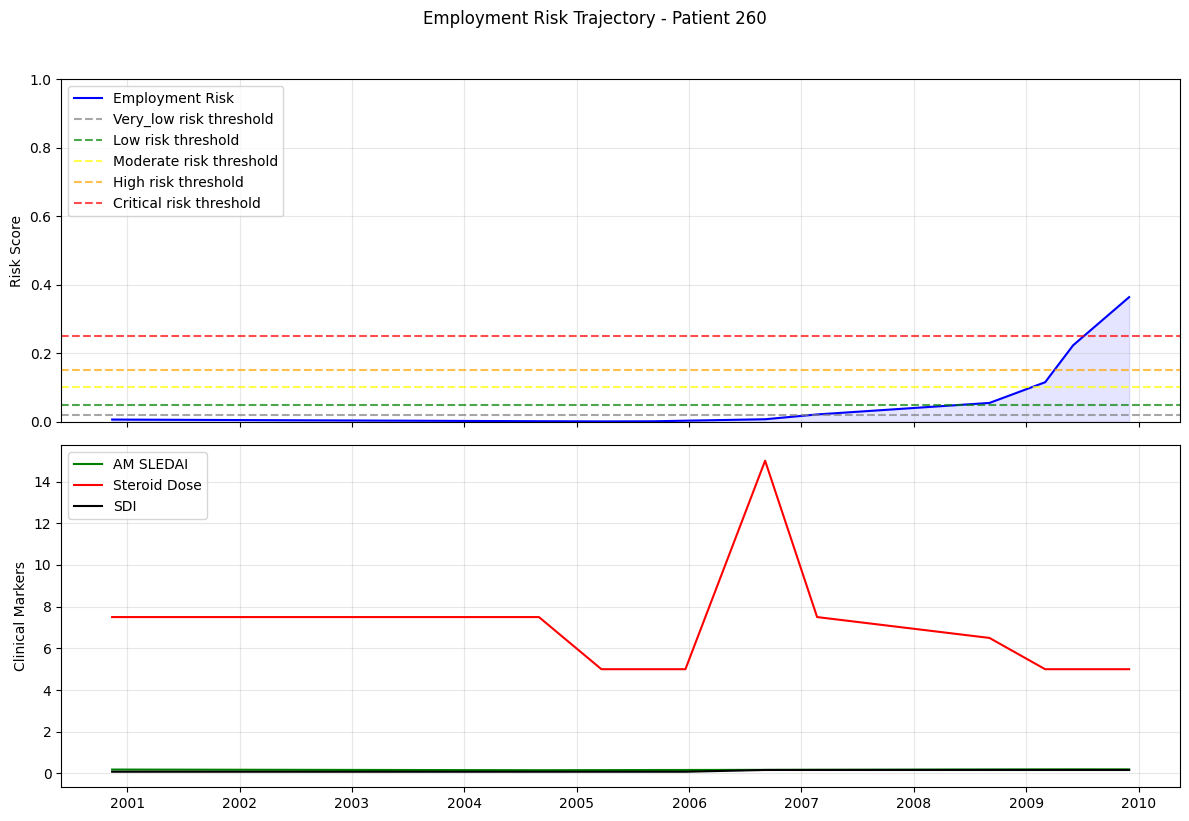

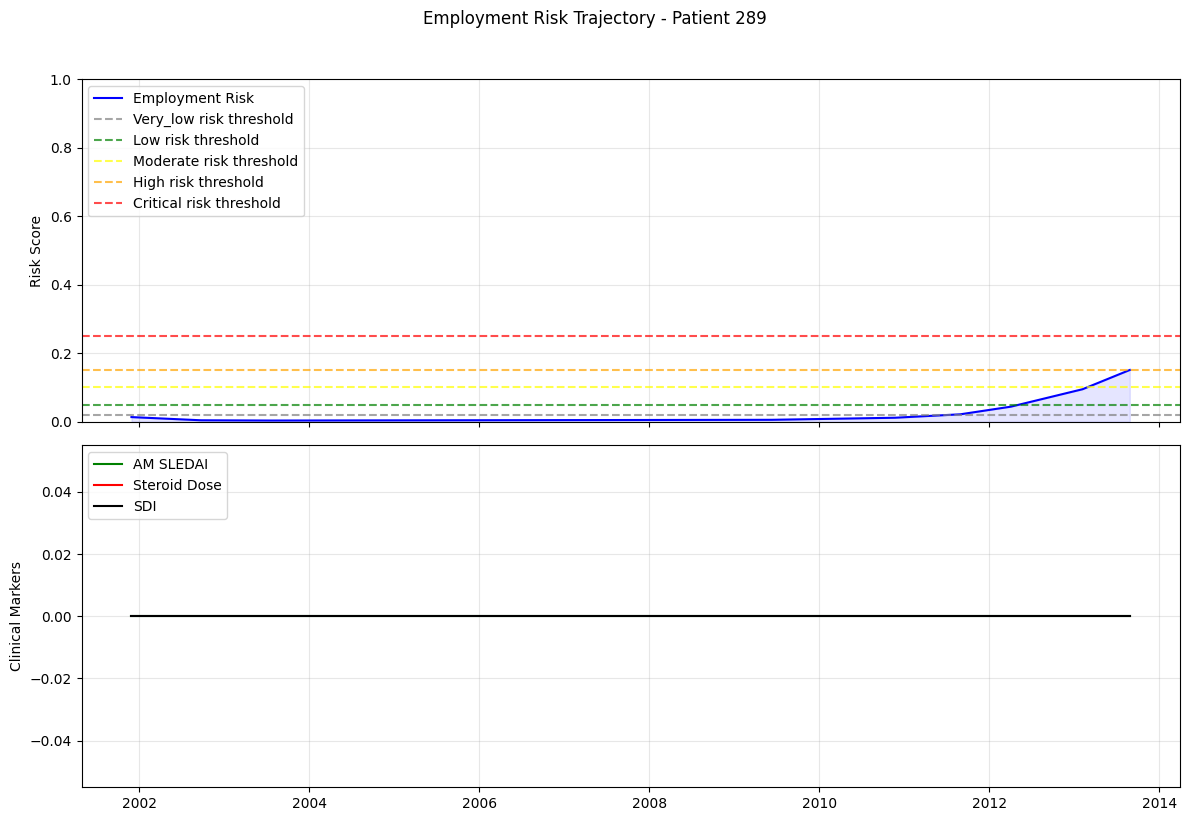

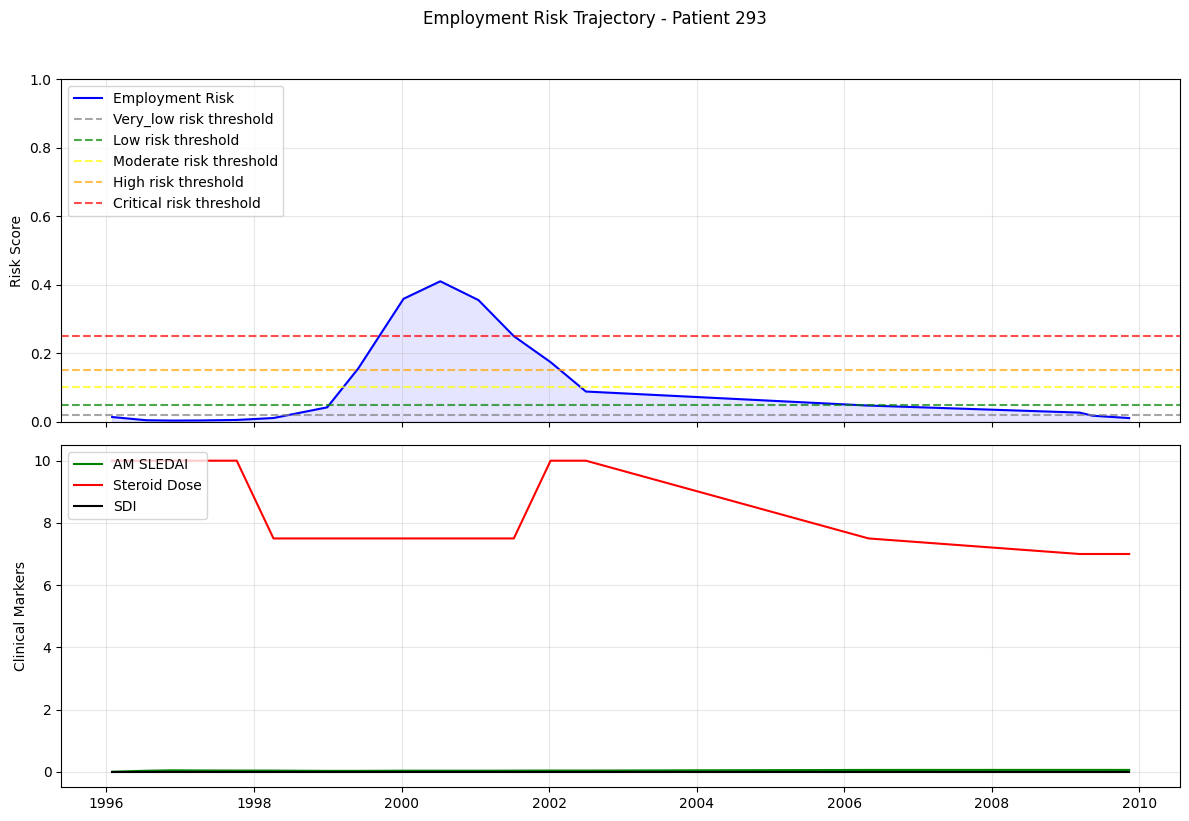

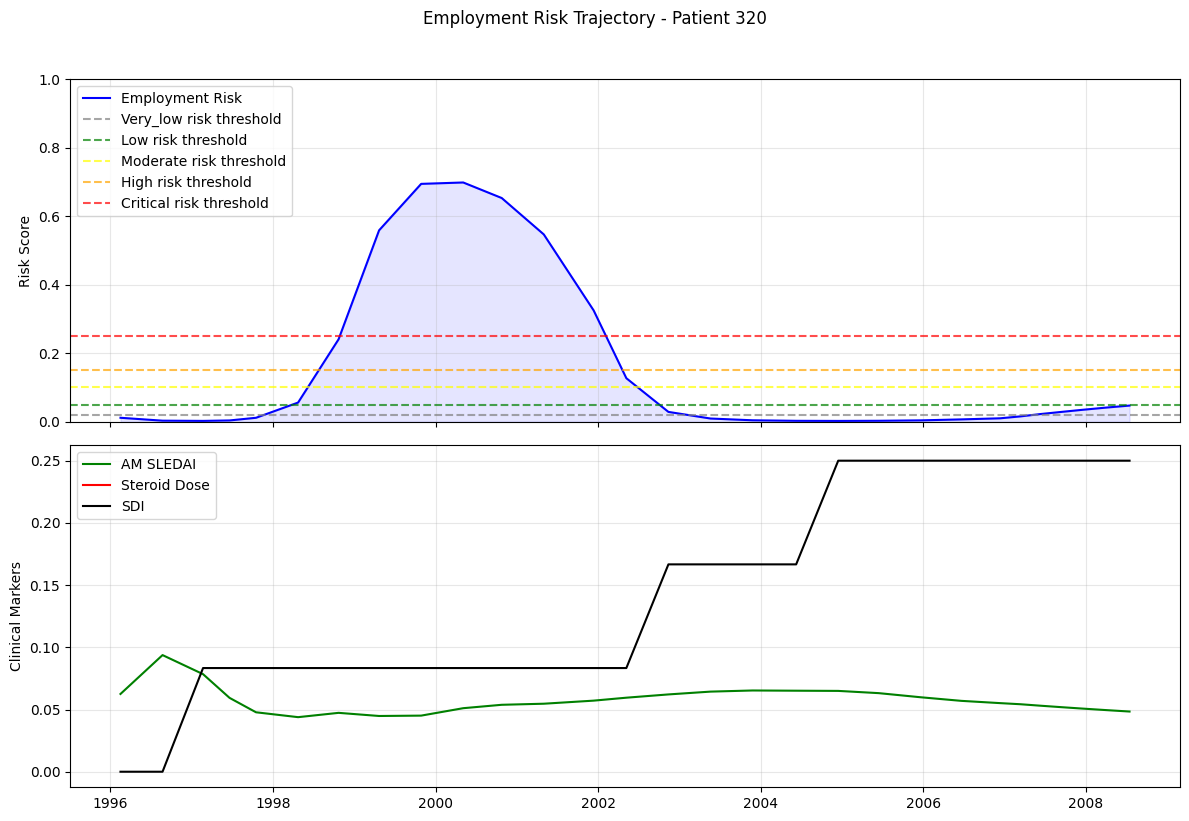

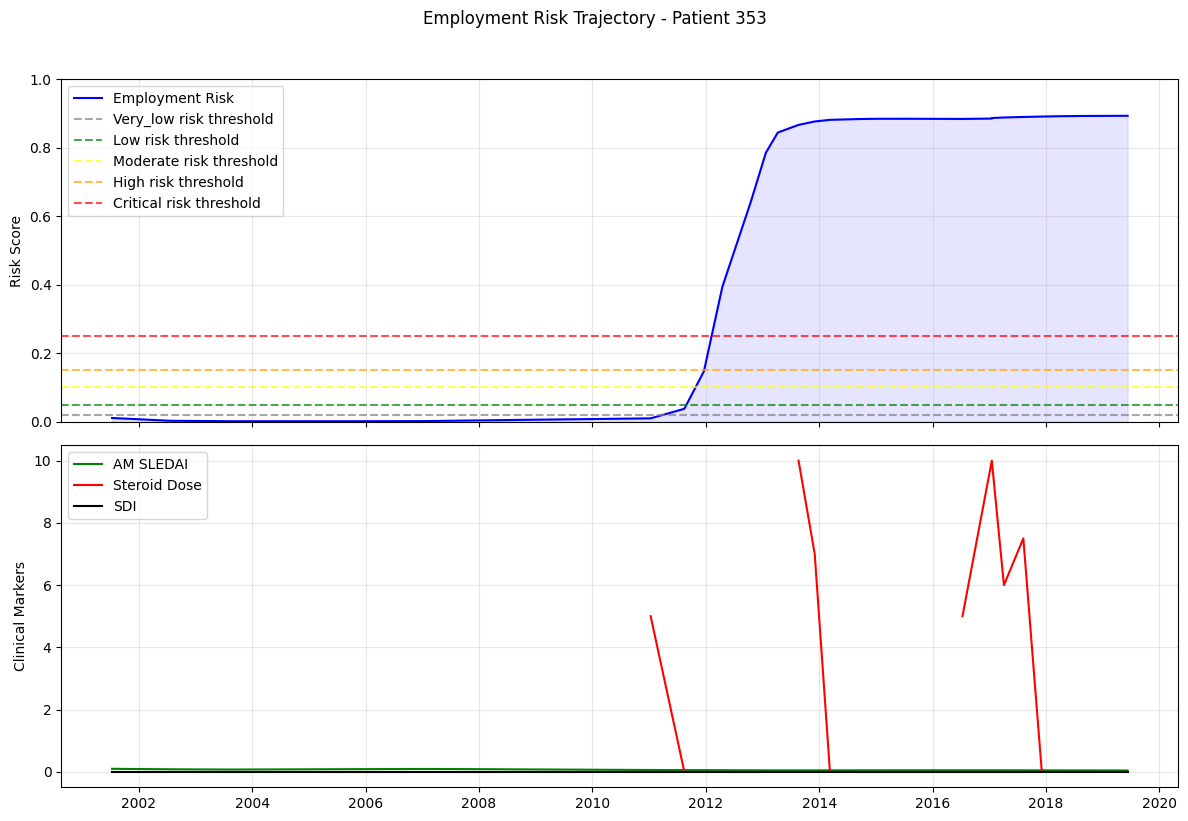

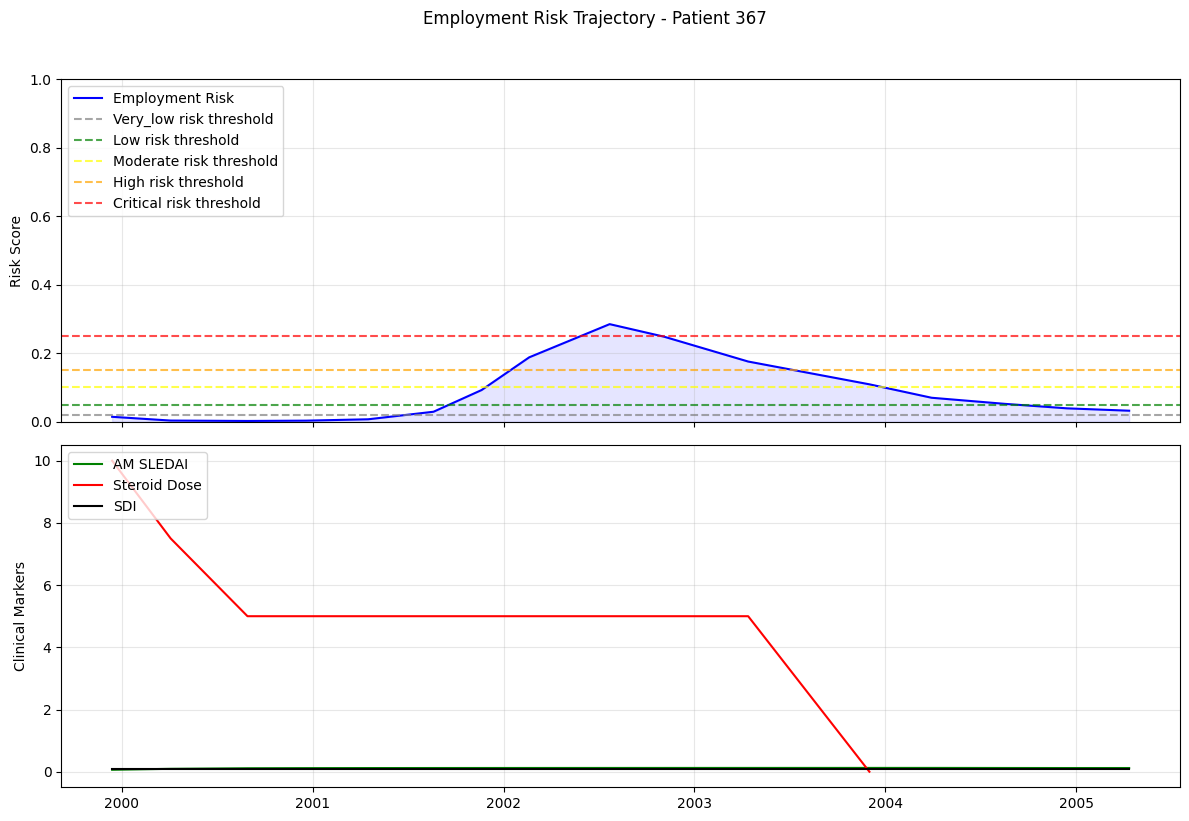

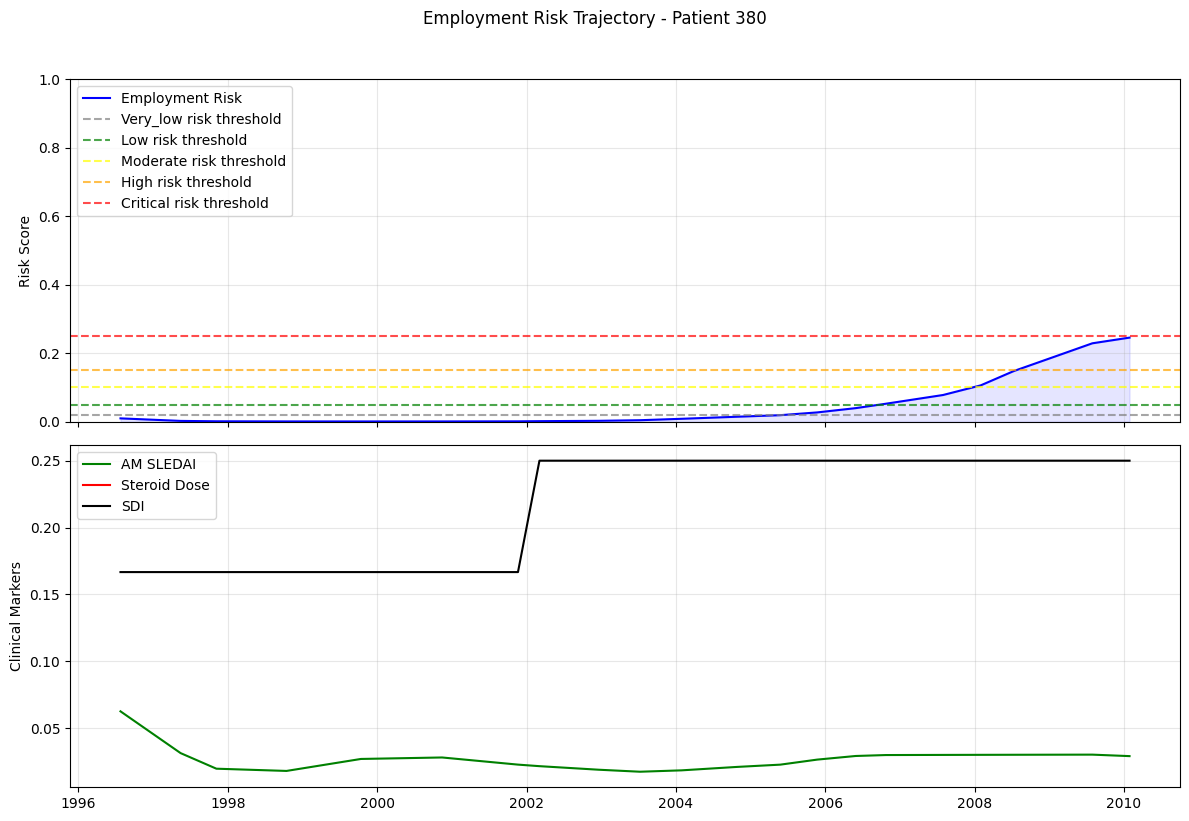

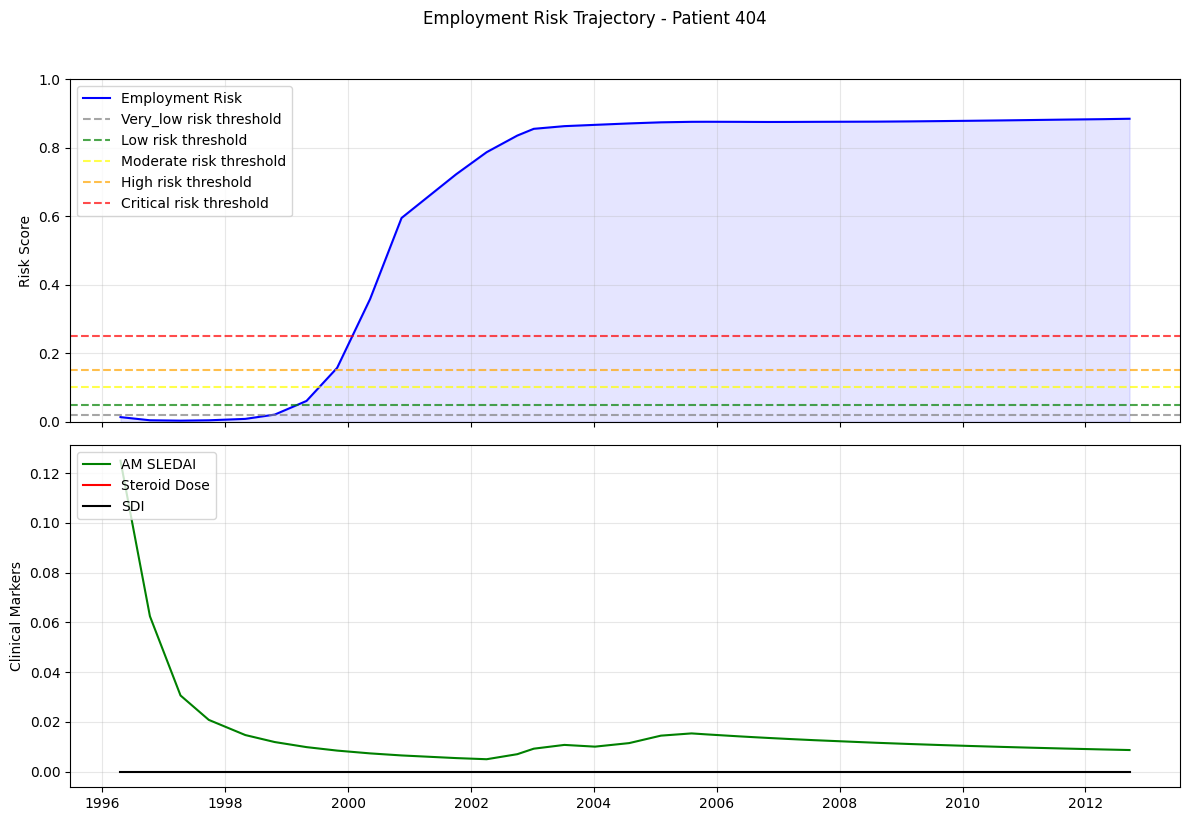

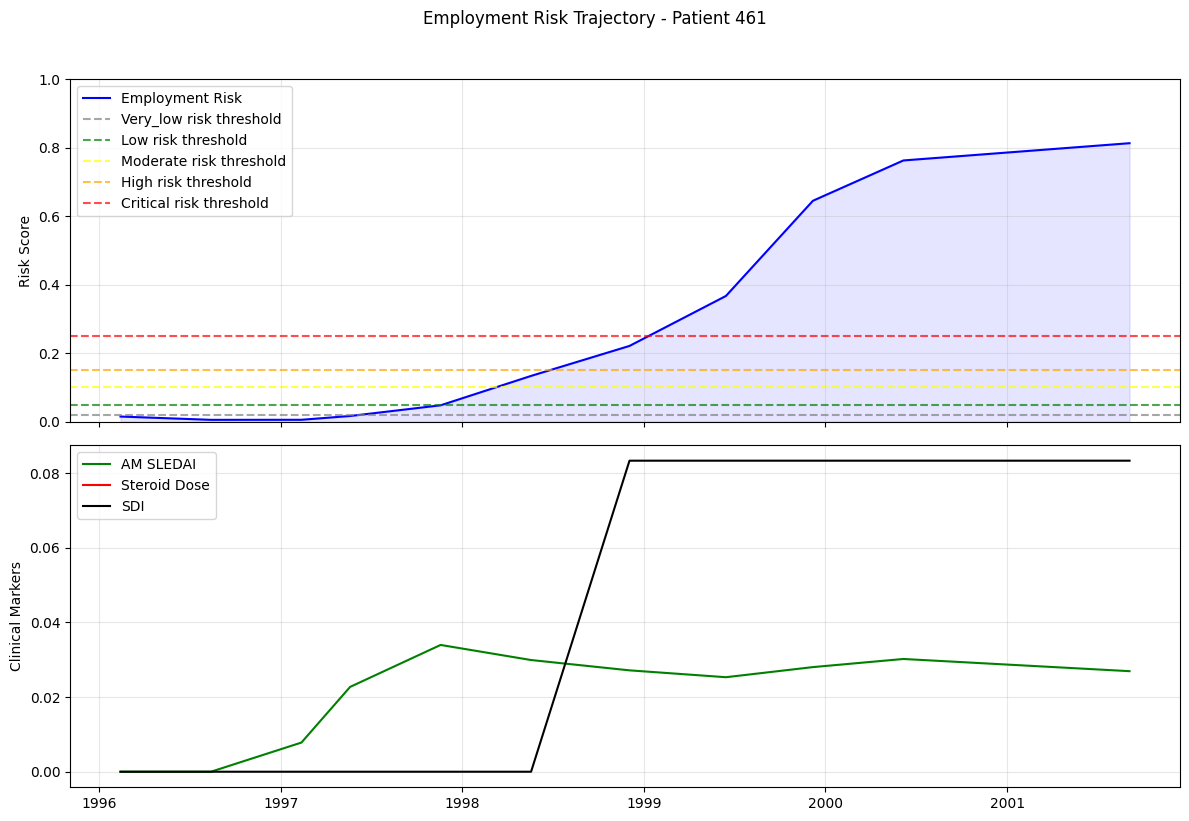

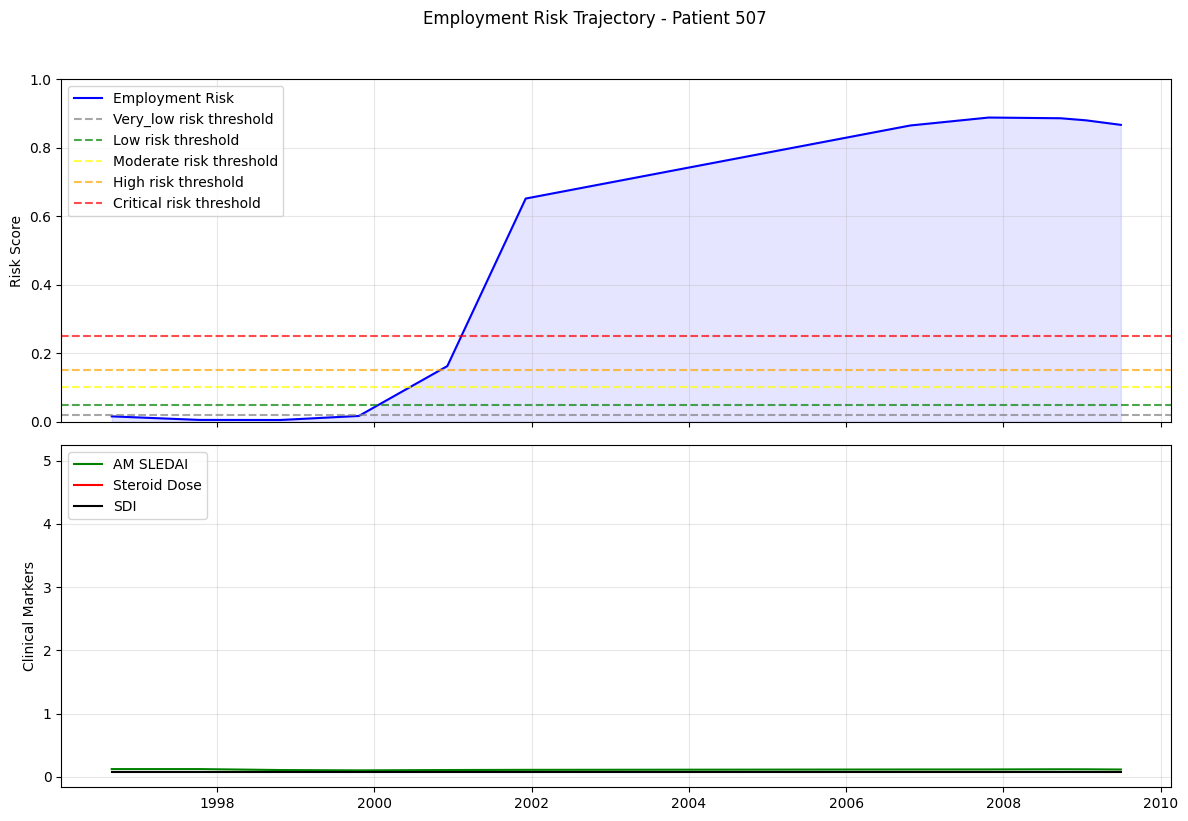

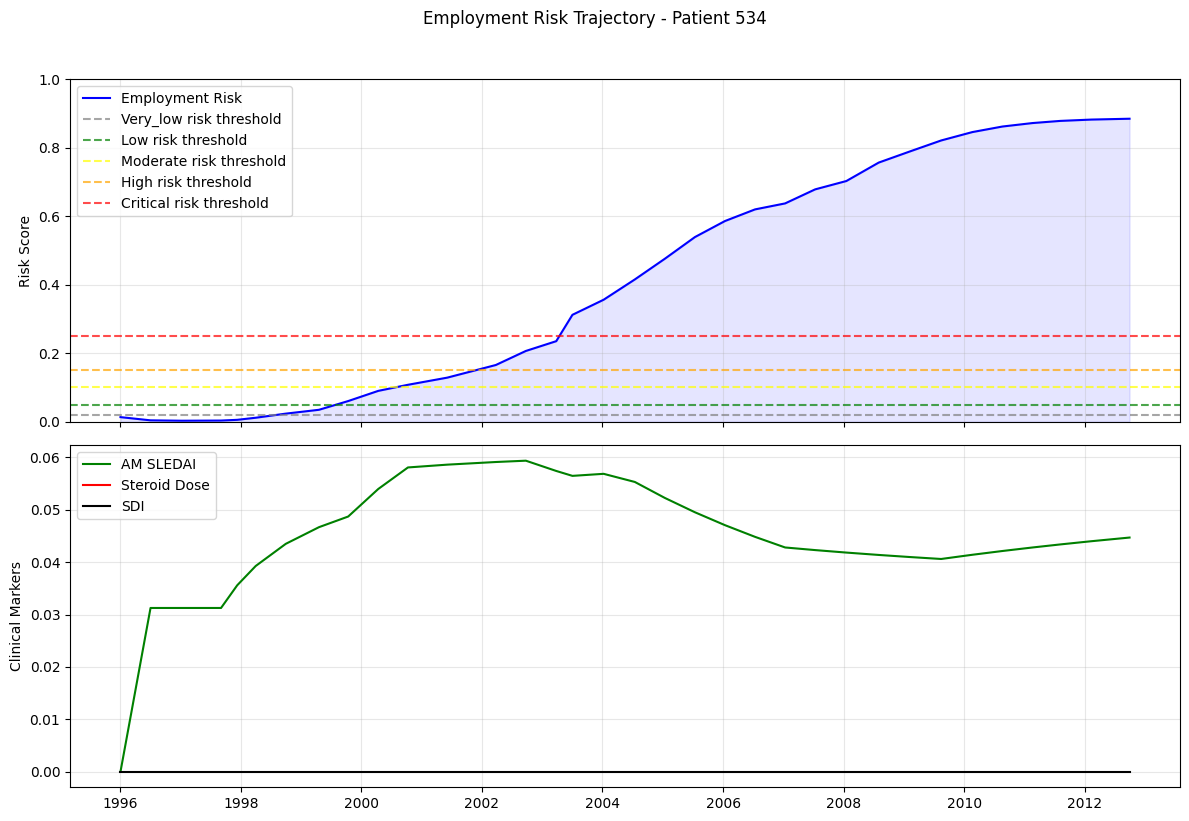

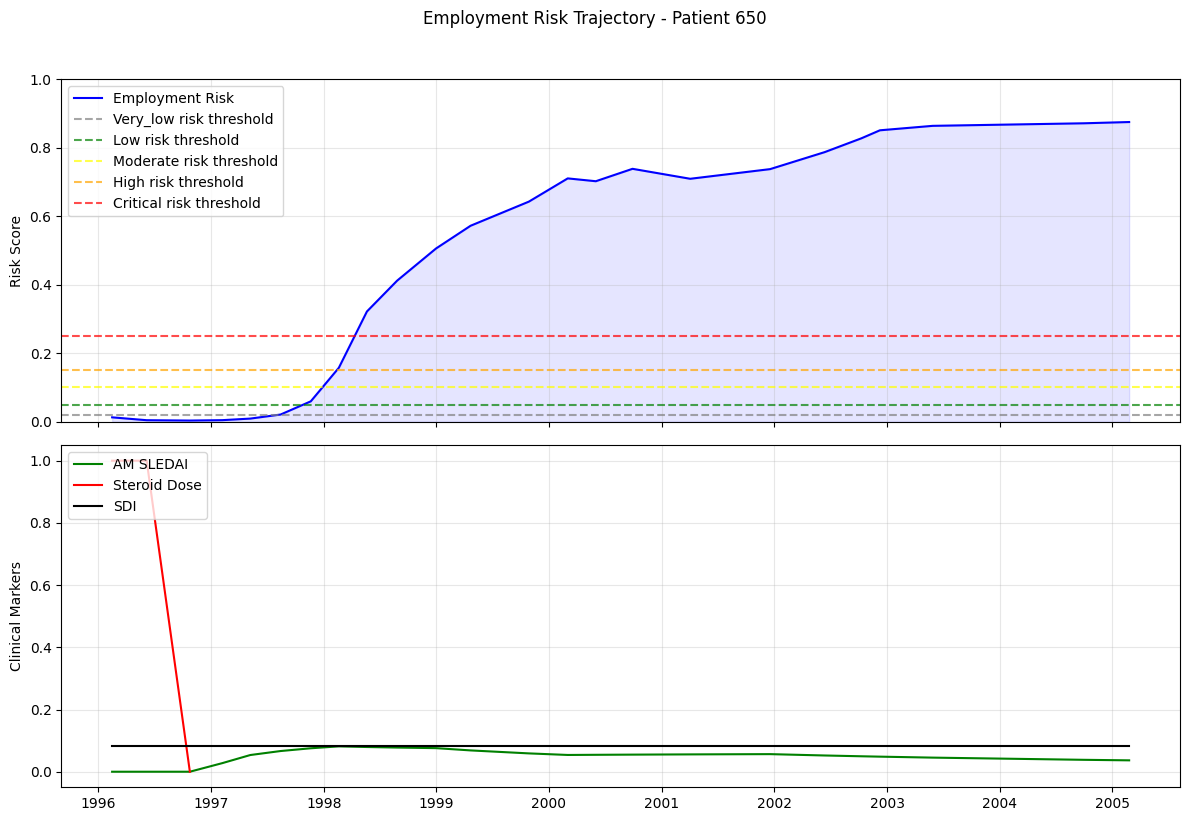

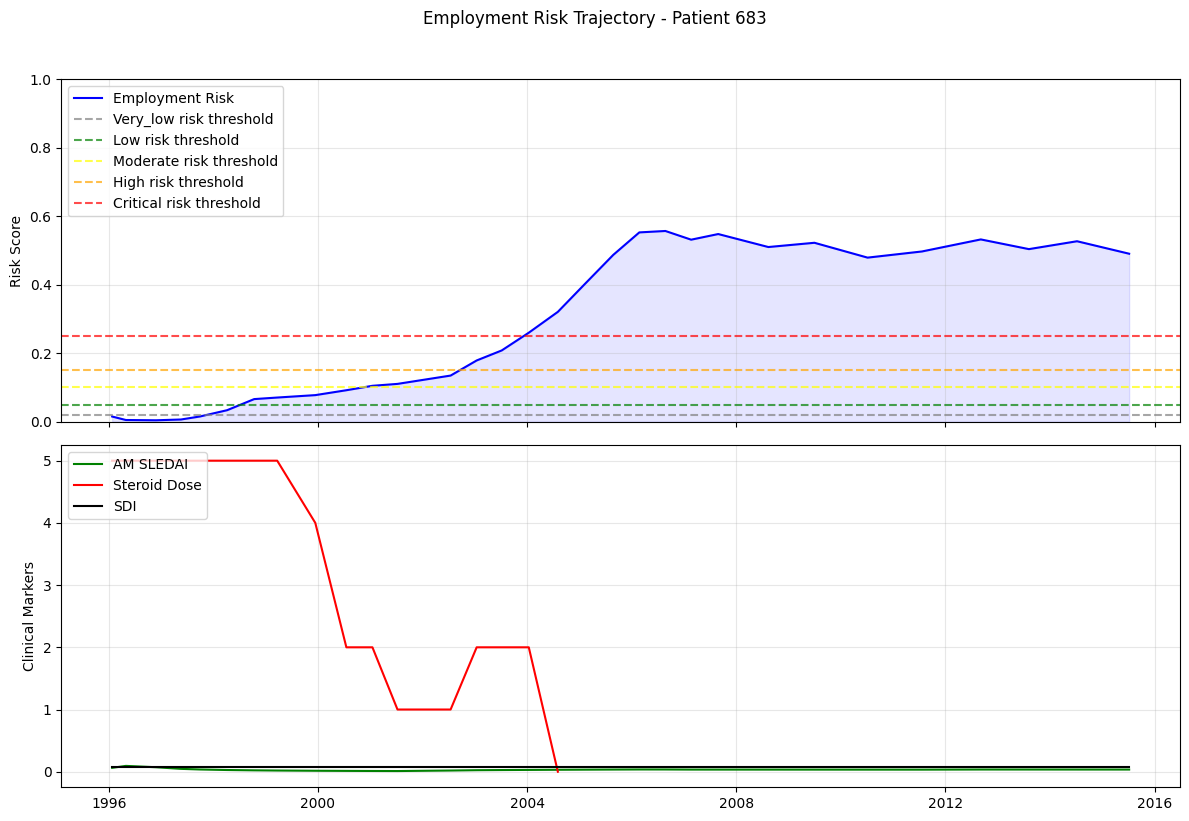

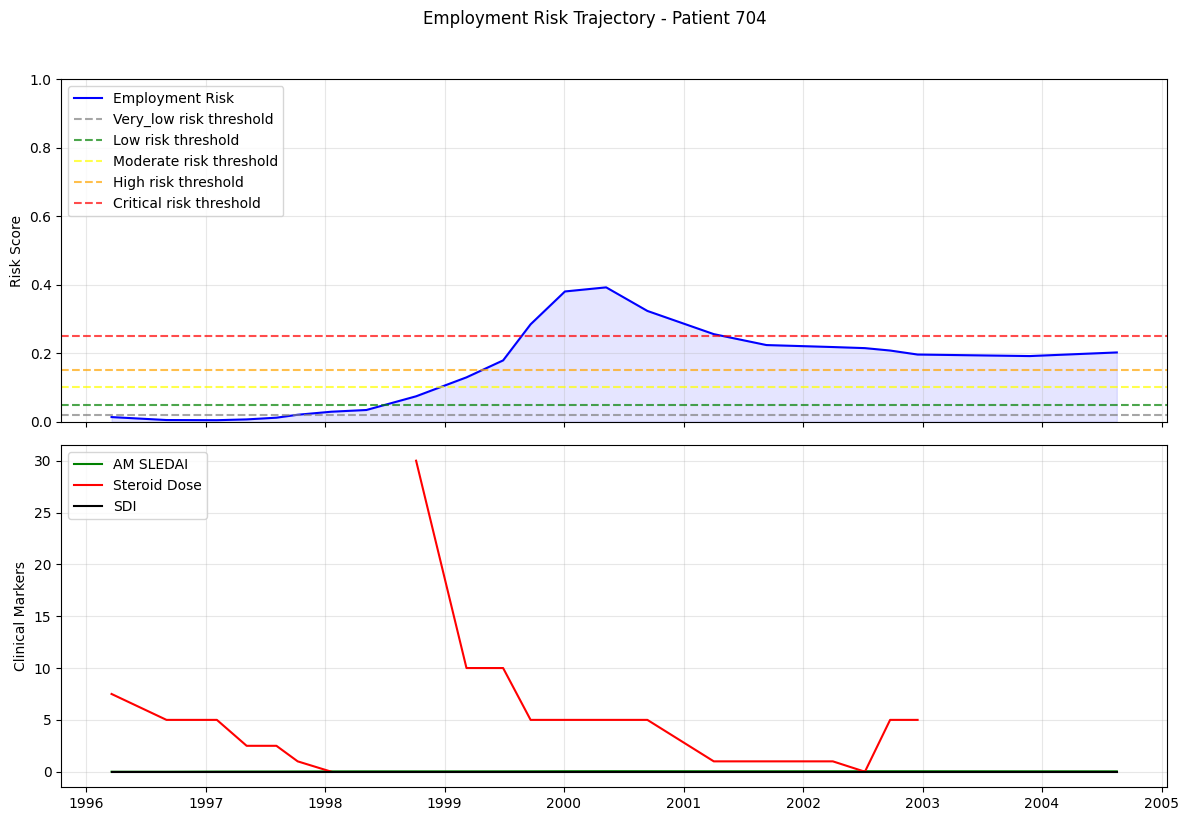

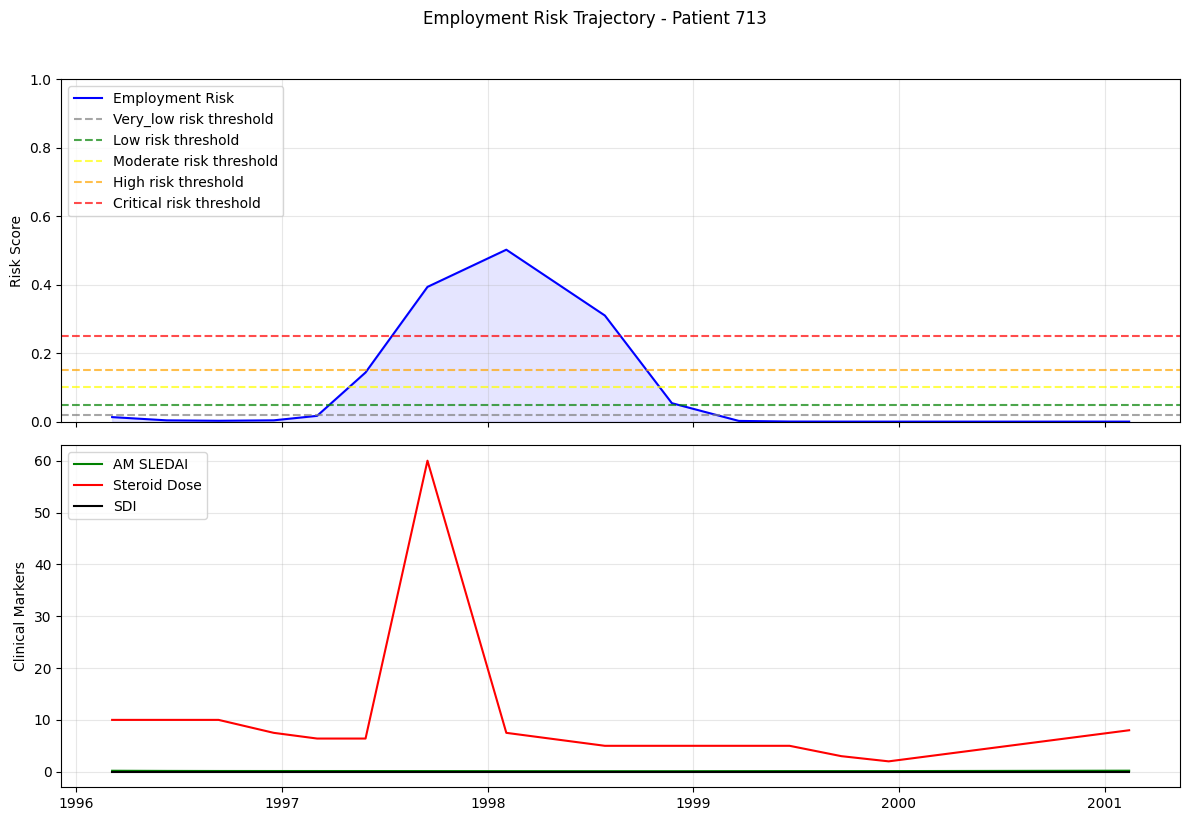

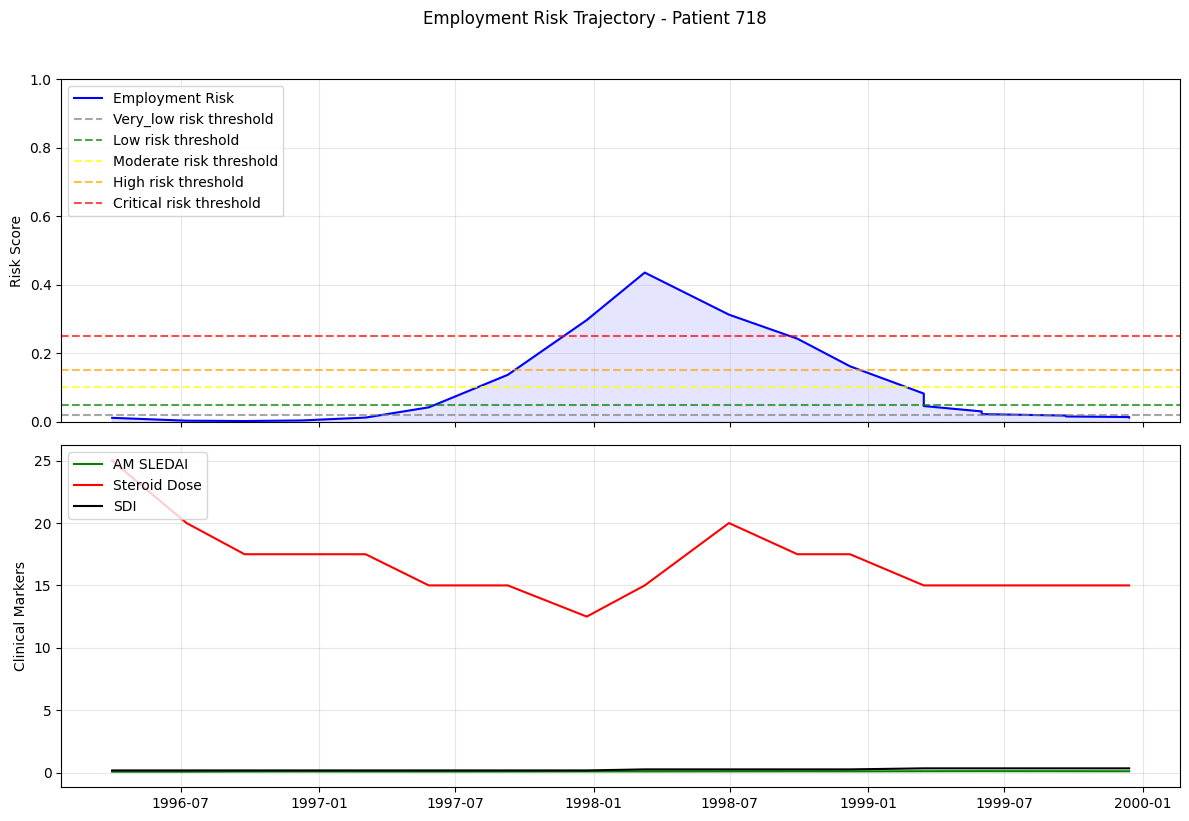

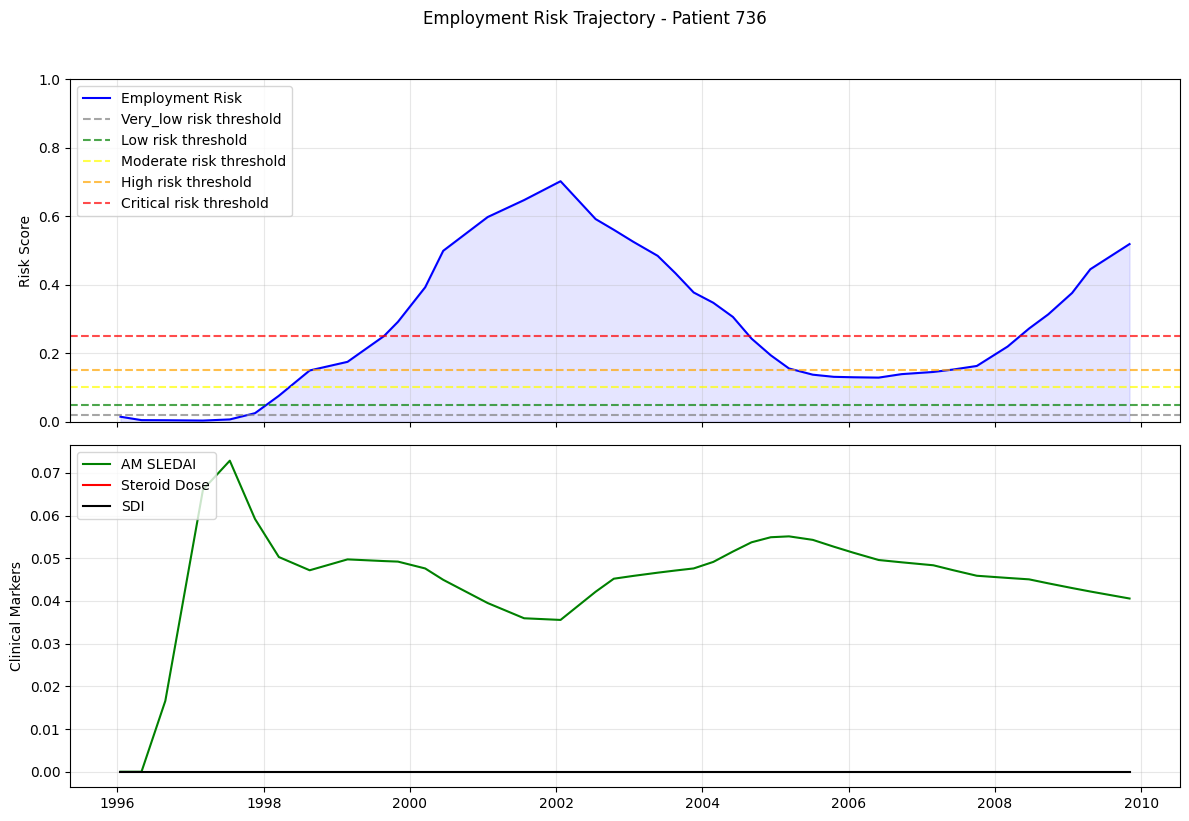

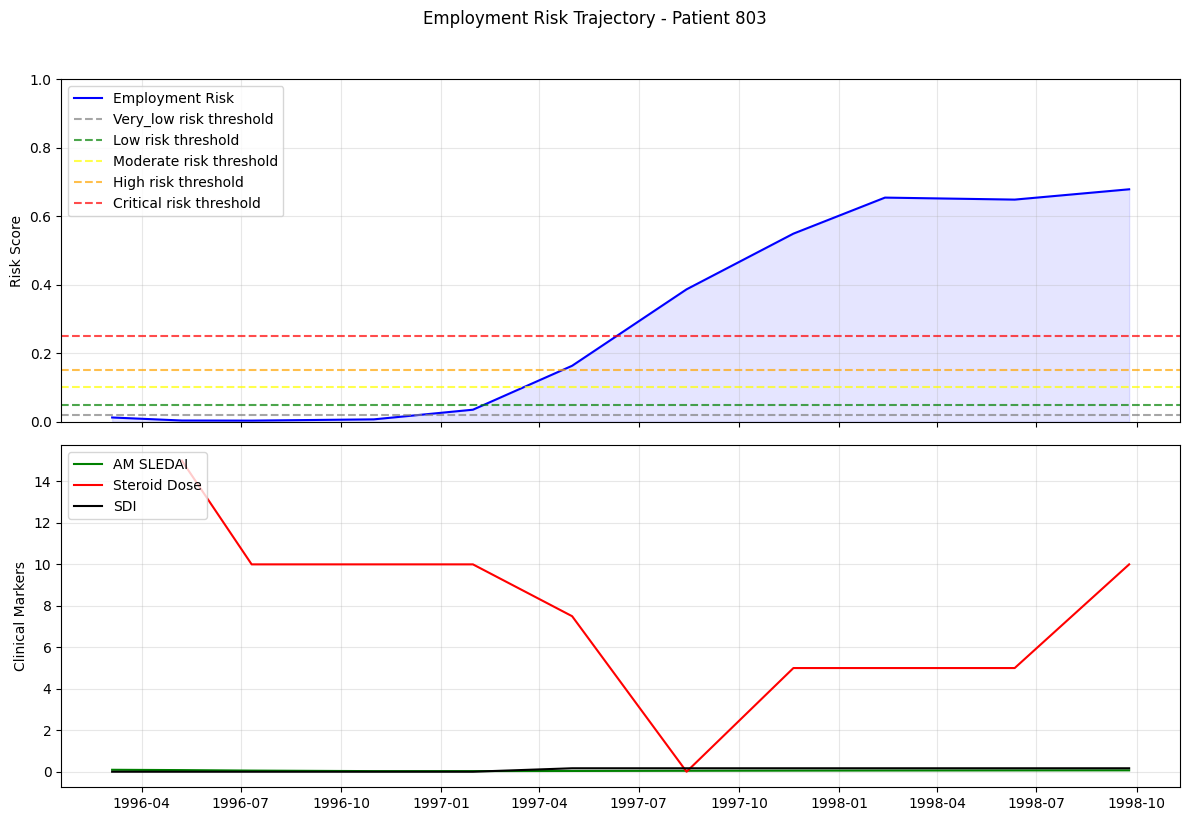

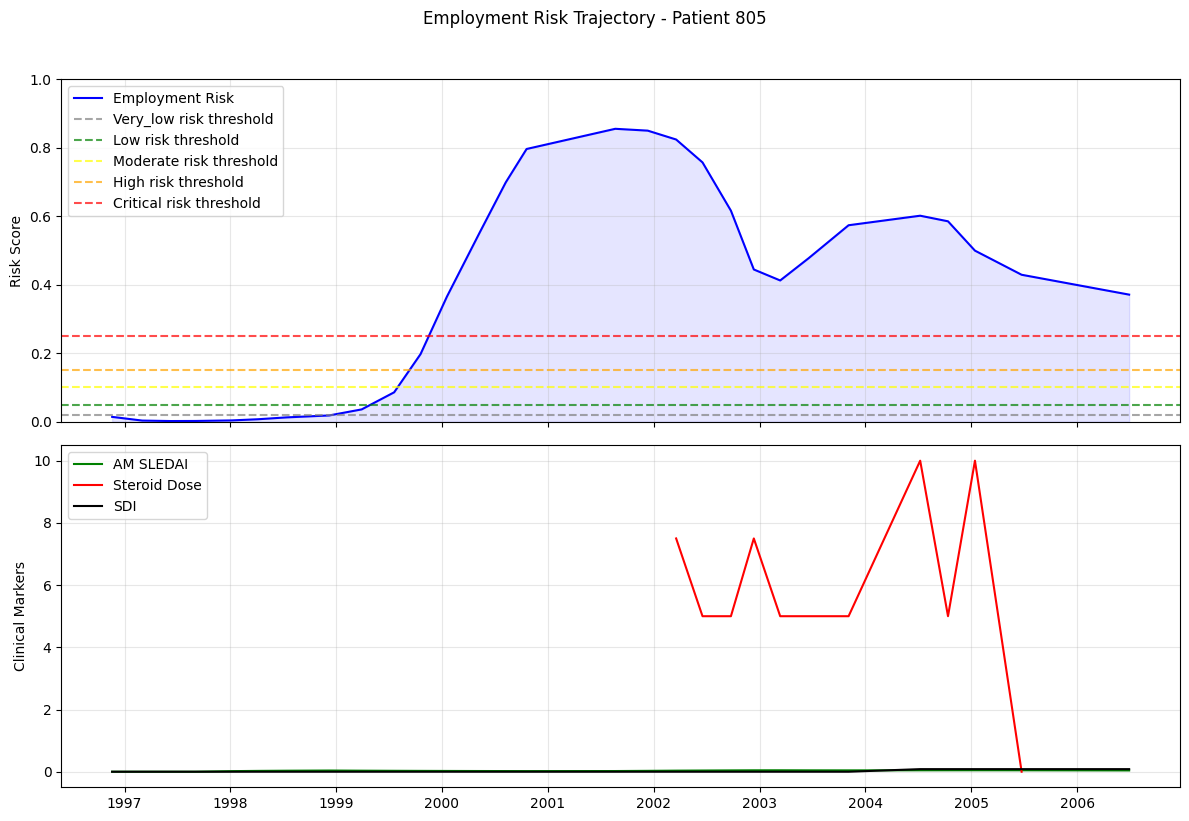

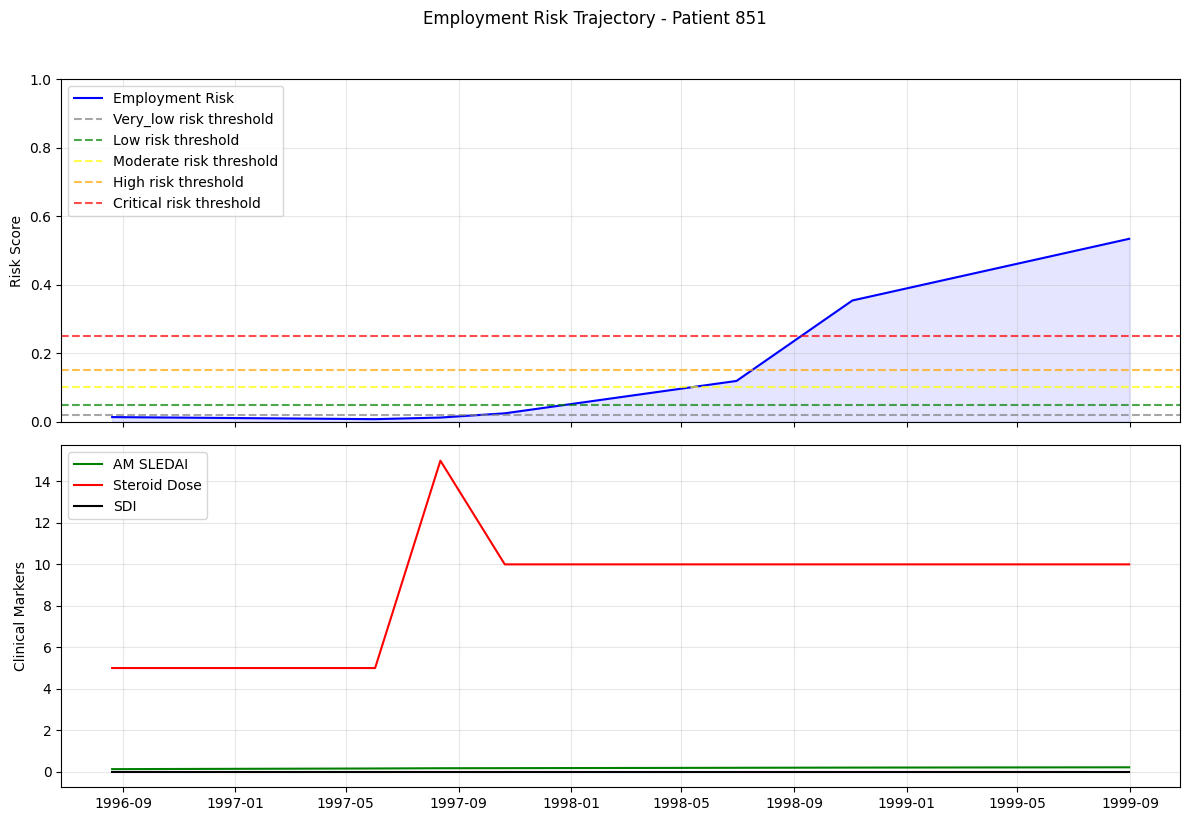

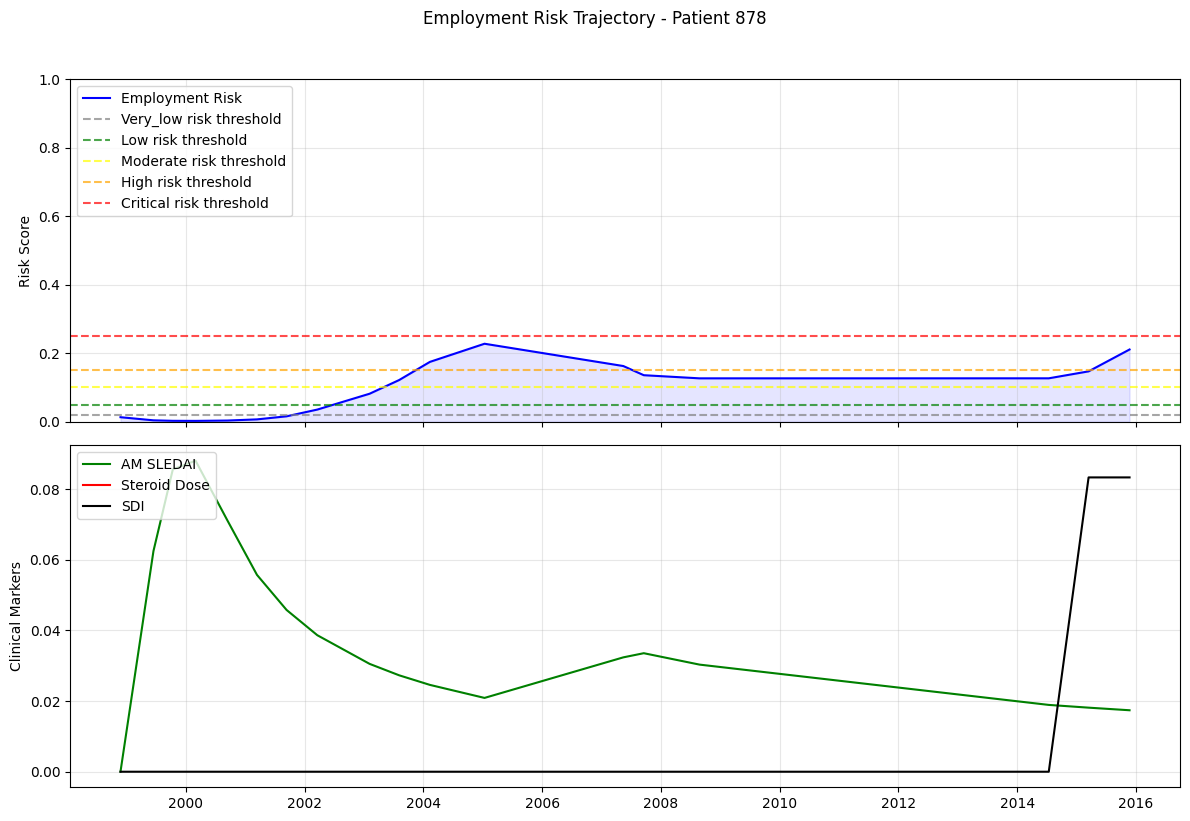

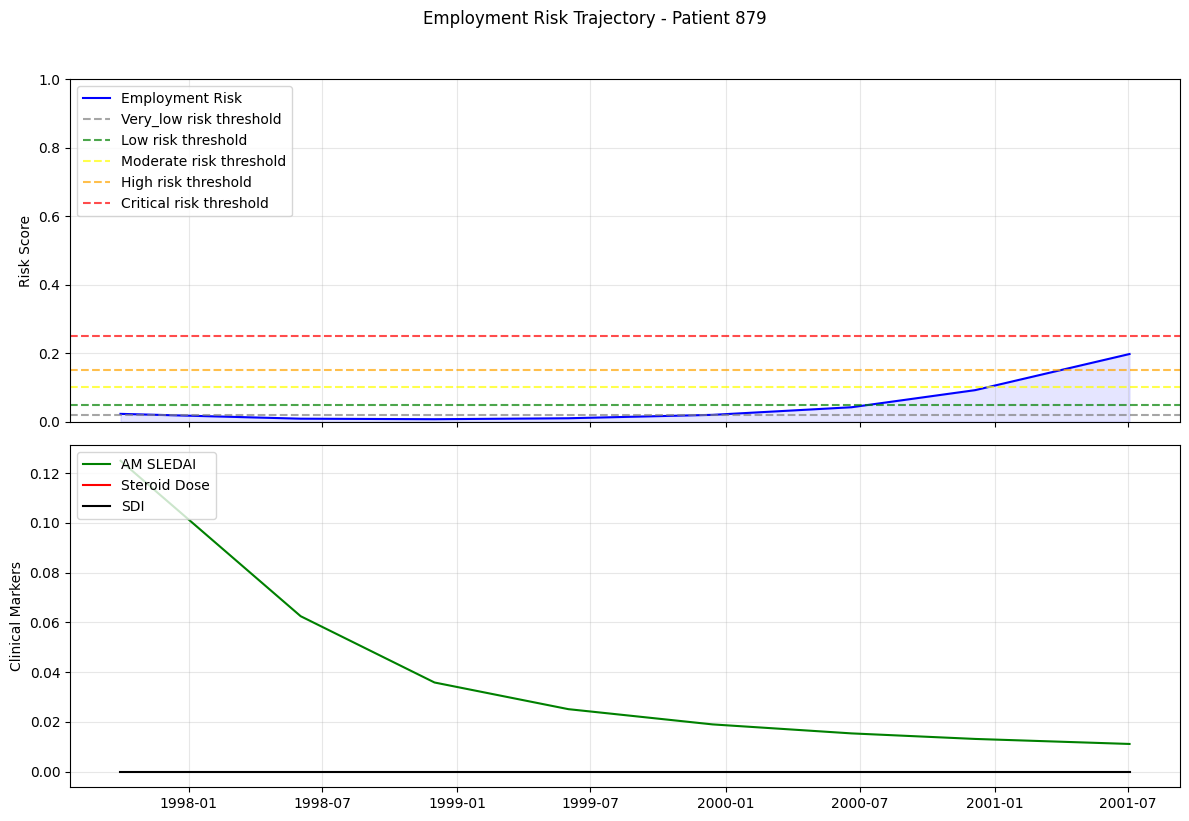

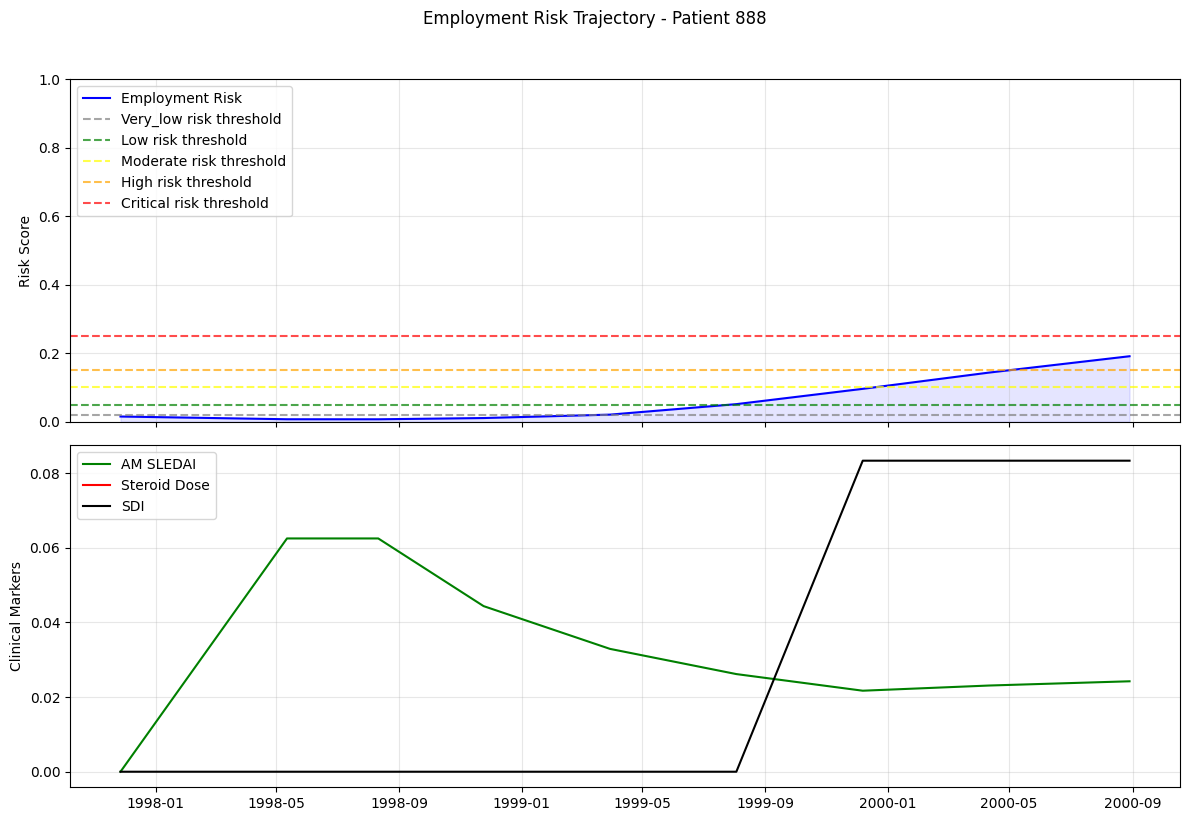

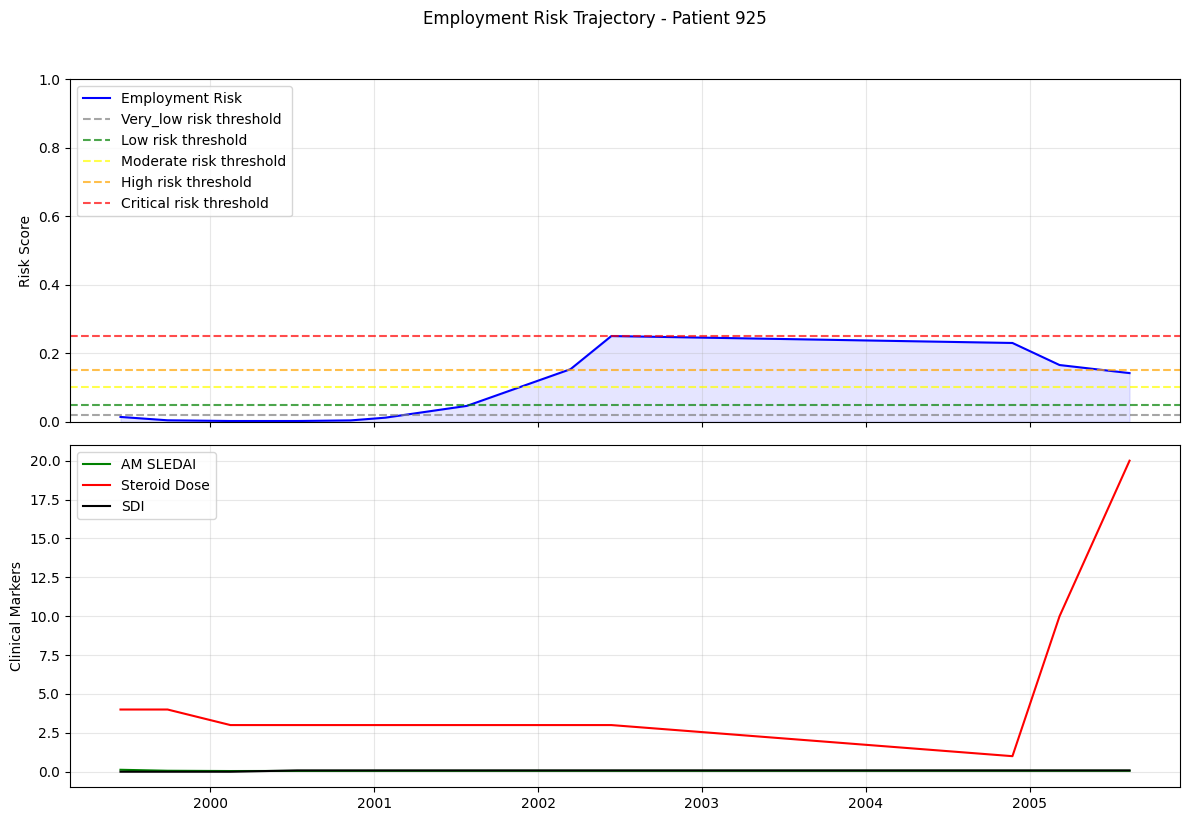

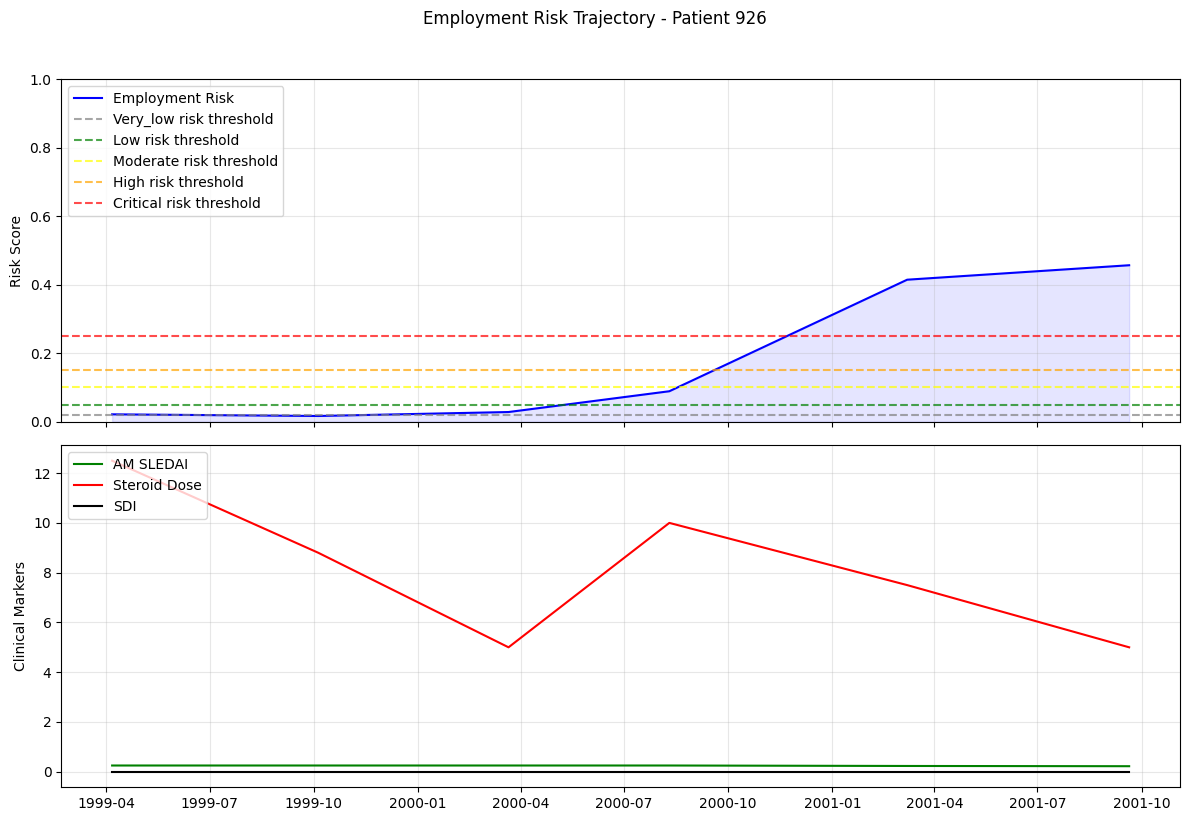

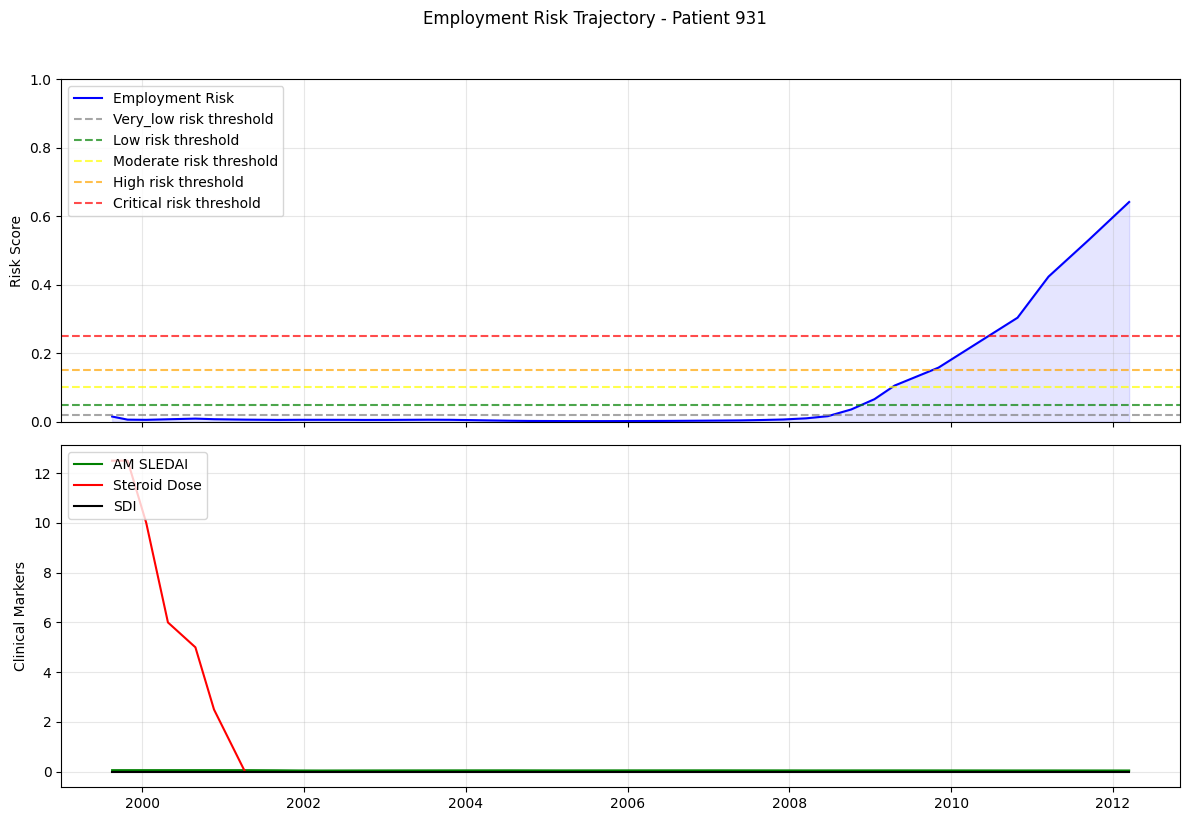

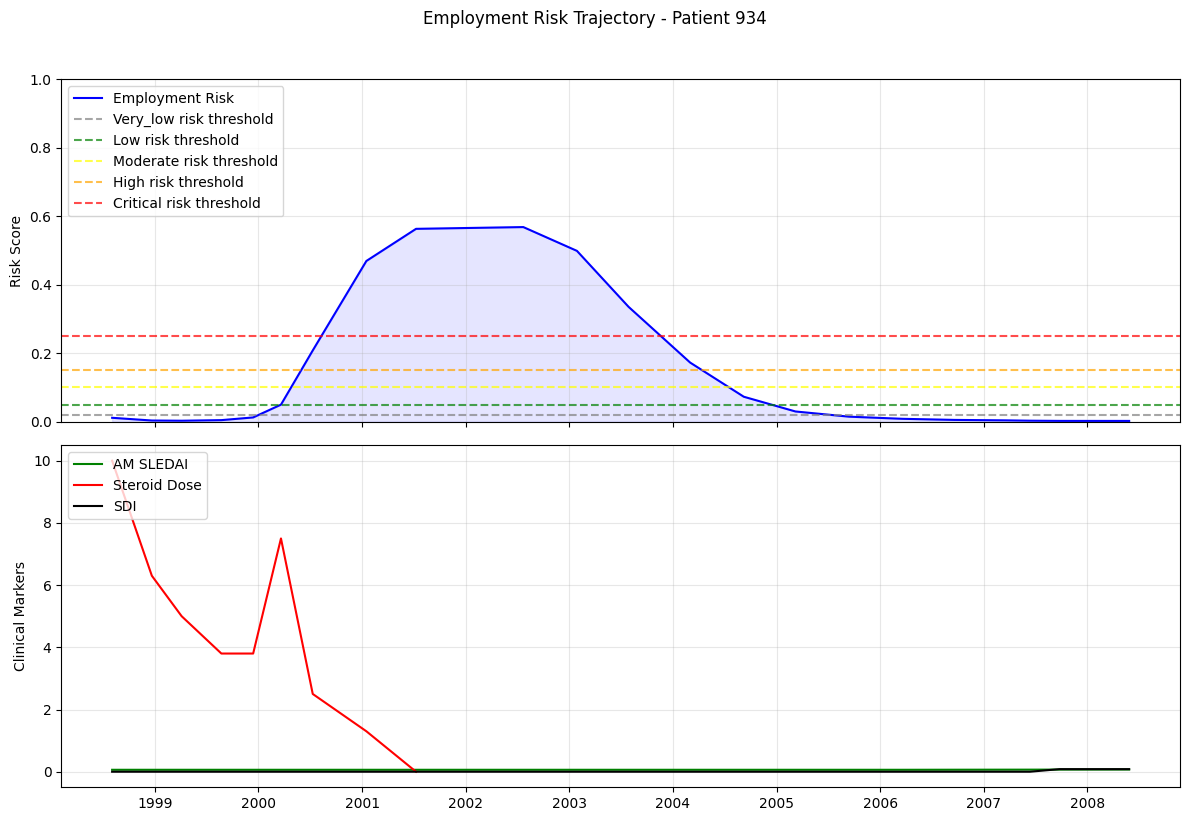

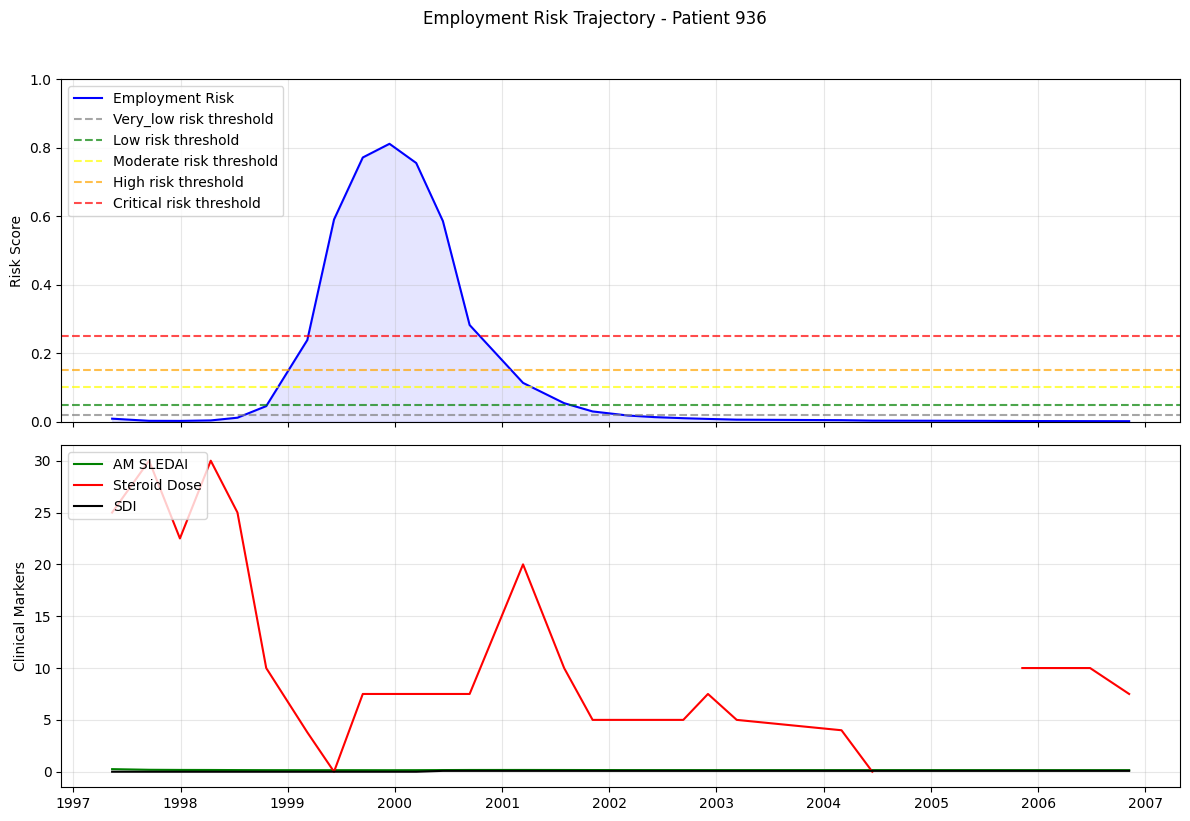

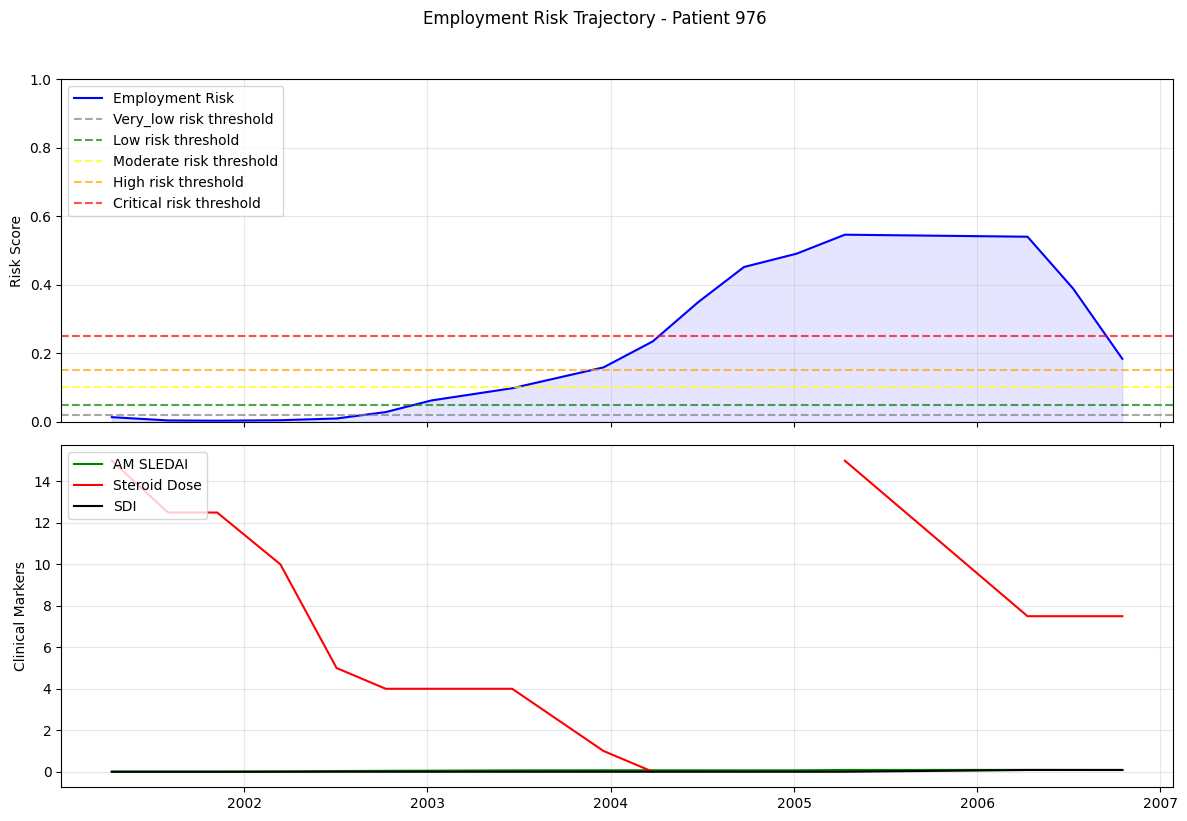

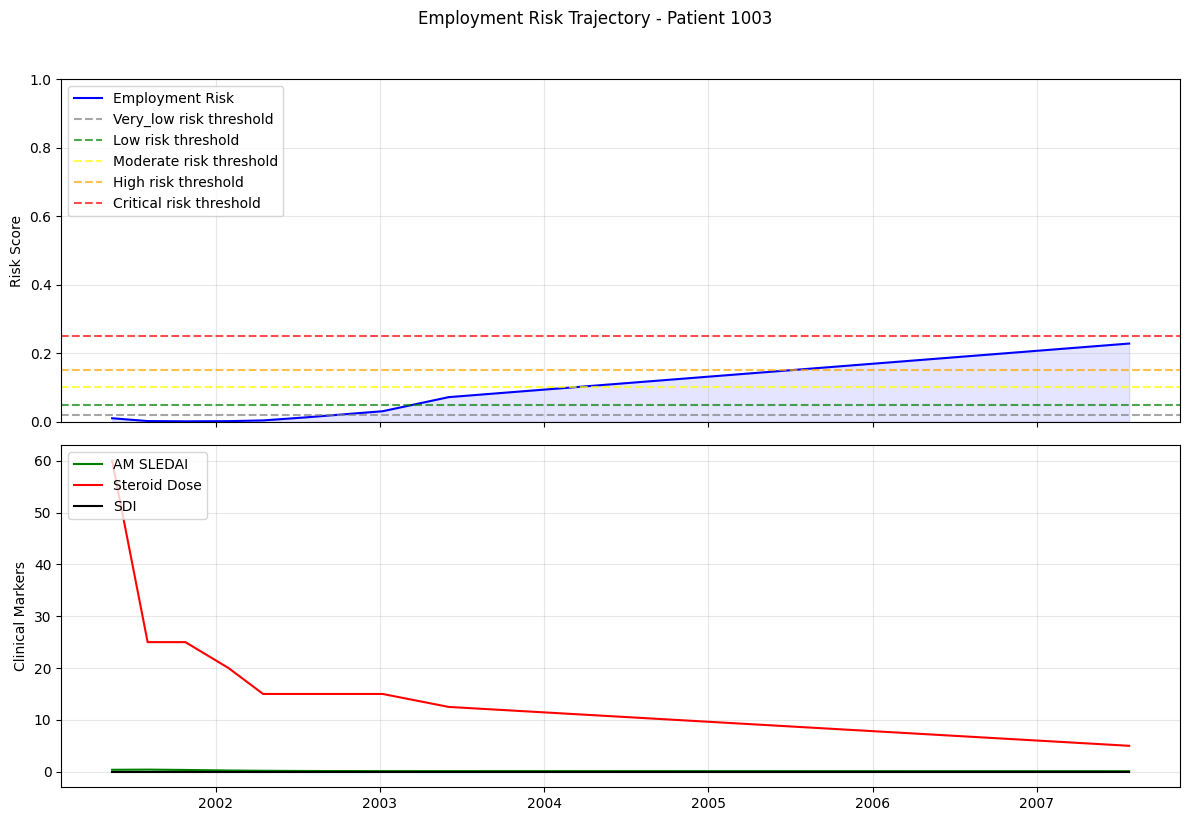

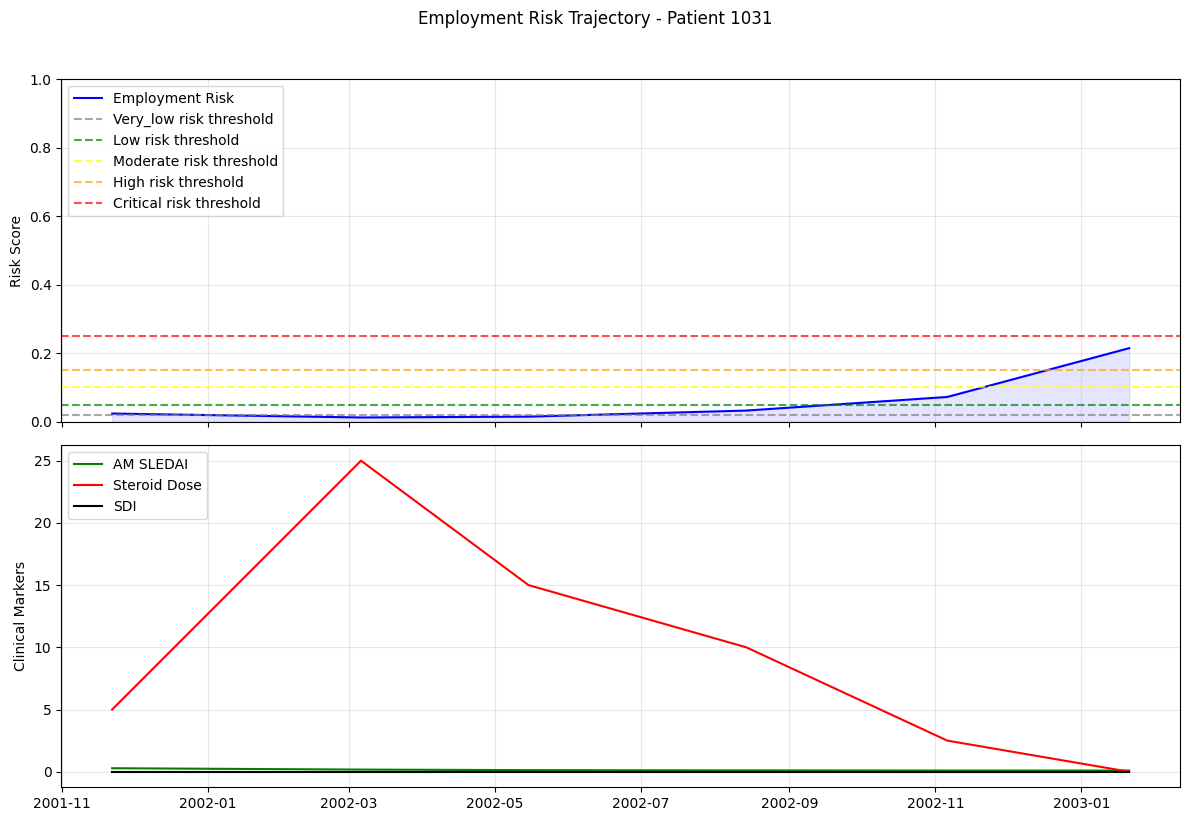

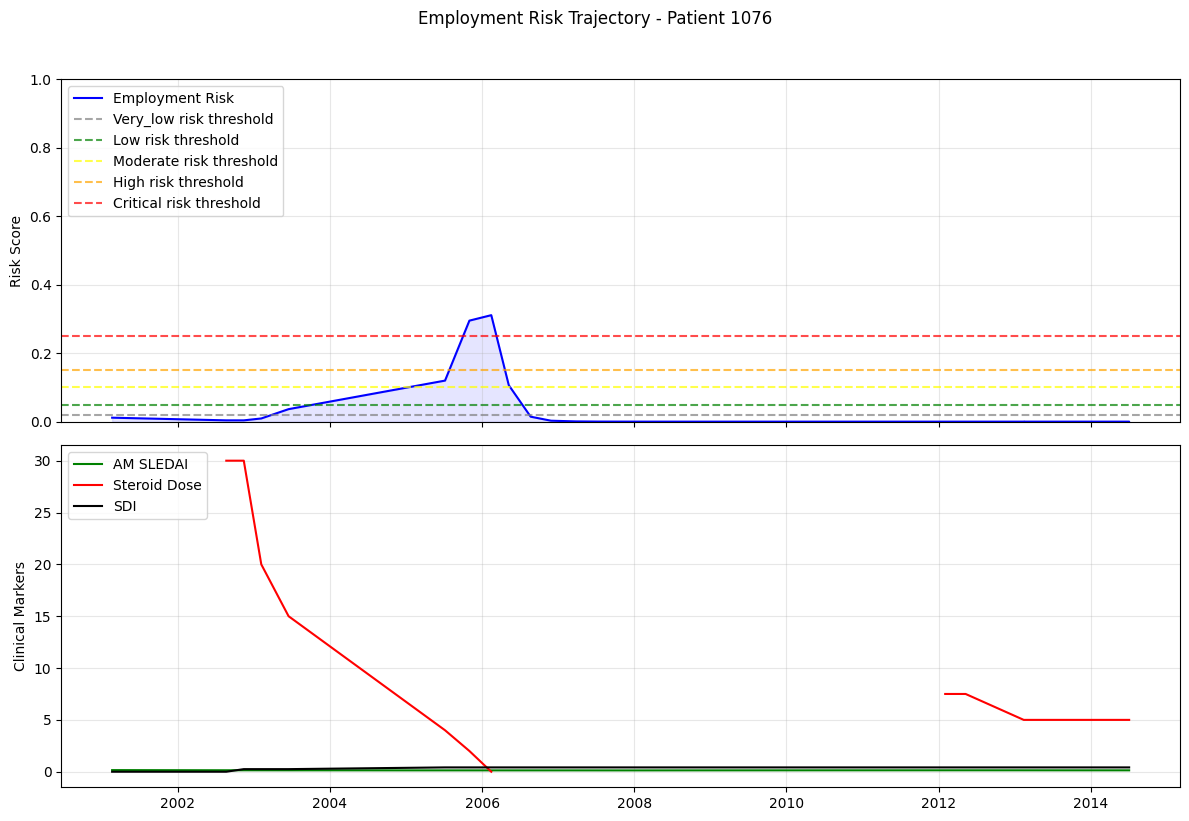

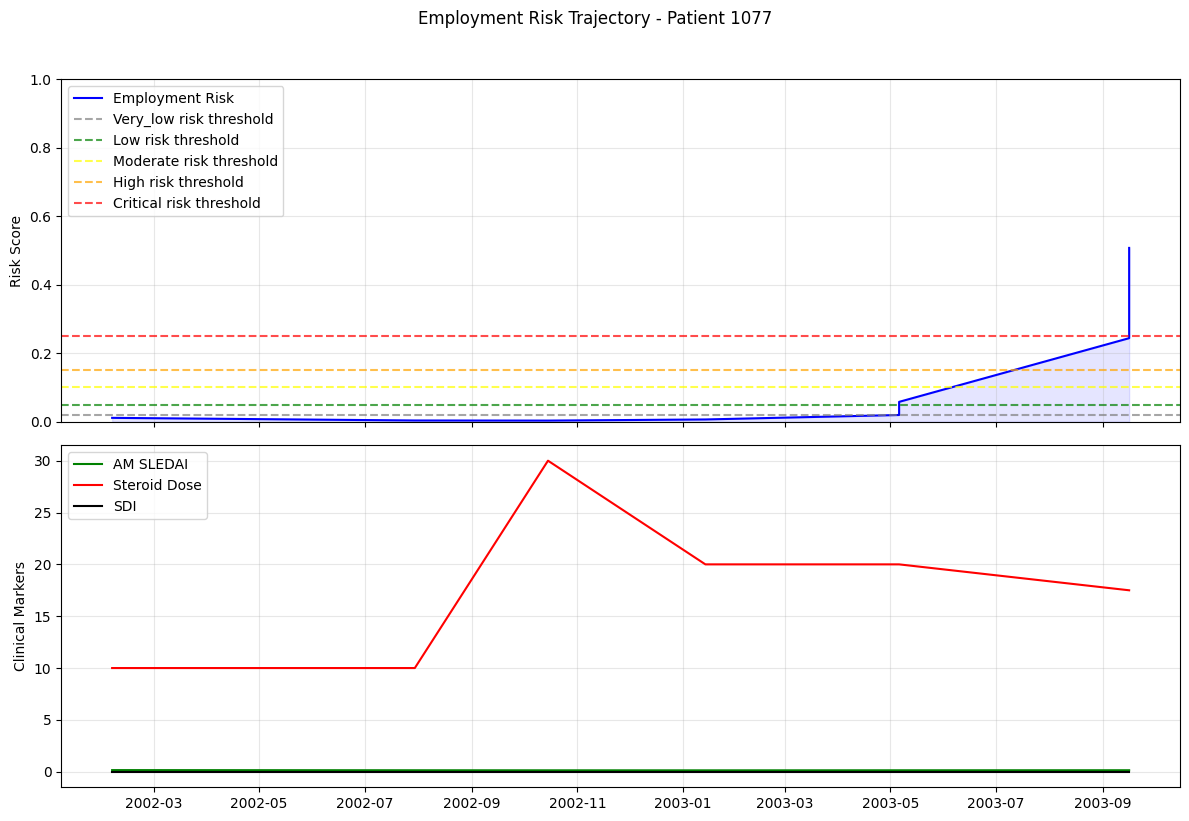

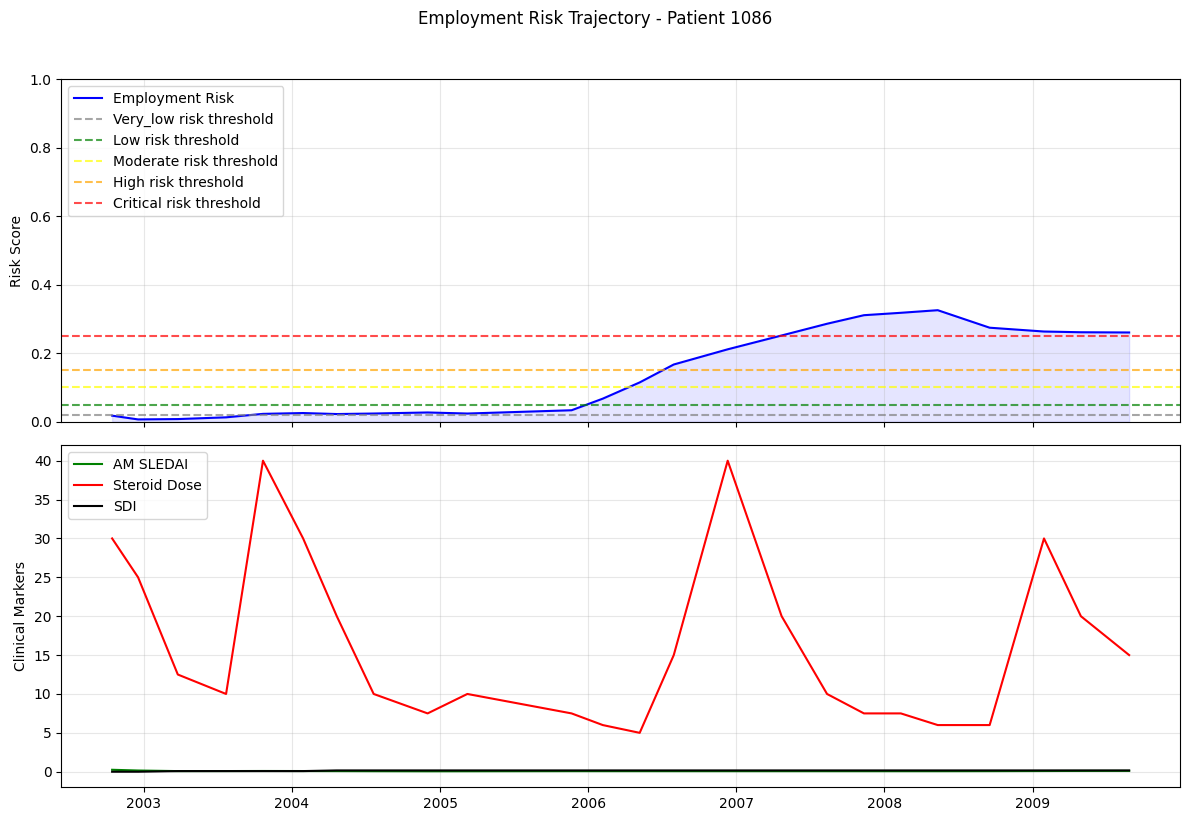

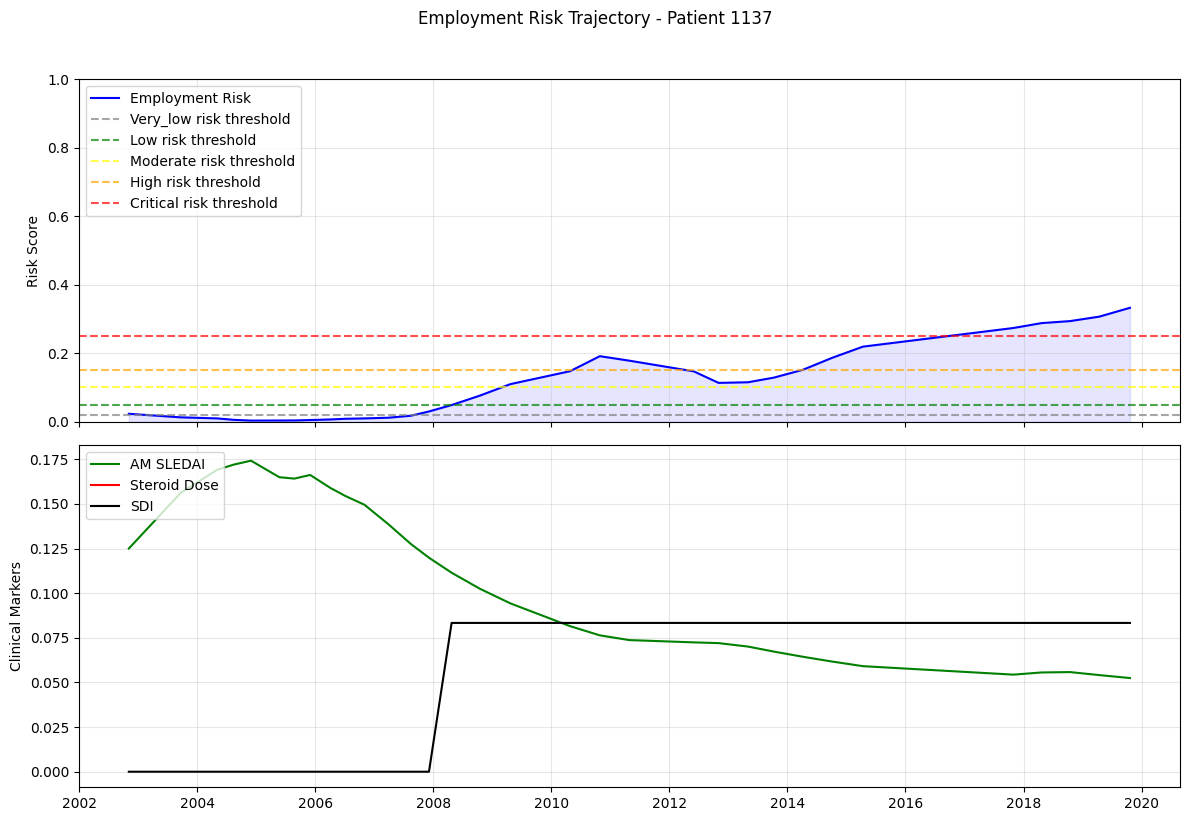

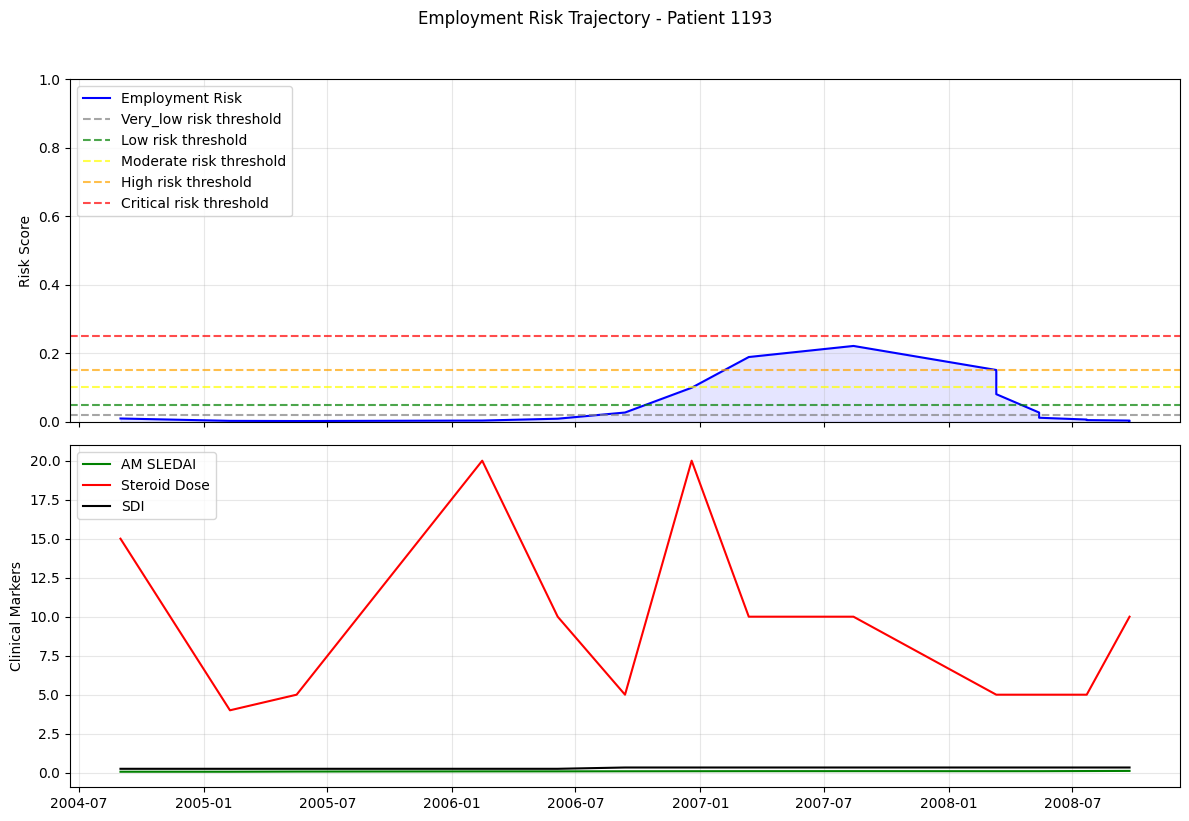

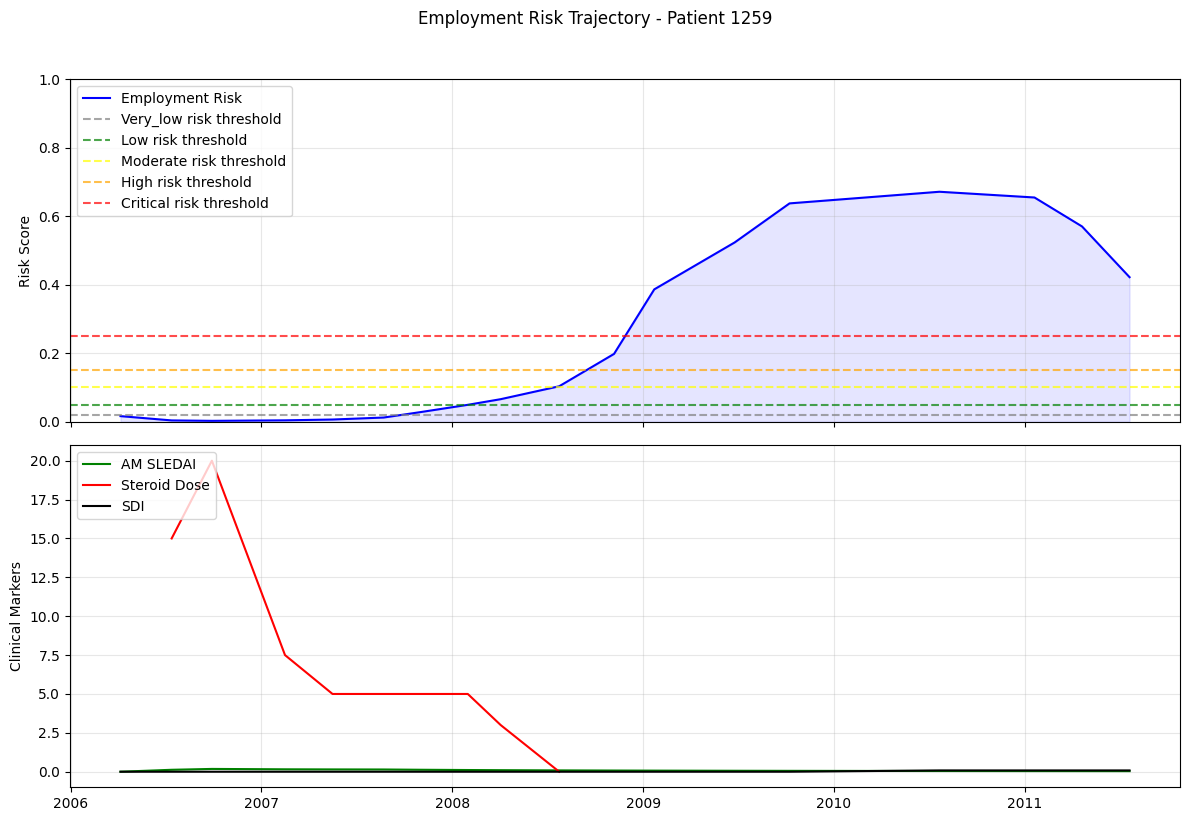

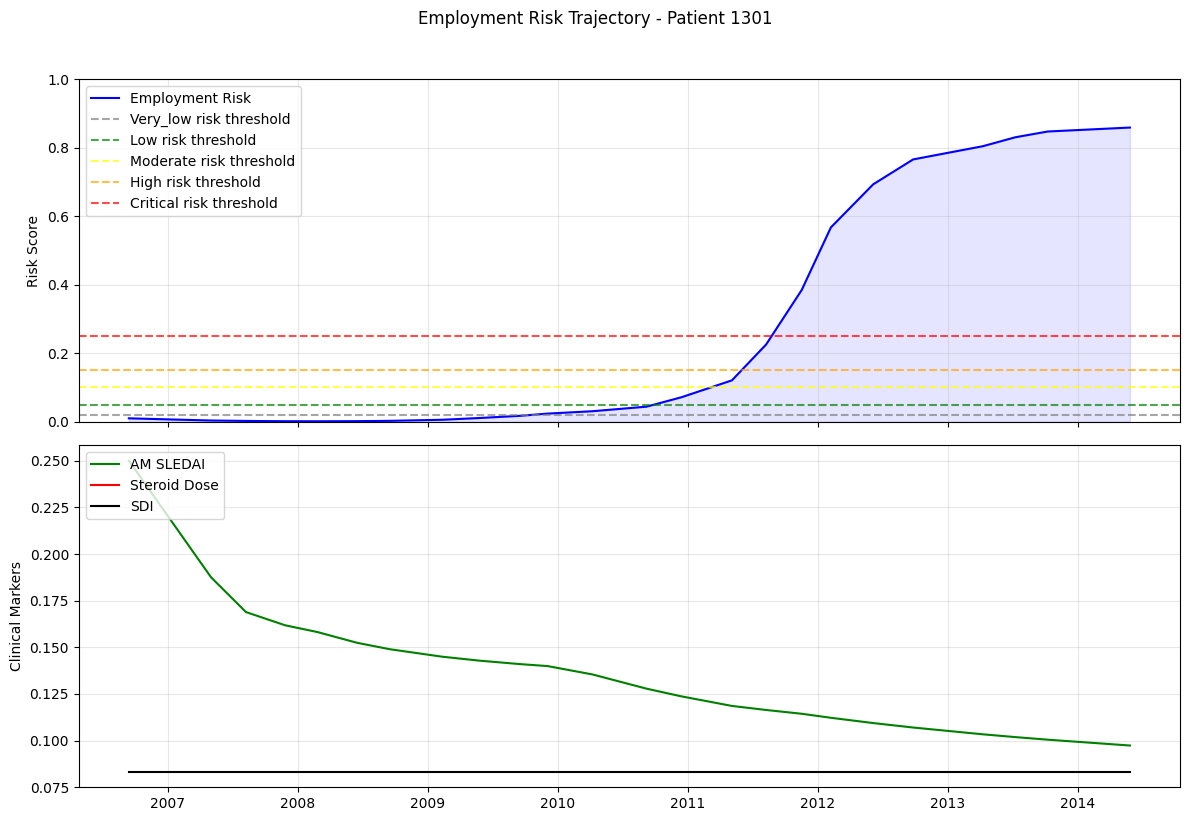

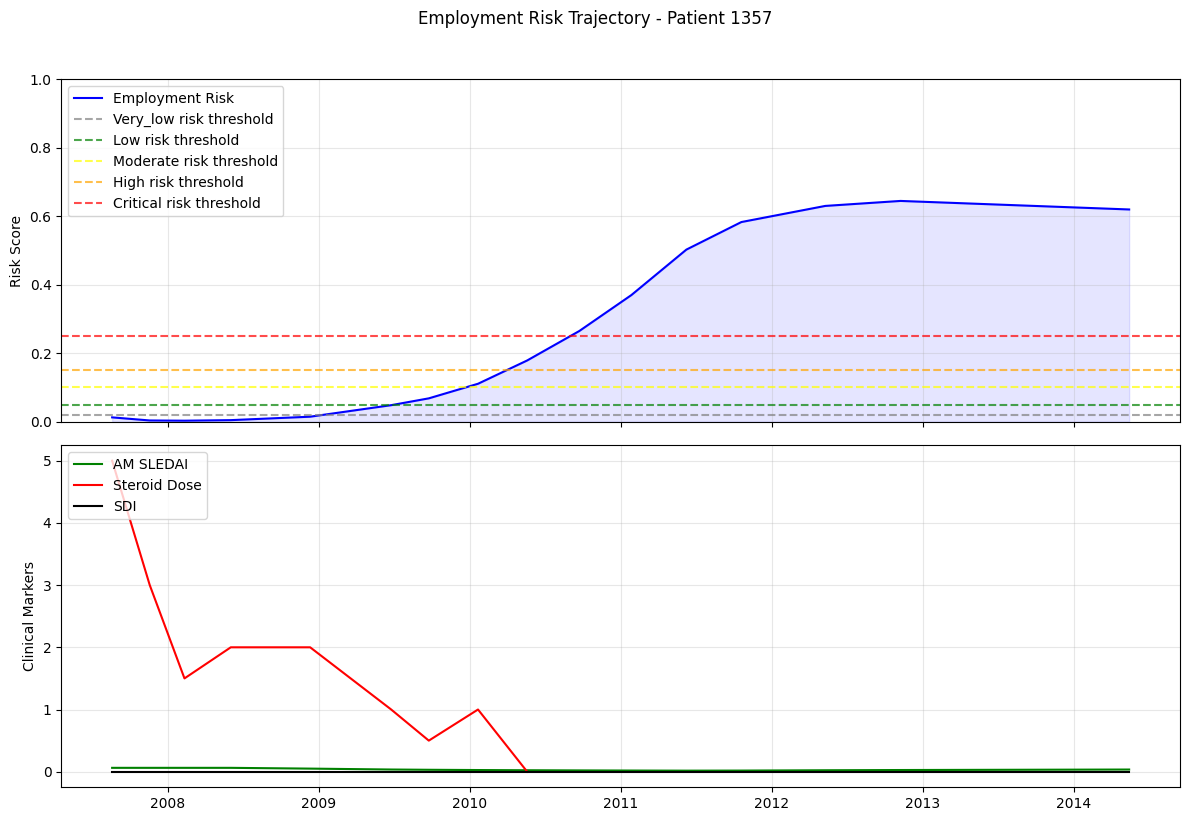

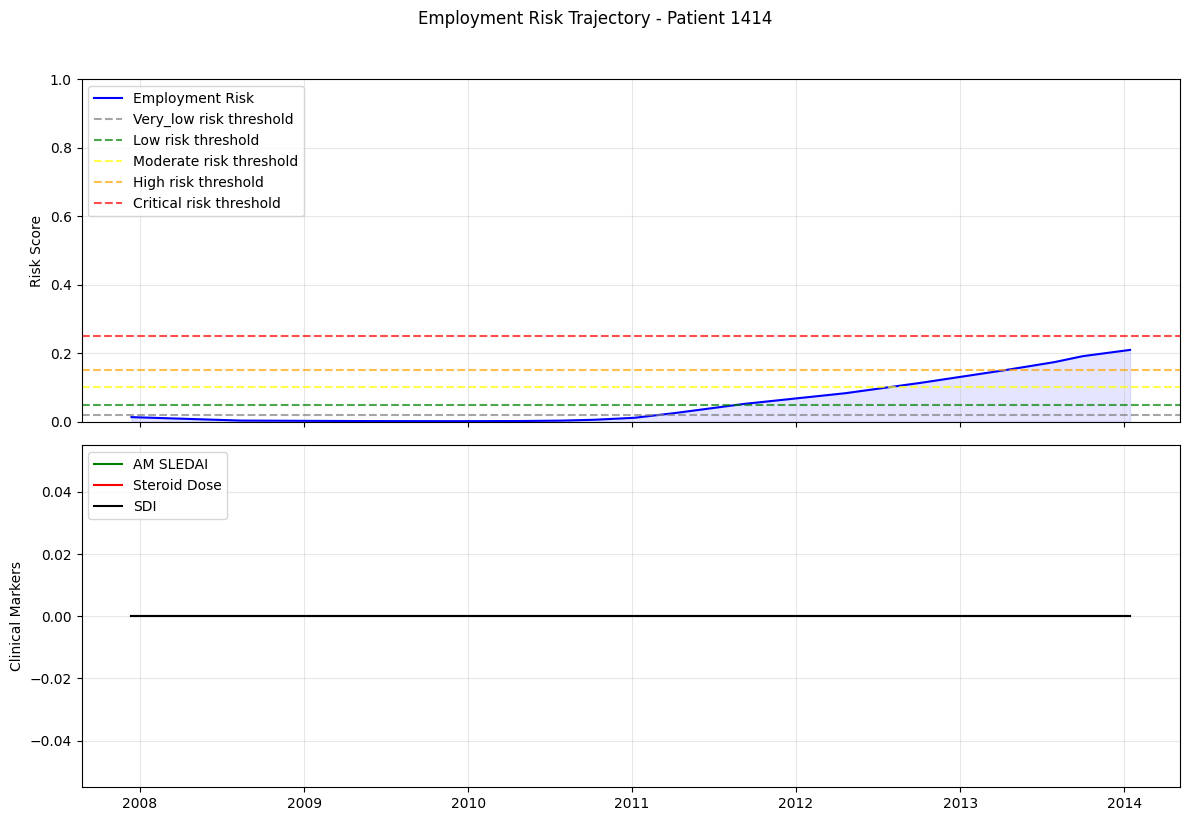

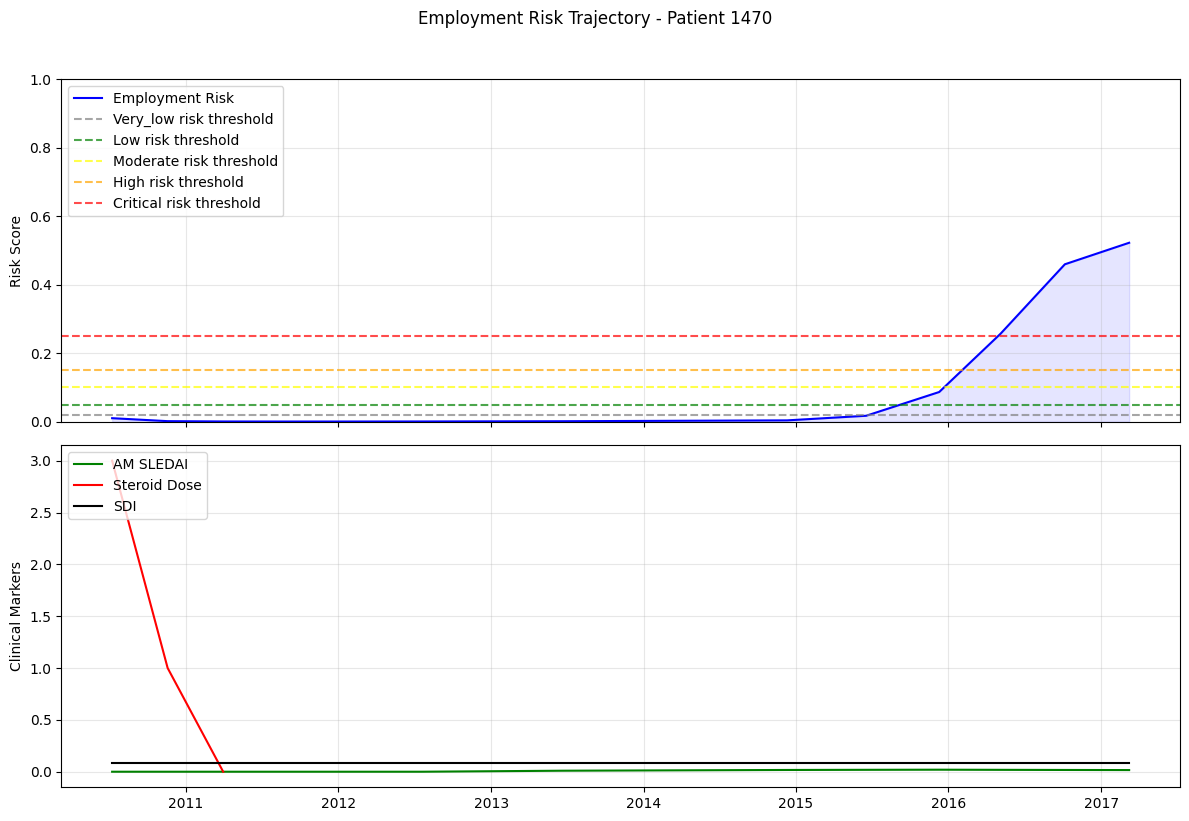

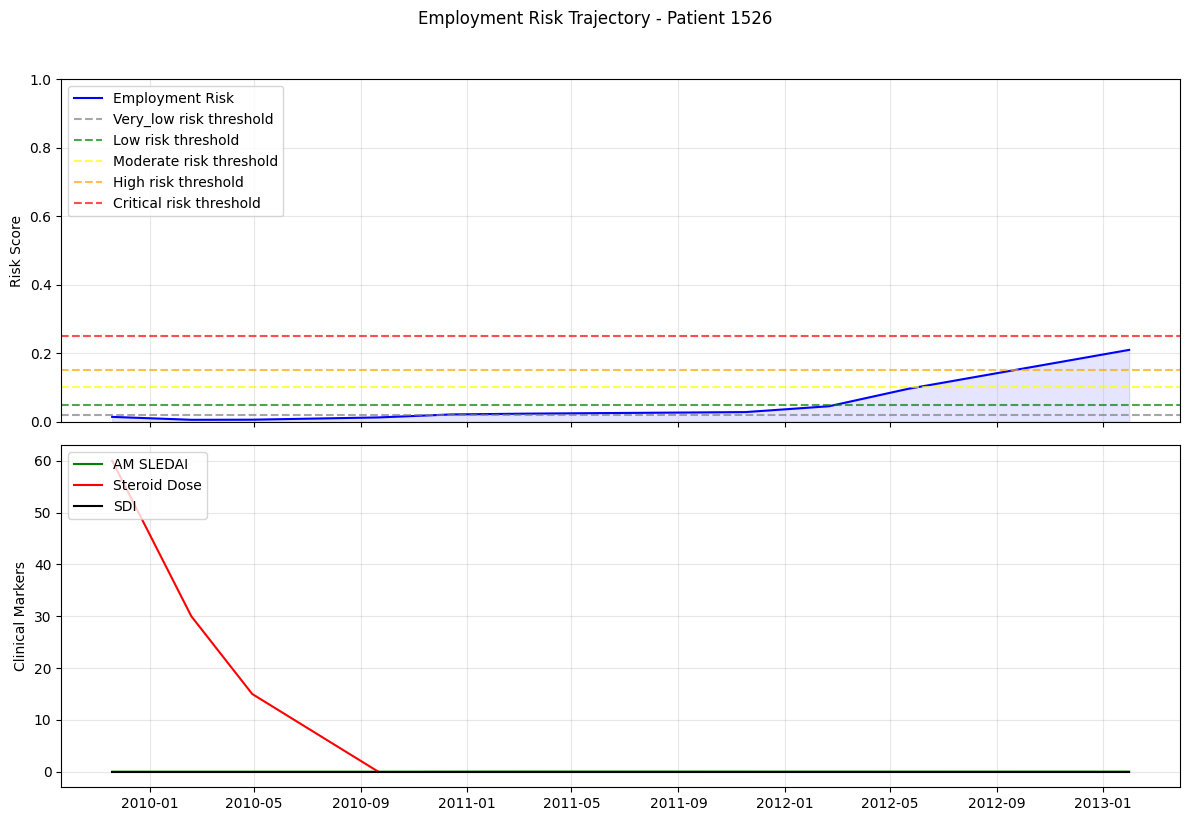

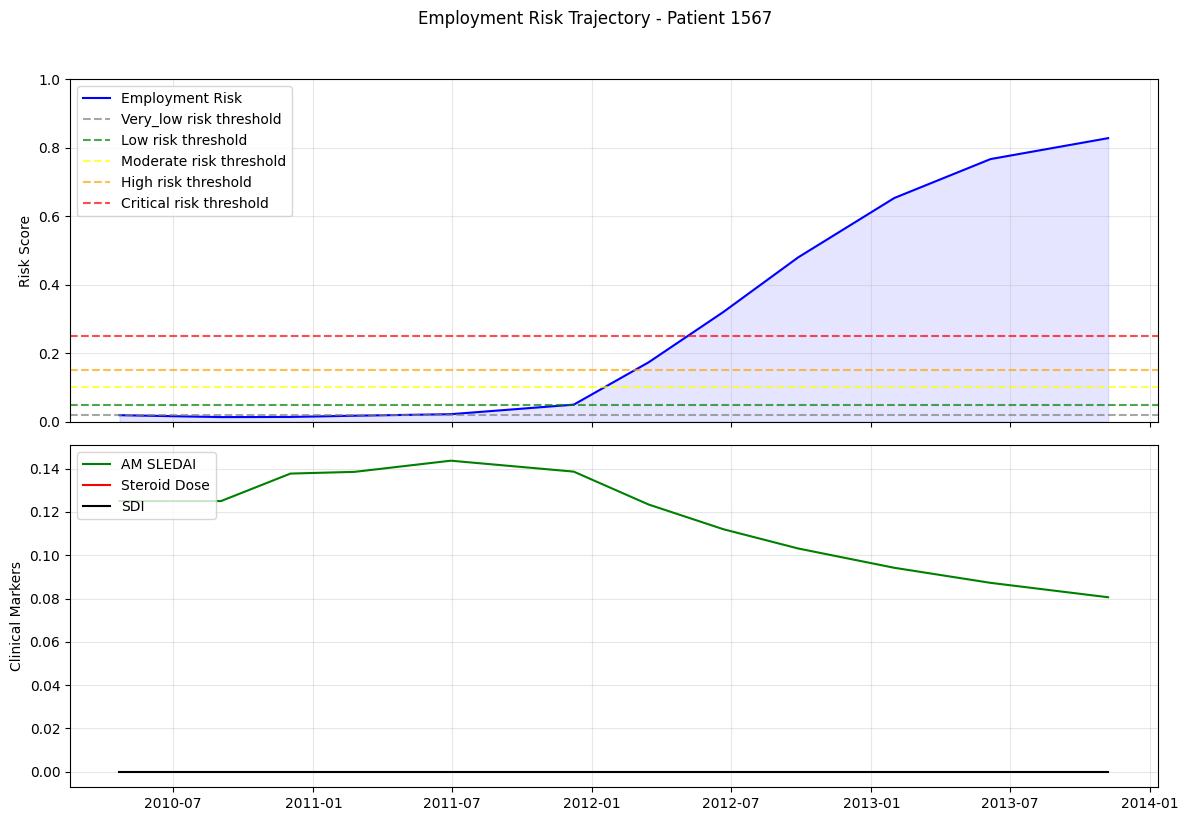

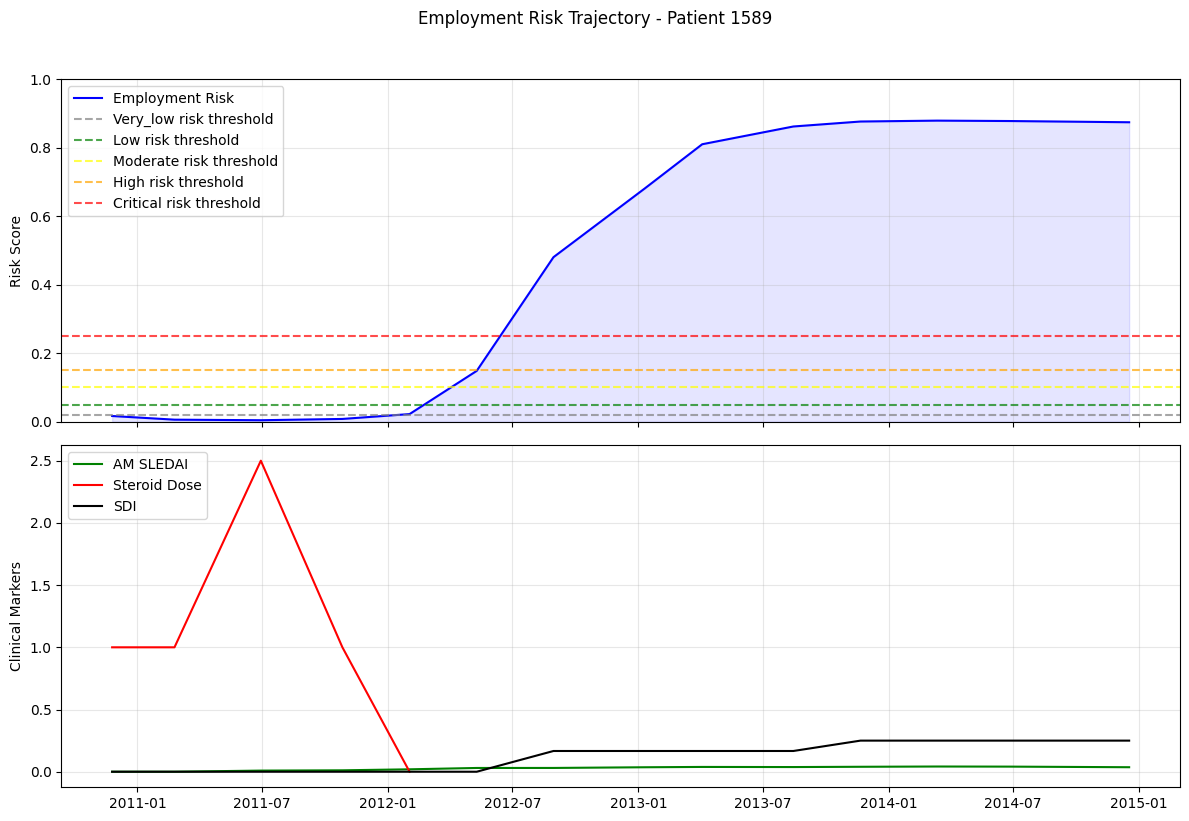

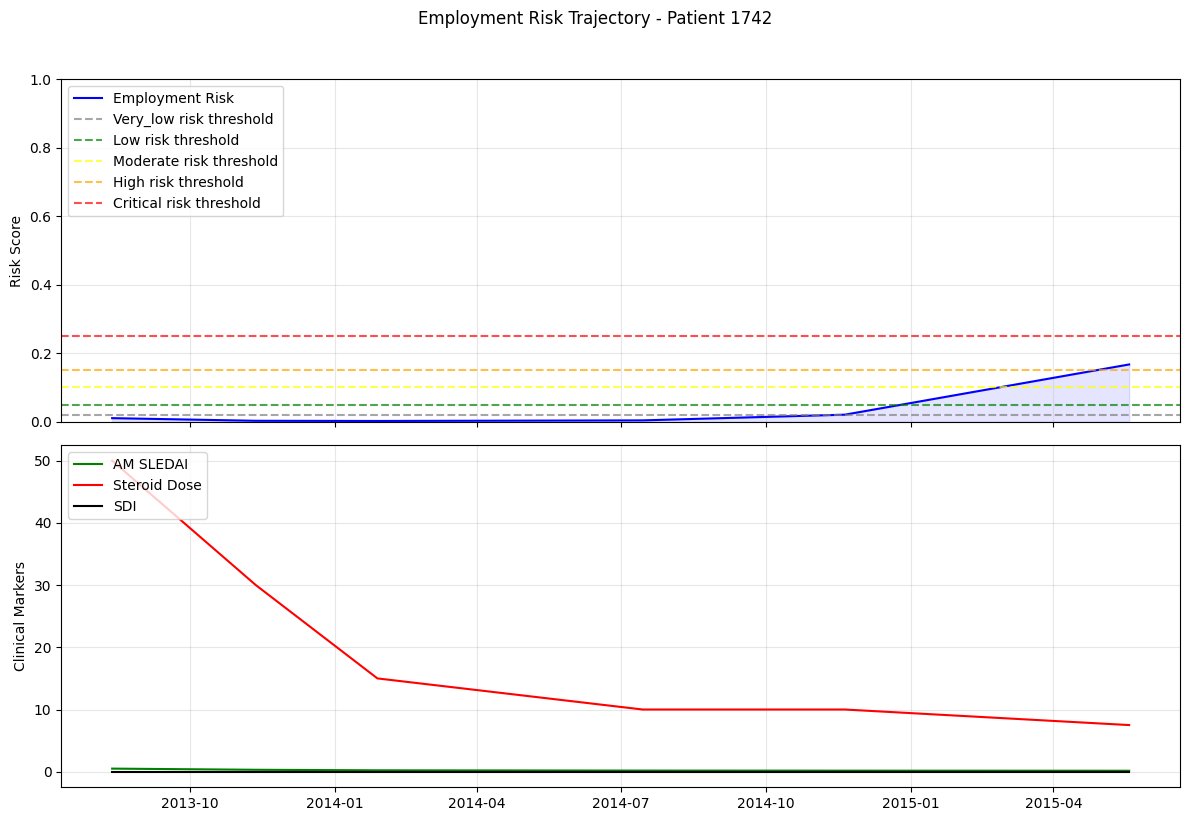

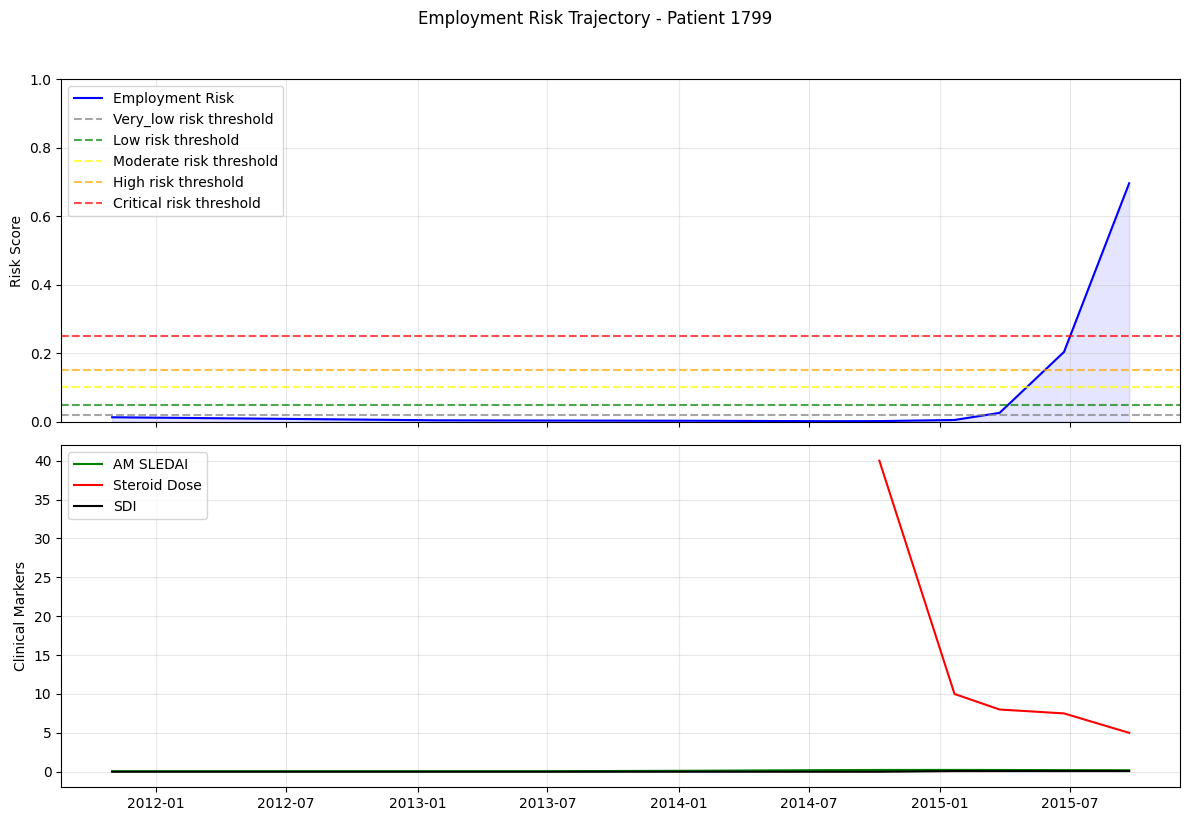

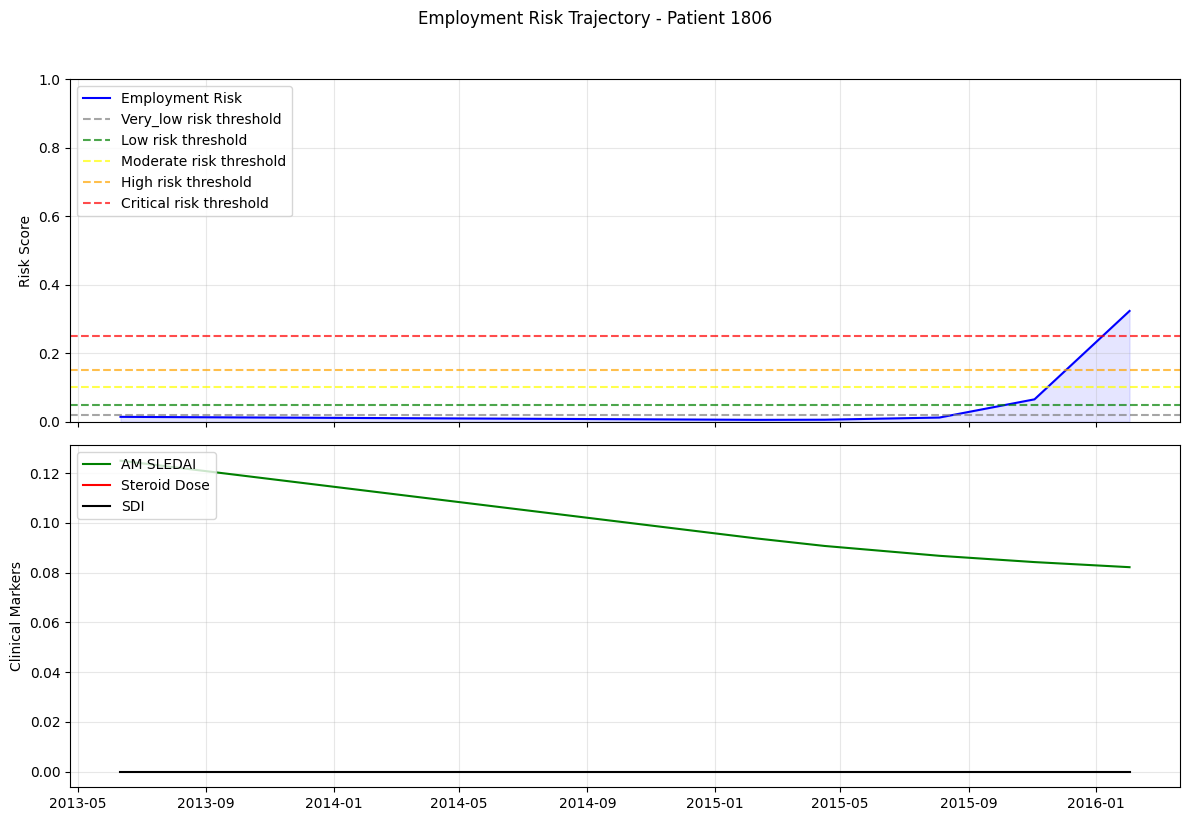

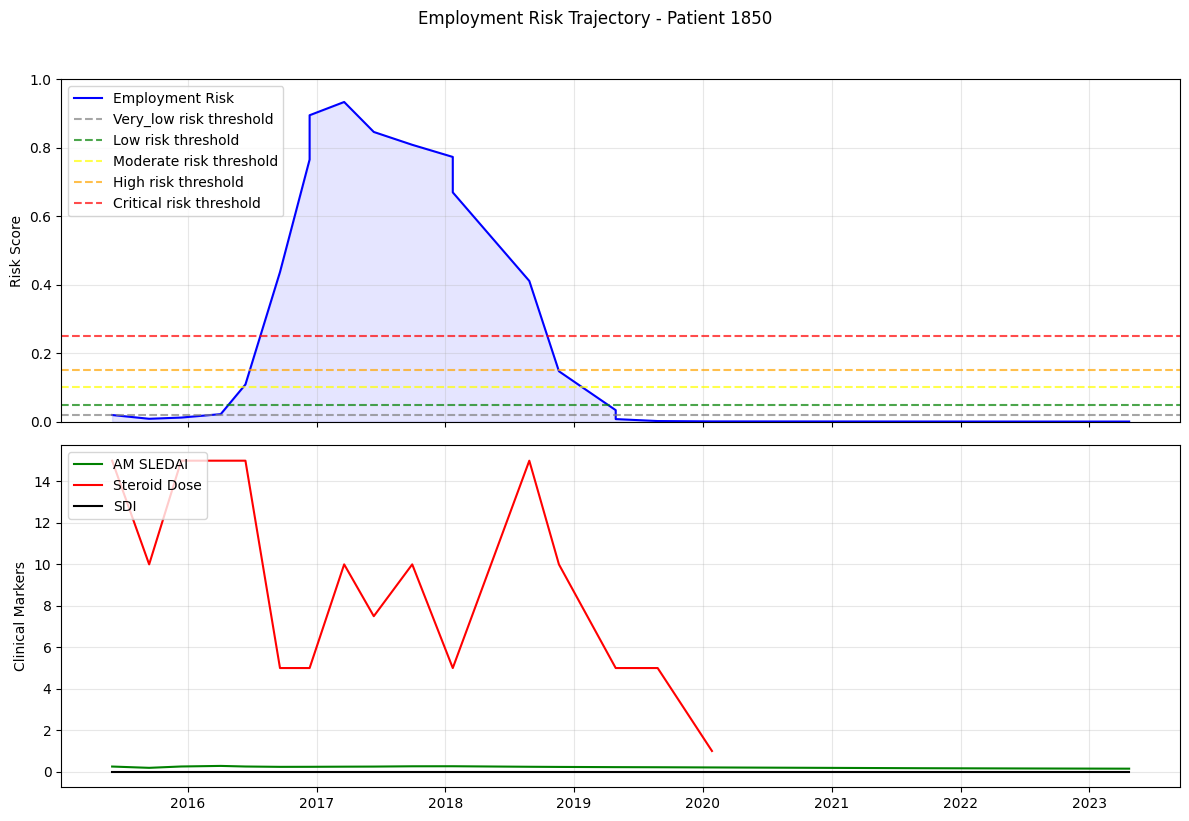

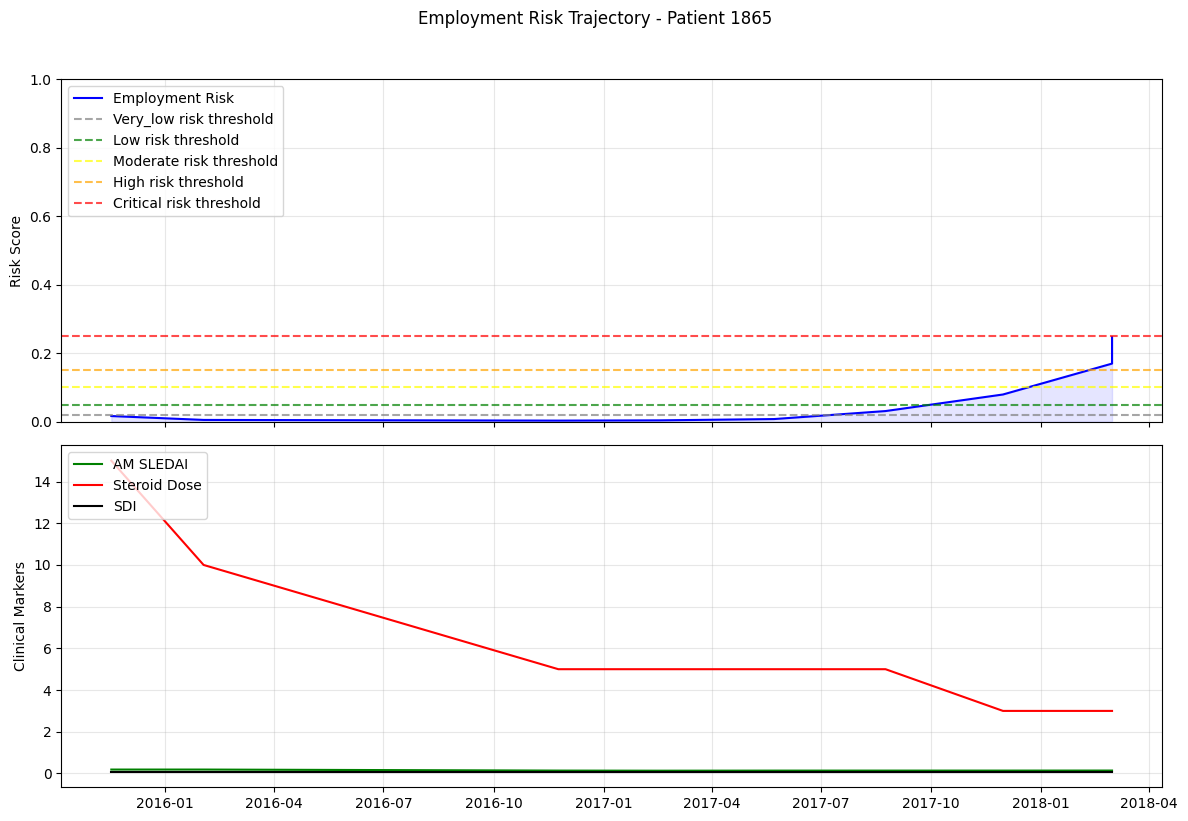

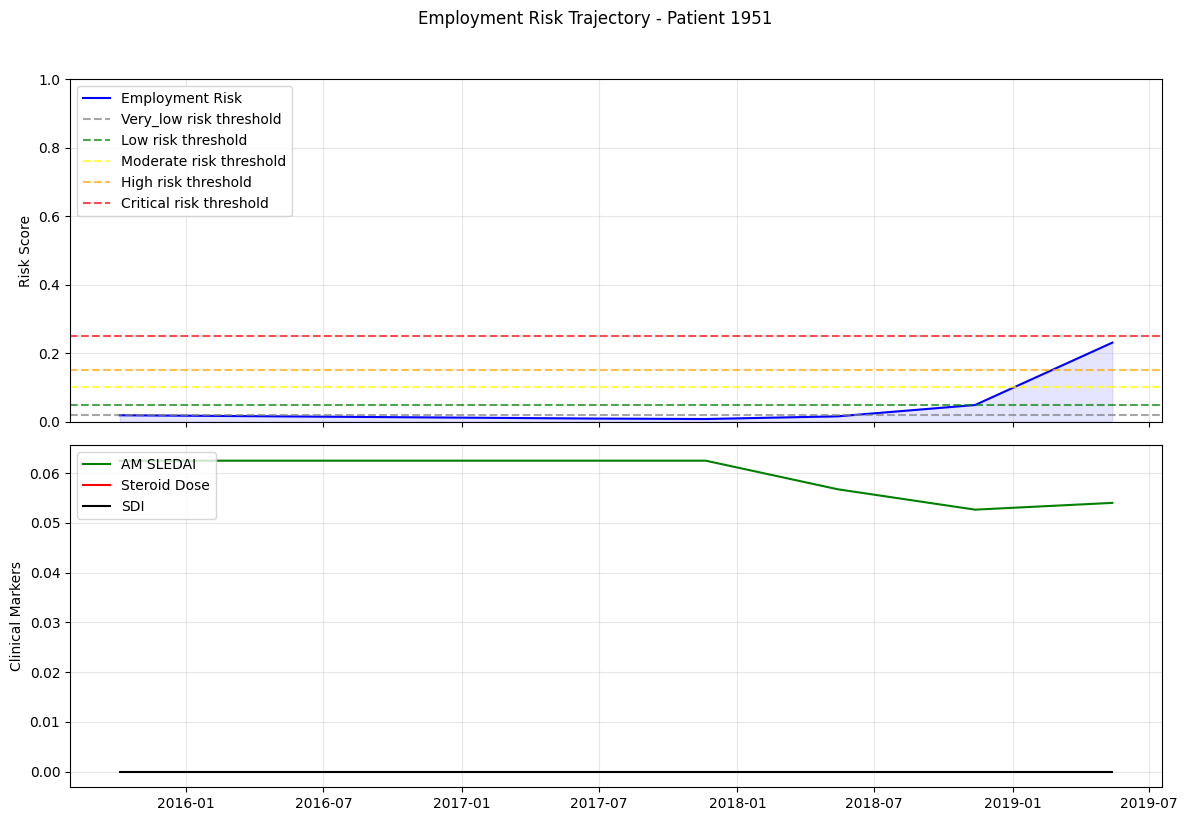

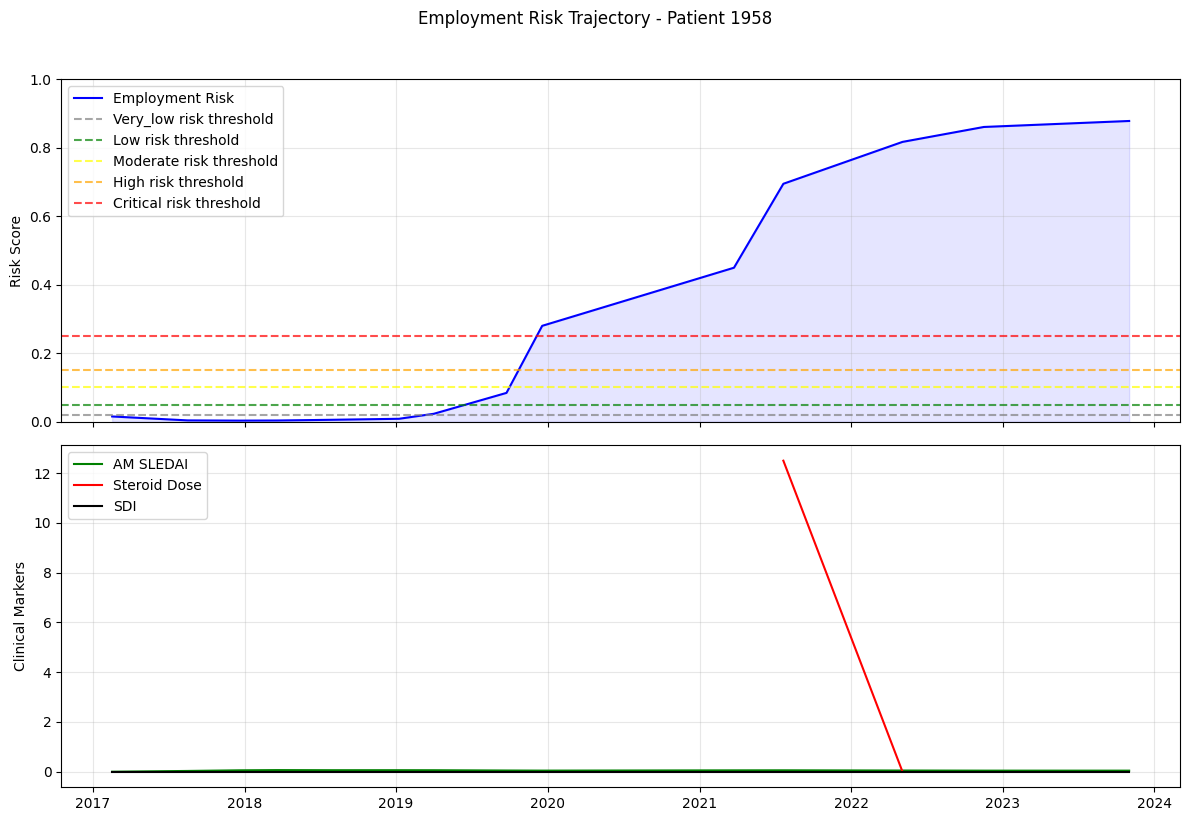

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, average_precision_score
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict
from tqdm import tqdm

class OptimizedEmploymentRiskAnalyzer:
    def __init__(self, model, features, label_encoder, n_folds=5, random_state=42):
        self.model = model
        self.features = features
        self.label_encoder = label_encoder
        self.n_folds = n_folds
        self.random_state = random_state
        self.risk_thresholds = None  # Will be determined through CV
        self.threshold_candidates = np.linspace(0.05, 0.5, 10)  # Candidate thresholds to evaluate
        
    def determine_optimal_thresholds(self, X, y):
        """
        Determine optimal risk thresholds using cross-validation
        """
        skf = StratifiedKFold(n_splits=self.n_folds, shuffle=True, random_state=self.random_state)
        threshold_metrics = defaultdict(list)
        
        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Train model (if needed) or just predict on validation set
            y_probs = self.model.predict(X_val)[:, 1]  # Probability of positive class
            
            # Evaluate different thresholds
            for threshold in self.threshold_candidates:
                y_pred = (y_probs >= threshold).astype(int)
                precision, recall, _ = precision_recall_curve(y_val, y_probs)
                ap_score = average_precision_score(y_val, y_probs)
                
                threshold_metrics[threshold].append({
                    'precision': precision[1],
                    'recall': recall[1],
                    'ap_score': ap_score
                })
        
        # Calculate average metrics for each threshold
        avg_metrics = {}
        for threshold, metrics_list in threshold_metrics.items():
            avg_metrics[threshold] = {
                'mean_precision': np.mean([m['precision'] for m in metrics_list]),
                'mean_recall': np.mean([m['recall'] for m in metrics_list]),
                'mean_ap': np.mean([m['ap_score'] for m in metrics_list])
            }
        
        # Select threshold with best balance of precision and recall
        best_threshold = max(self.threshold_candidates, 
                            key=lambda t: avg_metrics[t]['mean_precision'] + avg_metrics[t]['mean_recall'])
        
        # Define tiered thresholds based on optimal threshold
        self.risk_thresholds = {
            'very_low': best_threshold * 0.3,
            'low': best_threshold * 0.6,
            'moderate': best_threshold * 0.8,
            'high': best_threshold,
            'critical': min(best_threshold * 1.5, 0.99)
        }
        
        return self.risk_thresholds
    
    def filter_employed_periods(self, data, min_employment_duration=3):
        """
        Filter to only include data points where patient was employed
        and add employment duration information
        """
        data = data.copy()
        data['EMPf_lower'] = data['EMPf'].str.lower()
        
        # Calculate employment duration in months
        def calculate_duration(group):
            employed_mask = group['EMPf_lower'].str.contains('employed', na=False)
            if employed_mask.any():
                first_employed_date = group.loc[employed_mask, 'ASSDT'].min()
                group['employment_duration'] = (group['ASSDT'] - first_employed_date).dt.days / 30
            else:
                group['employment_duration'] = np.nan
            return group
        
        # Filter to only employed periods
        employed_data = data[data['EMPf_lower'].str.contains('employed', na=False)].copy()
        
        # Calculate duration for each patient
        employed_data = employed_data.groupby('PTNO', group_keys=False).apply(calculate_duration)
        
        # Remove patients with very short employment duration
        max_duration = employed_data.groupby('PTNO')['employment_duration'].max()
        valid_patients = max_duration[max_duration >= min_employment_duration].index
        employed_data = employed_data[employed_data['PTNO'].isin(valid_patients)]
        
        return employed_data
    
    def calculate_future_risk(self, patient_data, risk_window=12):
        """
        Calculate whether the patient will transition out of employment within risk_window months
        from each observation point
        """
        if len(patient_data) == 0:
            return pd.DataFrame()
            
        last_date = patient_data['ASSDT'].max()
        patient_data['future_employment_loss'] = False
        
        for idx, row in patient_data.iterrows():
            future_cutoff = row['ASSDT'] + pd.DateOffset(months=risk_window)
            future_status = patient_data[
                (patient_data['ASSDT'] > row['ASSDT']) & 
                (patient_data['ASSDT'] <= future_cutoff)]
            
            if not future_status.empty:
                # Check if any future status shows employment loss
                if not future_status['EMPf_lower'].str.contains('employed').all():
                    patient_data.at[idx, 'future_employment_loss'] = True
        
        return patient_data
    
    def calculate_trajectory_features(self, patient_data):
        """
        Calculate trajectory-based features for employment risk prediction
        """
        if len(patient_data) < 2:
            return patient_data
            
        # Sort by date to ensure proper calculation of changes
        patient_data = patient_data.sort_values('ASSDT')
        
        # Calculate time since last observation
        patient_data['time_since_last'] = patient_data['ASSDT'].diff().dt.days.fillna(0)
        
        # Calculate rates of change for key metrics
        for metric in ['score_n', 'AMS', 'STERDOSE']:
            if metric in patient_data.columns:
                patient_data[f'{metric}_change'] = patient_data[metric].diff() / patient_data['time_since_last'].clip(lower=1)
                patient_data[f'{metric}_trend'] = patient_data[metric].rolling(3, min_periods=1).mean()
        
        # Flare accumulation features
        if 'severe_flare' in patient_data.columns:
            patient_data['flare_accumulation_6mo'] = patient_data['severe_flare'].rolling(
                window=3, min_periods=1).sum()
        
        # Employment stability features
        if 'AGE_DX' in patient_data.columns and 'age_at_record' in patient_data.columns:
            patient_data['employment_stability'] = patient_data['employment_duration'] / (
                patient_data['age_at_record'] - patient_data['AGE_DX']).clip(lower=1)
        
        return patient_data
        
    def predict_risk_trajectory(self, patient_data, max_seq_length):
        """Predict risk scores across the patient's trajectory while employed"""
        if len(patient_data) == 0:
            return pd.DataFrame()
            
        # Prepare sequence data for the model
        seq_len = len(patient_data)
        num_features = len(self.features)
        X_patient = np.zeros((1, max_seq_length, num_features))
        
        # Use original feature values (no scaling)
        for i, feature in enumerate(self.features):
            if feature in patient_data.columns:
                X_patient[0, :seq_len, i] = patient_data[feature].values
        
        # Get predictions for each time point
        predictions = []
        for i in range(1, seq_len + 1):
            partial_seq = X_patient.copy()
            partial_seq[0, i:, :] = 0  # Mask future data
            pred = self.model.predict(partial_seq, verbose=0)[0]
            predictions.append(pred[1])  # Probability of positive class
        
        # Create result dataframe
        result = patient_data[['ASSDT', 'EMPf', 'employment_duration', 'future_employment_loss']].copy()
        result['base_risk'] = predictions
        
        # Categorize risk using dynamic thresholds
        if self.risk_thresholds:
            # Create bins and labels for categorization
            thresholds = sorted(self.risk_thresholds.values())
            bins = [0] + thresholds + [1.0]
            labels = ['very_low', 'low', 'moderate', 'high', 'critical']
            
            result['risk_category'] = pd.cut(
                result['base_risk'],
                bins=bins,
                labels=labels,
                include_lowest=True
            )
        else:
            result['risk_category'] = 'undefined'
        
        return result
        
    def enhance_risk_with_clinical_factors(self, risk_df, clinical_data):
        """
        Enhance base risk prediction with clinical factor weighting
        """
        enhanced_risks = []
        for idx, row in risk_df.iterrows():
            clinical_row = clinical_data.loc[idx]
            enhancement_factor = 1.0
            
            # SDI-based enhancement
            if 'score_n' in clinical_row and clinical_row['score_n'] >= 1:
                enhancement_factor *= 1.3
                
            # Steroid-based enhancement
            if 'STEROID_CAT_numeric' in clinical_row and clinical_row['STEROID_CAT_numeric'] >= 2:
                enhancement_factor *= 1.2
                
            # Flare-based enhancement
            if 'severe_flare' in clinical_row and clinical_row['severe_flare'] >= 1:
                enhancement_factor *= 1.4
                
            # Employment duration protection
            if 'employment_duration' in clinical_row and clinical_row['employment_duration'] >= 24:
                enhancement_factor *= 0.9
                
            enhanced_risk = min(row['base_risk'] * enhancement_factor, 0.99)
            enhanced_risks.append(enhanced_risk)
            
        risk_df['enhanced_risk'] = enhanced_risks
        return risk_df
    
    def plot_risk_trajectory(self, ptno, risk_df, clinical_data):
        """
        Generate a comprehensive risk trajectory plot for a single patient
        """
        if len(risk_df) == 0 or not self.risk_thresholds:
            return None
            
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        fig.suptitle(f'Employment Risk Trajectory - Patient {ptno}', y=1.02)
        
        # Risk curve
        ax1.plot(risk_df['ASSDT'], risk_df['enhanced_risk'], 
                'b-', label='Employment Risk')
        ax1.fill_between(risk_df['ASSDT'], risk_df['enhanced_risk'], 
                        color='blue', alpha=0.1)
        
        # Add threshold lines
        for name, threshold in self.risk_thresholds.items():
            ax1.axhline(y=threshold, color=self._get_threshold_color(name), 
                       linestyle='--', alpha=0.7,
                       label=f'{name.capitalize()} risk threshold')
        
        ax1.set_ylabel('Risk Score')
        ax1.set_ylim(0, 1)
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Clinical markers
        if 'AMS' in clinical_data.columns:
            ax2.plot(clinical_data['ASSDT'], clinical_data['AMS'],
                    'g-', label='AM SLEDAI')
                    
        if 'STERDOSE' in clinical_data.columns:
            ax2.plot(clinical_data['ASSDT'], clinical_data['STERDOSE'],
                    'r-', label='Steroid Dose')
                    
        if 'score_n' in clinical_data.columns:
            ax2.plot(clinical_data['ASSDT'], clinical_data['score_n'],
                    'k-', label='SDI')
                    
        ax2.set_ylabel('Clinical Markers')
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)
        
        # Highlight actual employment loss if it occurred
        if risk_df['future_employment_loss'].any():
            loss_date = risk_df[risk_df['future_employment_loss']]['ASSDT'].min()
            for ax in [ax1, ax2]:
                ax.axvline(x=loss_date, color='red', linestyle=':', 
                           label='Actual Employment Loss')
                ax.legend()
        
        plt.tight_layout()
        return fig
    
    def _get_threshold_color(self, level):
        """Get consistent colors for risk thresholds"""
        colors = {
            'critical': 'red',
            'high': 'orange',
            'moderate': 'yellow',
            'low': 'green',
            'very_low': 'lightgreen'
        }
        return colors.get(level, 'gray')
    
    def analyze_patients(self, data, origdata, max_seq_length, min_employment_duration=3, risk_window=12):
        """
        Main analysis workflow:
        1. Filter to employed periods
        2. Calculate future outcomes
        3. Generate risk predictions
        4. Enhance with clinical factors
        """
        # Filter to employed periods and add employment duration
        employed_data = self.filter_employed_periods(data, min_employment_duration)
        
        if len(employed_data) == 0:
            print("No employed patient data found")
            return None, None
            
        # Calculate future employment loss within risk window
        employed_data = employed_data.groupby('PTNO', group_keys=False).apply(
            lambda x: self.calculate_future_risk(x, risk_window))
            
        # Calculate trajectory features
        employed_data = employed_data.groupby('PTNO', group_keys=False).apply(
            self.calculate_trajectory_features)
            
        # Prepare data for threshold determination
        X = []
        y = []
        for _, patient_data in employed_data.groupby('PTNO'):
            if len(patient_data) < 2:
                continue
                
            # Prepare sequence data
            seq_len = len(patient_data)
            num_features = len(self.features)
            X_patient = np.zeros((1, max_seq_length, num_features))
            
            for i, feature in enumerate(self.features):
                if feature in patient_data.columns:
                    X_patient[0, :seq_len, i] = patient_data[feature].values
            
            # Get predictions for each time point (except last)
            for i in range(1, seq_len):
                partial_seq = X_patient.copy()
                partial_seq[0, i:, :] = 0  # Mask future data
                pred = self.model.predict(partial_seq, verbose=0)[0]
                X.append(partial_seq)
                y.append(patient_data['future_employment_loss'].iloc[i])
        
        # Determine optimal thresholds if we have sufficient data
        if len(y) > 100 and sum(y) > 20:  # Minimum samples and positive cases
            X_array = np.concatenate(X, axis=0)
            y_array = np.array(y)
            self.determine_optimal_thresholds(X_array, y_array)
        else:
            print("Insufficient data for threshold optimization - using defaults")
            self.risk_thresholds = {
                'very_low': 0.05,
                'low': 0.1,
                'moderate': 0.2,
                'high': 0.3,
                'critical': 0.45
            }
        
        # Predict risk for each time point
        risk_results = []
        for ptno, patient_data in employed_data.groupby('PTNO'):
            risk_df = self.predict_risk_trajectory(patient_data, max_seq_length)
            if len(risk_df) > 0:
                risk_df = self.enhance_risk_with_clinical_factors(risk_df, patient_data)
                risk_df['PTNO'] = ptno
                risk_results.append(risk_df)
                
        if not risk_results:
            print("No valid risk predictions generated")
            return None, None
            
        all_risk_results = pd.concat(risk_results)
        
        # Generate trajectory plots for high-risk patients
        if self.risk_thresholds:
            high_risk_threshold = self.risk_thresholds.get('high', 0.3)
            high_risk_patients = all_risk_results[
                all_risk_results['enhanced_risk'] >= high_risk_threshold]['PTNO'].unique()
            
            trajectory_plots = {}
            for ptno in high_risk_patients[:20]:  # Limit to first 20 to avoid too many plots
                pt_risk = all_risk_results[all_risk_results['PTNO'] == ptno]
                pt_data = employed_data[employed_data['PTNO'] == ptno]
                fig = self.plot_risk_trajectory(ptno, pt_risk, pt_data)
                if fig:
                    trajectory_plots[ptno] = fig
        else:
            trajectory_plots = {}
                
        return all_risk_results, trajectory_plots
    
    def generate_early_warning_report(self, risk_results, origdata):
        """
        Generate an enhanced report with original data values and employment status tracking
        
        Args:
            risk_results: DataFrame with risk predictions
            origdata: Original dataset before any scaling/encoding
            
        Returns:
            Dictionary containing comprehensive risk report
        """
        if risk_results is None or len(risk_results) == 0 or not self.risk_thresholds:
            return {"error": "No risk results available or thresholds not determined"}
            
        # Merge with original data to get unscaled values
        enhanced_results = risk_results.merge(
            origdata, 
            on=['PTNO', 'ASSDT'], 
            suffixes=('', '_orig'),
            how='left'
        )
        
        # Initialize report structure
        report = {
            "risk_thresholds": self.risk_thresholds,
            "risk_category_analysis": {},
            "employment_status_at_flagging": {},
            "employment_outcomes": {}
        }
        
        # Analyze each risk category
        threshold_values = sorted(self.risk_thresholds.values())
        categories = sorted(self.risk_thresholds.keys(), key=lambda x: self.risk_thresholds[x])
        
        for i, category in enumerate(categories):
            lower_thresh = 0 if i == 0 else threshold_values[i-1]
            upper_thresh = threshold_values[i]
            
            # Filter to this risk category
            cat_data = enhanced_results[
                (enhanced_results['enhanced_risk'] >= lower_thresh) & 
                (enhanced_results['enhanced_risk'] < upper_thresh)
            ]
            
            # Store basic counts
            report["risk_category_analysis"][category] = {
                "n_patients": cat_data['PTNO'].nunique(),
                "n_observations": len(cat_data)
            }
            
            # Track employment status at time of flagging
            if 'EMPf_orig' in cat_data:
                emp_status_counts = cat_data['EMPf_orig'].value_counts(normalize=True).to_dict()
                report["employment_status_at_flagging"][category] = emp_status_counts
            
            # Calculate proportion that don't end up employed
            if 'future_employment_loss' in cat_data:
                loss_rate = cat_data['future_employment_loss'].mean()
                report["risk_category_analysis"][category]["employment_loss_rate"] = loss_rate
        
        # Add original data statistics for high-risk patients
        high_risk_threshold = self.risk_thresholds.get('high', 0.3)
        high_risk_data = enhanced_results[
            enhanced_results['enhanced_risk'] >= high_risk_threshold
        ]
        
        if len(high_risk_data) > 0:
            report["high_risk_original_data"] = {
                "clinical_markers": {
                    col: {
                        "mean": high_risk_data[col+'_orig'].mean(),
                        "median": high_risk_data[col+'_orig'].median(),
                        "std": high_risk_data[col+'_orig'].std()
                    }
                    for col in ['score_n', 'AMS', 'STERDOSE'] 
                    if col+'_orig' in high_risk_data
                },
                "demographics": {
                    col: high_risk_data[col+'_orig'].value_counts(normalize=True).to_dict()
                    for col in ['SEX', 'RACE'] 
                    if col+'_orig' in high_risk_data
                }
            }
        
        # Add overall statistics
        report["overall"] = {
            "total_patients_analyzed": enhanced_results['PTNO'].nunique(),
            "patients_with_high_risk": len(high_risk_data['PTNO'].unique()) if len(high_risk_data) > 0 else 0,
            "true_positives": enhanced_results['future_employment_loss'].sum(),
            "employment_loss_rate_overall": enhanced_results['future_employment_loss'].mean()
        }
        
        return report


if __name__ == "__main__":
    # Example usage
    analyzer = OptimizedEmploymentRiskAnalyzer(model, features, label_encoder)
    
    # Run analysis with original data
    risk_results, trajectory_plots = analyzer.analyze_patients(data, origdata, max_seq_length=X.shape[1])
    
    if risk_results is not None:
        # Generate enhanced report with original data
        report = analyzer.generate_early_warning_report(risk_results, origdata)
        
        # Print report summary
        print("\n=== OPTIMIZED EMPLOYMENT RISK REPORT ===")
        print(f"Total patients analyzed: {report['overall']['total_patients_analyzed']}")
        print(f"\nOptimized Risk Thresholds:")
        for category, threshold in report['risk_thresholds'].items():
            print(f"{category.capitalize()}: {threshold:.3f}")
        
        # Print risk category analysis
        print("\nRisk Category Analysis:")
        for category, stats in report['risk_category_analysis'].items():
            print(f"{category.capitalize()} Risk:")
            print(f"- Patients: {stats['n_patients']}")
            print(f"- Observations: {stats['n_observations']}")
            if 'employment_loss_rate' in stats:
                print(f"- Employment loss rate: {stats['employment_loss_rate']:.1%}")
        
        # Print employment status at flagging
        print("\nEmployment Status When Flagged:")
        for category, status_counts in report['employment_status_at_flagging'].items():
            print(f"{category.capitalize()} Risk:")
            for status, proportion in status_counts.items():
                print(f"- {status}: {proportion:.1%}")

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/167178407.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/167178407.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/167178407.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/167178407.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a


=== ENHANCED EMPLOYMENT RISK REPORT (CUMULATIVE RISK GROUPS) ===
Total patients analyzed: 948
Overall non-employed rate: 28.5%

CUMULATIVE RISK CATEGORIES:

VERY_LOW RISK+ (n=847, unique=847):
- Composition:
  - very_low: 847 patients
  - low: 38 patients
  - moderate: 14 patients
  - high: 15 patients
  - critical: 34 patients
- Non-employed rate: 24.4%
- End state distribution:
  - Employed: 92.8%
  - Employed (Died): 3.2%
  - Unemployed: 2.3%
  - Disability Benefit: 1.0%
  - Economically Inactive: 0.6%
  - Early Retirement: 0.1%

  Clinical Factors:
  - score_n:
    - Mean: 0.66
    - Median: 0.00
    - Std Dev: 1.18
    - IQR: 0.00 - 1.00
    - Range: 0.00 - 8.00
  - AMS:
    - Mean: 4.37
    - Median: 3.74
    - Std Dev: 3.45
    - IQR: 2.00 - 6.00
    - Range: 0.00 - 21.33
  - STERDOSE:
    - Mean: 8.60
    - Median: 5.00
    - Std Dev: 8.46
    - IQR: 4.00 - 10.00
    - Range: 0.00 - 60.00
  - ISDOSE:
    - Mean: 942.00
    - Median: 150.00
    - Std Dev: 1074.17
    - IQR: 75.

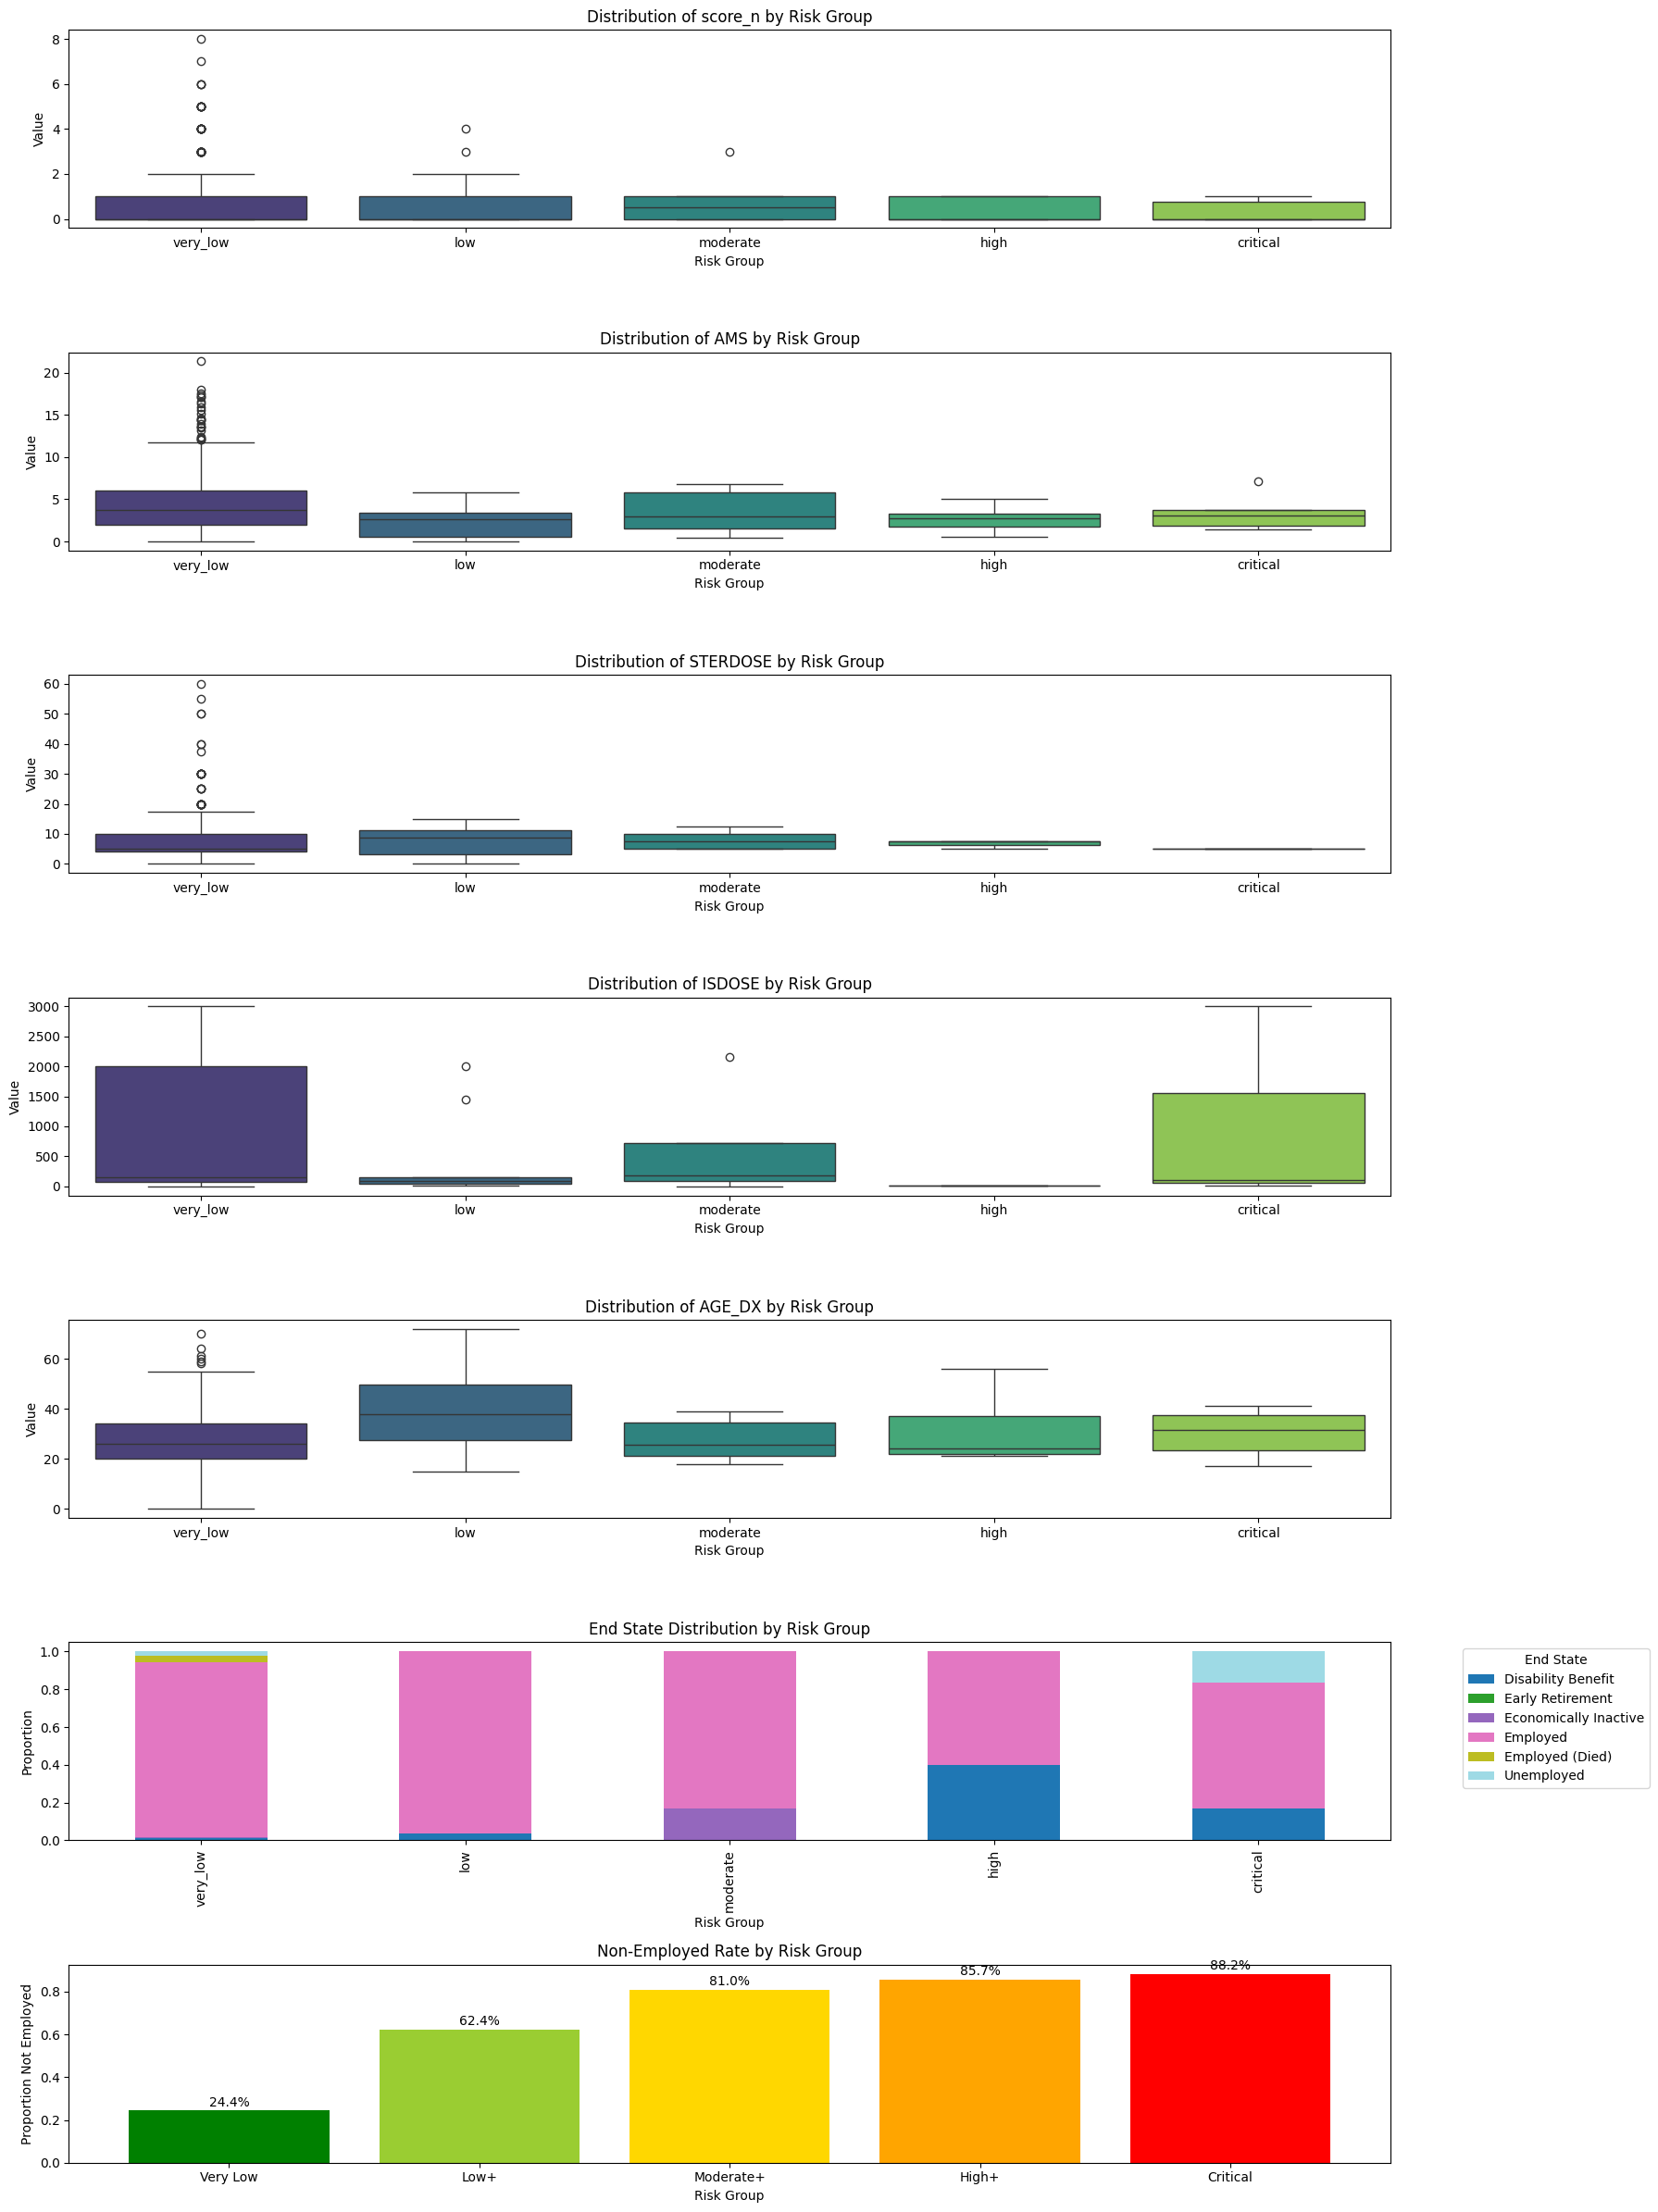

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

def generate_enhanced_risk_report(analyzer, risk_results, data, origdata, scaler):
    """
    Generate an enhanced risk report with unscaled clinical factors for each risk group,
    where each risk group includes all more severe groups (cumulative)
    
    Args:
        analyzer: EmploymentRiskAnalyzer instance
        risk_results: DataFrame with risk predictions
        data: Processed dataset with scaled values
        origdata: Original dataset with unscaled values
        scaler: MinMaxScaler instance used for scaling
        
    Returns:
        Dictionary containing comprehensive risk report with unscaled clinical statistics
    """
    # Define clinical factors to analyze and their scaling status
    CLINICAL_FACTORS = {
        'score_n': True,        # Needs unscaling
        'AMS': True,            # Needs unscaling  
        'STERDOSE': False,      # Already in original units
        'ISDOSE': False,       # Already in original units
        'AGE_DX': True,         # Needs unscaling
        'employment_duration': False  # Already in original units
    }
    
    # Get scaling ranges from the scaler
    feature_names = scaler.feature_names_in_
    scaling_ranges = {name: (scaler.data_min_[i], scaler.data_max_[i]) 
                     for i, name in enumerate(feature_names)}
    
    # Function to unscale a value
    def unscale_value(col_name, scaled_value):
        if col_name not in scaling_ranges:
            return scaled_value
        min_val, max_val = scaling_ranges[col_name]
        return scaled_value * (max_val - min_val) + min_val
    
    # Get latest record per patient in risk_results and original data
    latest_risk_results = risk_results.sort_values('ASSDT').drop_duplicates('PTNO', keep='last')
    latest_data = data.sort_values('ASSDT').drop_duplicates('PTNO', keep='last')
    latest_origdata = origdata.sort_values('ASSDT').drop_duplicates('PTNO', keep='last')
    
    # Merge all data
    merged_data = latest_risk_results.merge(
        latest_data, on=['PTNO', 'ASSDT'], suffixes=('', '_processed'), how='left'
    ).merge(
        latest_origdata, on=['PTNO', 'ASSDT'], suffixes=('', '_orig'), how='left'
    )
    
    # Categorize patients by their maximum risk level
    def categorize_risk(row):
        if row['enhanced_risk'] >= analyzer.risk_thresholds['critical']:
            return 'critical'
        elif row['enhanced_risk'] >= analyzer.risk_thresholds['high']:
            return 'high'
        elif row['enhanced_risk'] >= analyzer.risk_thresholds['moderate']:
            return 'moderate'
        elif row['enhanced_risk'] >= analyzer.risk_thresholds['low']:
            return 'low'
        else:
            return 'very_low'
    
    merged_data['max_risk_category'] = merged_data.apply(categorize_risk, axis=1)
    
    # Initialize report dictionary
    report = {
        'risk_category_distributions': {},
        'performance_metrics': {},
        'clinical_factor_analysis': {},
        'category_composition': {}
    }
    
    # Define risk groups in order of increasing severity
    risk_groups_ordered = ['very_low', 'low', 'moderate', 'high', 'critical']
    
    # Calculate statistics for each risk category (cumulative)
    for i, category in enumerate(risk_groups_ordered):
        # For very_low, we only want that exact group
        if category == 'very_low':
            category_data = merged_data[merged_data['max_risk_category'] == category]
            unique_count = len(category_data)
        else:
            # For other groups, include all more severe categories
            higher_categories = risk_groups_ordered[i:]
            category_data = merged_data[merged_data['max_risk_category'].isin(higher_categories)]
            
            # Calculate how many are unique to this category (not in more severe groups)
            if i < len(risk_groups_ordered) - 1:
                next_category = risk_groups_ordered[i+1]
                next_category_data = merged_data[merged_data['max_risk_category'].isin(risk_groups_ordered[i+1:])]
                unique_count = len(category_data) - len(next_category_data)
            else:
                unique_count = len(category_data)  # critical has no more severe groups
        
        if len(category_data) > 0:
            # Basic counts
            report['risk_category_distributions'][category] = {
                'n_patients': len(category_data),
                'unique_patients': unique_count,
                'end_state_distribution': category_data['end_state'].value_counts(normalize=True).to_dict(),
                'non_employed_rate': (category_data['end_state'] != "Employed").mean()
            }
            
            # Track category composition
            composition = {}
            for comp_category in risk_groups_ordered[i:]:
                comp_data = merged_data[merged_data['max_risk_category'] == comp_category]
                composition[comp_category] = len(comp_data)
            report['category_composition'][category] = composition
            
            # Clinical factor statistics
            clinical_stats = {}
            for factor, needs_unscaling in CLINICAL_FACTORS.items():
                if factor in category_data.columns:
                    # Get values - use original if available, otherwise unscale
                    if f"{factor}_orig" in category_data.columns:
                        values = category_data[f"{factor}_orig"]
                    elif needs_unscaling:
                        values = category_data[factor].apply(lambda x: unscale_value(factor, x))
                    else:
                        values = category_data[factor]
                    
                    # Handle numeric factors
                    if pd.api.types.is_numeric_dtype(values):
                        clinical_stats[factor] = {
                            'mean': values.mean(),
                            'median': values.median(),
                            'std': values.std(),
                            'q1': values.quantile(0.25),
                            'q3': values.quantile(0.75),
                            'min': values.min(),
                            'max': values.max()
                        }
                    # Handle categorical factors
                    else:
                        clinical_stats[factor] = {
                            'value_counts': values.value_counts(normalize=True).to_dict()
                        }
            
            report['clinical_factor_analysis'][category] = clinical_stats
    
    # Calculate performance metrics
    high_risk_patients = merged_data[
        merged_data['enhanced_risk'] >= analyzer.risk_thresholds['high']]
    
    all_non_employed = merged_data[
        merged_data['end_state'] != "Employed"]['PTNO'].nunique()
    true_positives = high_risk_patients[
        high_risk_patients['end_state'] != "Employed"]['PTNO'].nunique()
    false_negatives = all_non_employed - true_positives
    
    report['performance_metrics'] = {
        'total_patients': merged_data['PTNO'].nunique(),
        'high_risk_patients': len(high_risk_patients['PTNO'].unique()),
        'critical_risk_patients': len(merged_data[
            merged_data['enhanced_risk'] >= analyzer.risk_thresholds['critical']
        ]['PTNO'].unique()),
        'true_positives': true_positives,
        'false_positives': high_risk_patients[
            high_risk_patients['end_state'] == "Employed"]['PTNO'].nunique(),
        'false_negatives': false_negatives,
        'recall': true_positives / all_non_employed if all_non_employed > 0 else 0,
        'precision': (high_risk_patients['end_state'] != "Employed").mean(),
        'non_employed_rate_overall': (merged_data['end_state'] != "Employed").mean()
    }
    fig = create_risk_visualizations(merged_data, analyzer.risk_thresholds)
    
    return report, fig
    
def create_risk_visualizations(merged_data, risk_thresholds):
    """
    Create visualizations showing clinical scores and end state distributions by risk group
    
    Args:
        merged_data: DataFrame containing both risk predictions and original data
        risk_thresholds: Dictionary of risk thresholds from the analyzer
        
    Returns:
        Matplotlib figure containing the visualizations
    """
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(18, 24))
    plt.subplots_adjust(hspace=0.5)
    
    # 1. Individual Clinical Score Distributions by Risk Group
    clinical_scores = ['score_n', 'AMS', 'STERDOSE', 'ISDOSE', 'AGE_DX']
    for i, score in enumerate(clinical_scores, 1):
        ax = plt.subplot(len(clinical_scores)+2, 1, i)
        # Use original values if available, otherwise use processed column
        col_name = f"{score}_orig" if f"{score}_orig" in merged_data.columns else score
        
        sns.boxplot(
            x='max_risk_category', 
            y=col_name,
            data=merged_data,
            order=['very_low', 'low', 'moderate', 'high', 'critical'],
            palette='viridis',
            ax=ax
        )
        ax.set_title(f'Distribution of {score} by Risk Group')
        ax.set_xlabel('Risk Group')
        ax.set_ylabel('Value')
    
    # 2. End State Distribution by Risk Group
    ax = plt.subplot(len(clinical_scores)+2, 1, len(clinical_scores)+1)
    end_state_counts = merged_data.groupby(['max_risk_category', 'end_state']).size().unstack()
    end_state_counts = end_state_counts.div(end_state_counts.sum(axis=1), axis=0)
    end_state_counts = end_state_counts.reindex(['very_low', 'low', 'moderate', 'high', 'critical'])
    end_state_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=ax)
    ax.set_title('End State Distribution by Risk Group')
    ax.set_xlabel('Risk Group')
    ax.set_ylabel('Proportion')
    ax.legend(title='End State', bbox_to_anchor=(1.05, 1))
    
    # 3. Non-Employed Rate Across Risk Groups
    ax = plt.subplot(len(clinical_scores)+2, 1, len(clinical_scores)+2)
    non_employed_rates = []
    for cat in ['very_low', 'low', 'moderate', 'high', 'critical']:
        cat_data = merged_data[merged_data['max_risk_category'] == cat] if cat == 'very_low' else \
                 merged_data[merged_data['max_risk_category'].isin(['low', 'moderate', 'high', 'critical'][['very_low', 'low', 'moderate', 'high', 'critical'].index(cat)-1:])]
        non_employed_rates.append((cat_data['end_state'] != "Employed").mean())
    
    colors = ['green', 'yellowgreen', 'gold', 'orange', 'red']
    ax.bar(
        ['Very Low', 'Low+', 'Moderate+', 'High+', 'Critical'],
        non_employed_rates,
        color=colors
    )
    ax.set_title('Non-Employed Rate by Risk Group')
    ax.set_xlabel('Risk Group')
    ax.set_ylabel('Proportion Not Employed')
    for i, rate in enumerate(non_employed_rates):
        ax.text(i, rate+0.02, f"{rate:.1%}", ha='center')
    
    return fig

def print_enhanced_report(report):
    """Print the enhanced report in a readable format with clinical factors"""
    print("\n=== ENHANCED EMPLOYMENT RISK REPORT (CUMULATIVE RISK GROUPS) ===")
    print(f"Total patients analyzed: {report['performance_metrics']['total_patients']}")
    print(f"Overall non-employed rate: {report['performance_metrics']['non_employed_rate_overall']:.1%}")
    
    # Print risk category distributions
    print("\nCUMULATIVE RISK CATEGORIES:")
    for category, stats in report['risk_category_distributions'].items():
        print(f"\n{category.upper()} RISK+ (n={stats['n_patients']}, unique={stats['unique_patients']}):")
        
        # Print composition
        print(f"- Composition:")
        for comp_cat, count in report['category_composition'][category].items():
            print(f"  - {comp_cat}: {count} patients")
        
        print(f"- Non-employed rate: {stats['non_employed_rate']:.1%}")
        print("- End state distribution:")
        for state, proportion in stats['end_state_distribution'].items():
            print(f"  - {state}: {proportion:.1%}")
        
        # Print clinical factors for this category
        if category in report['clinical_factor_analysis']:
            print("\n  Clinical Factors:")
            for factor, factor_stats in report['clinical_factor_analysis'][category].items():
                print(f"  - {factor}:")
                if 'mean' in factor_stats:  # Numeric variable
                    print(f"    - Mean: {factor_stats['mean']:.2f}")
                    print(f"    - Median: {factor_stats['median']:.2f}")
                    print(f"    - Std Dev: {factor_stats['std']:.2f}")
                    print(f"    - IQR: {factor_stats['q1']:.2f} - {factor_stats['q3']:.2f}")
                    print(f"    - Range: {factor_stats['min']:.2f} - {factor_stats['max']:.2f}")
                else:  # Categorical variable
                    print("    - Distribution:")
                    for value, proportion in factor_stats['value_counts'].items():
                        print(f"      - {value}: {proportion:.1%}")
    
    # Print performance metrics
    print("\nPerformance Metrics:")
    print(f"- Patients flagged as high+ risk: {report['performance_metrics']['high_risk_patients']}")
    print(f"- Patients with critical risk: {report['performance_metrics']['critical_risk_patients']}")
    print(f"- True positives: {report['performance_metrics']['true_positives']}")
    print(f"- False positives: {report['performance_metrics']['false_positives']}")
    print(f"- False negatives: {report['performance_metrics']['false_negatives']}")
    print(f"- Precision: {report['performance_metrics']['precision']:.1%}")
    print(f"- Recall: {report['performance_metrics']['recall']:.1%}")

# Example usage in the main block:
if __name__ == "__main__":
    if risk_results is not None:
        # Generate enhanced report with visualizations
        enhanced_report, visualizations = generate_enhanced_risk_report(
            analyzer, risk_results, data, origdata, scaler)
        
        # Print the report
        print_enhanced_report(enhanced_report)
        
        # Show visualizations
        plt.tight_layout()
        plt.show()

In [9]:
origdata =  pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)


Displaying trajectories for 65 patients flagged while employed...
Close each figure to see the next one.

Displaying patient 140 (1/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


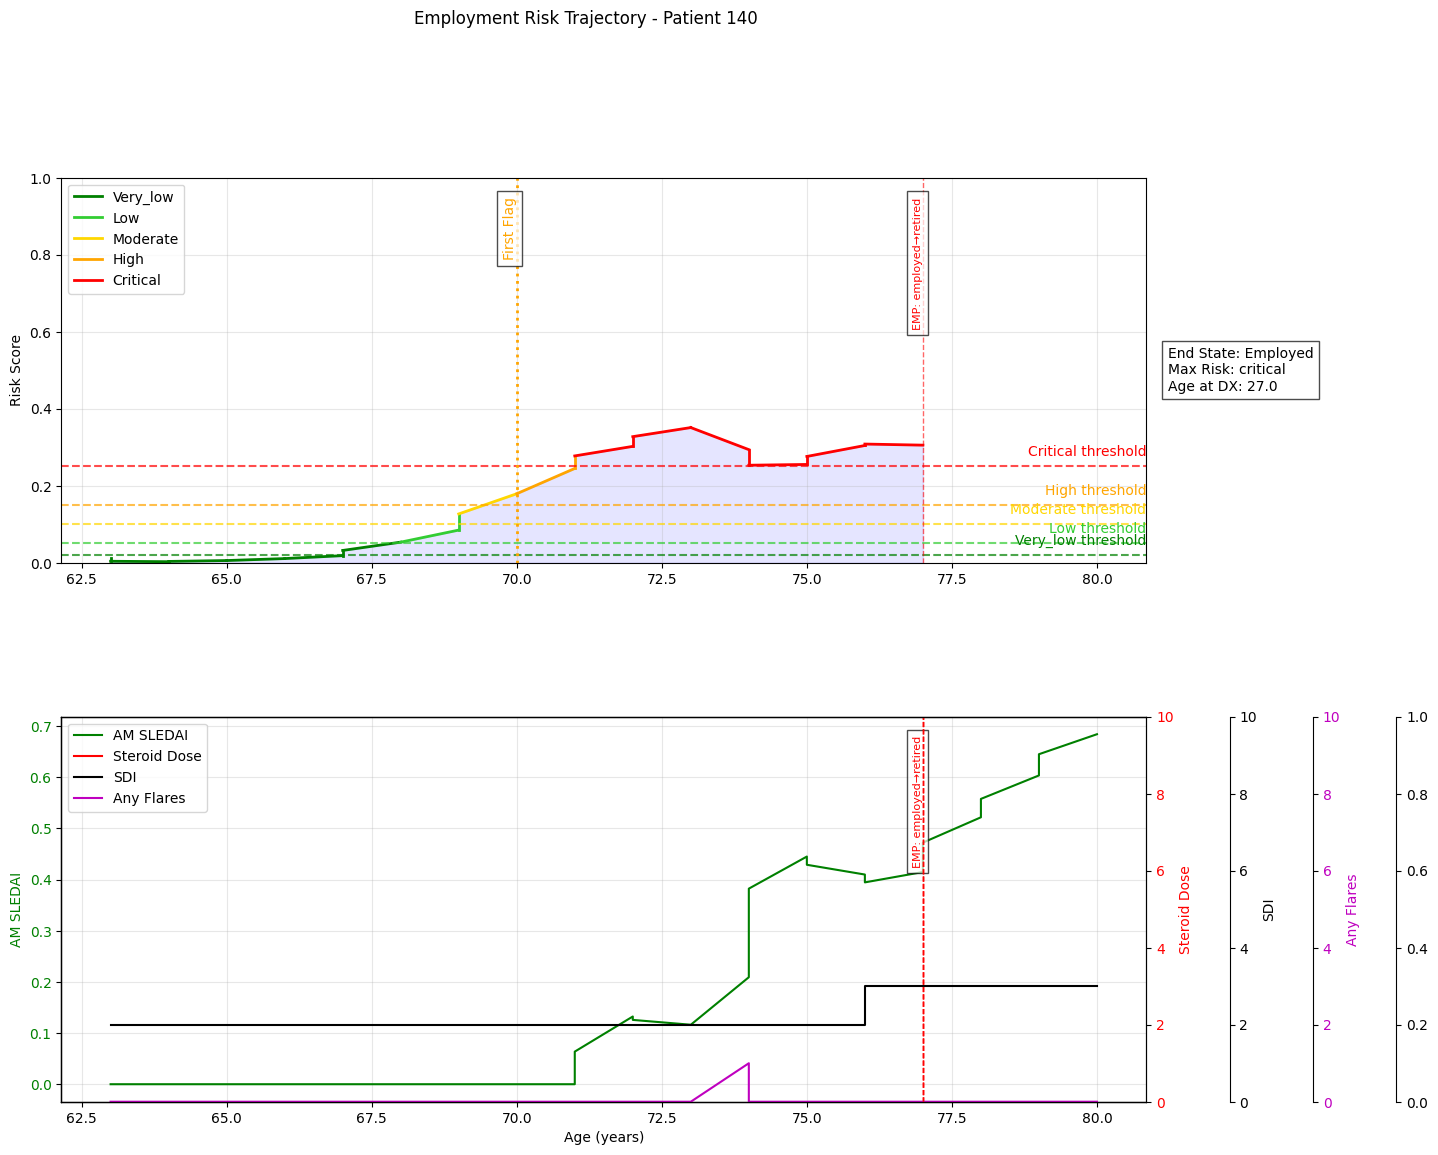


Displaying patient 175 (2/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


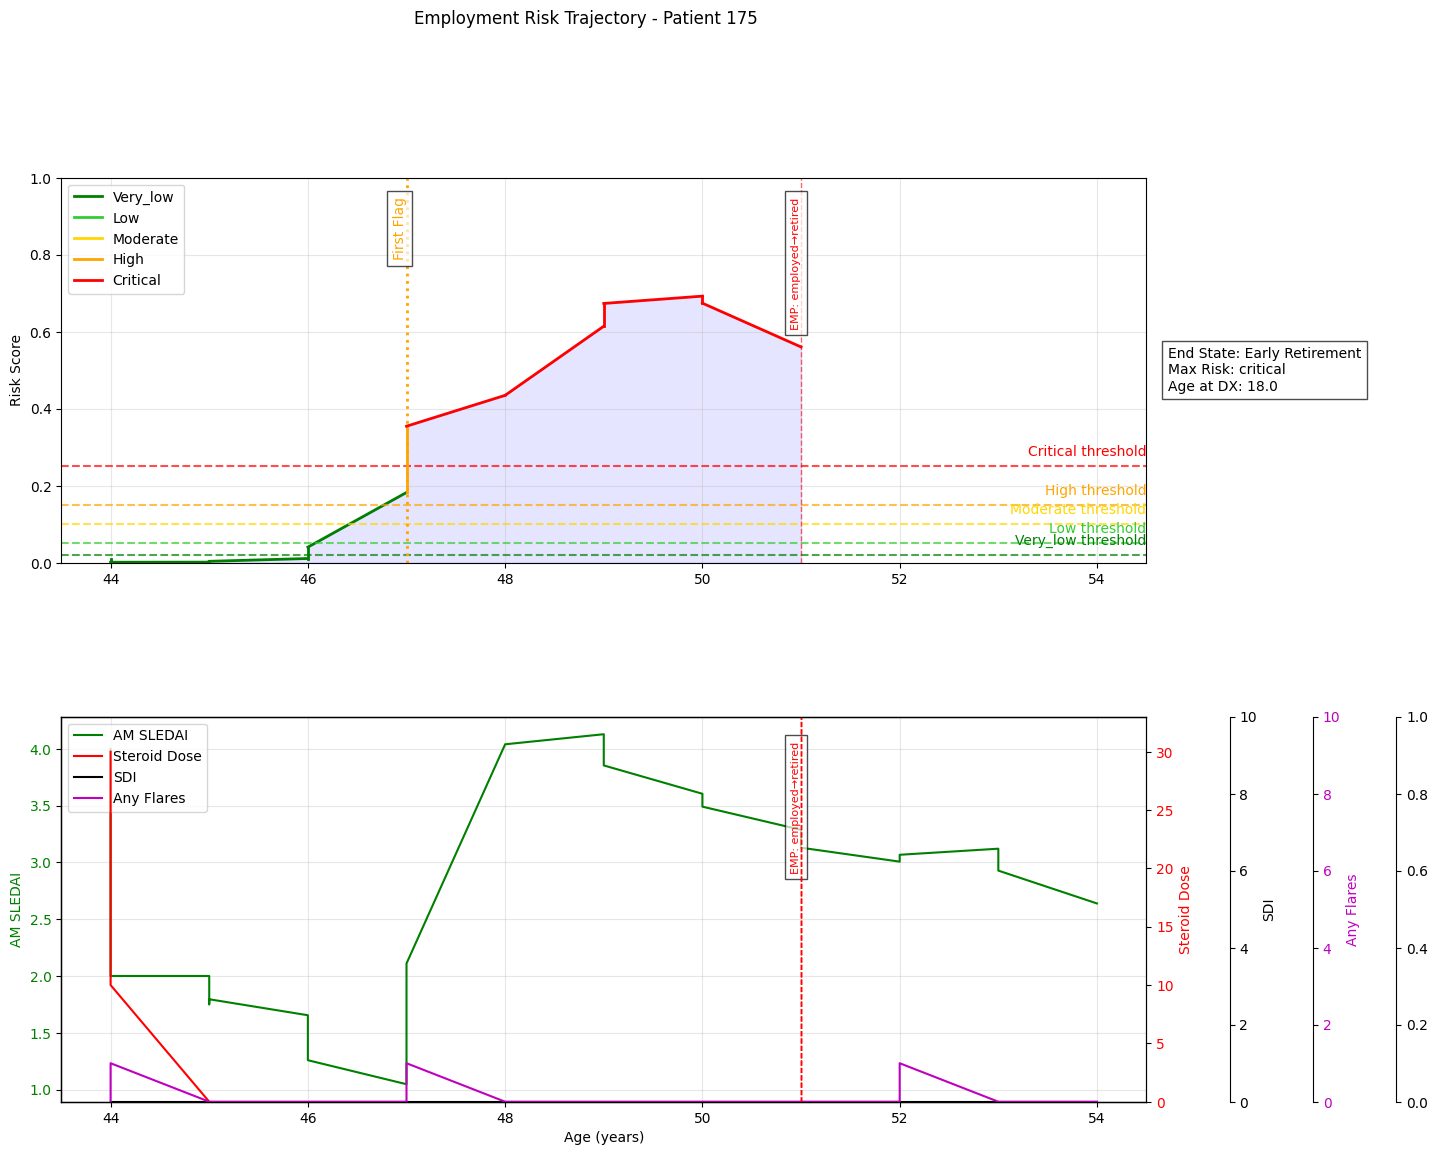


Displaying patient 257 (3/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


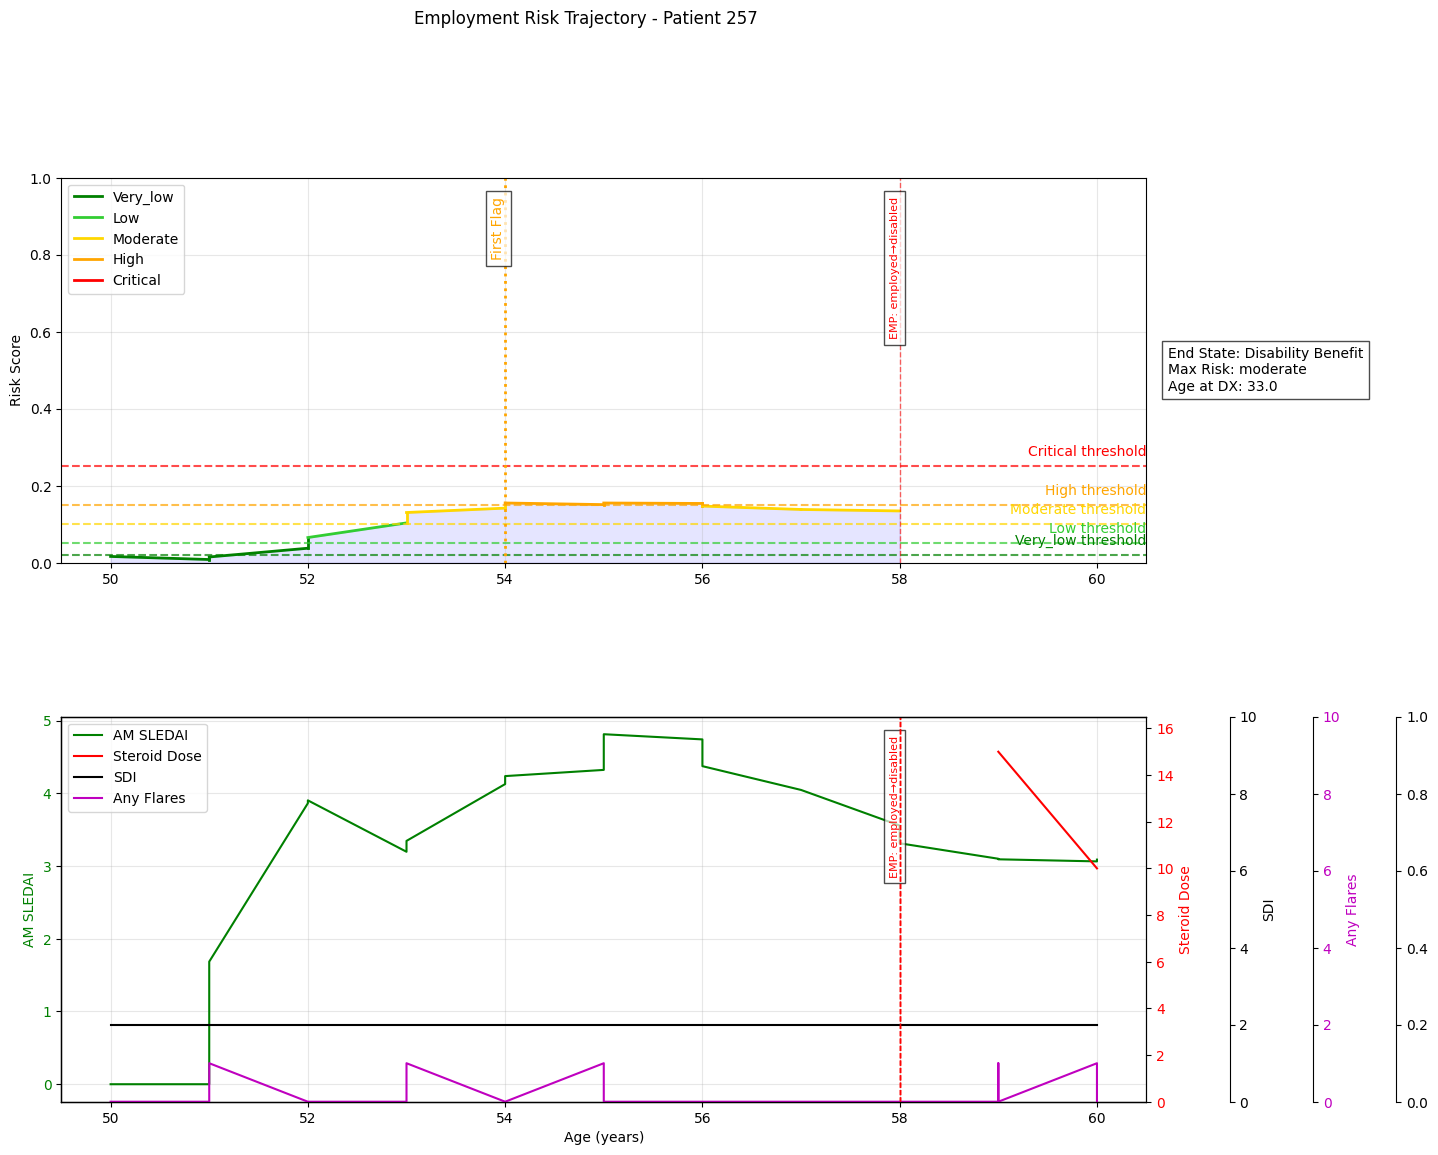


Displaying patient 259 (4/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


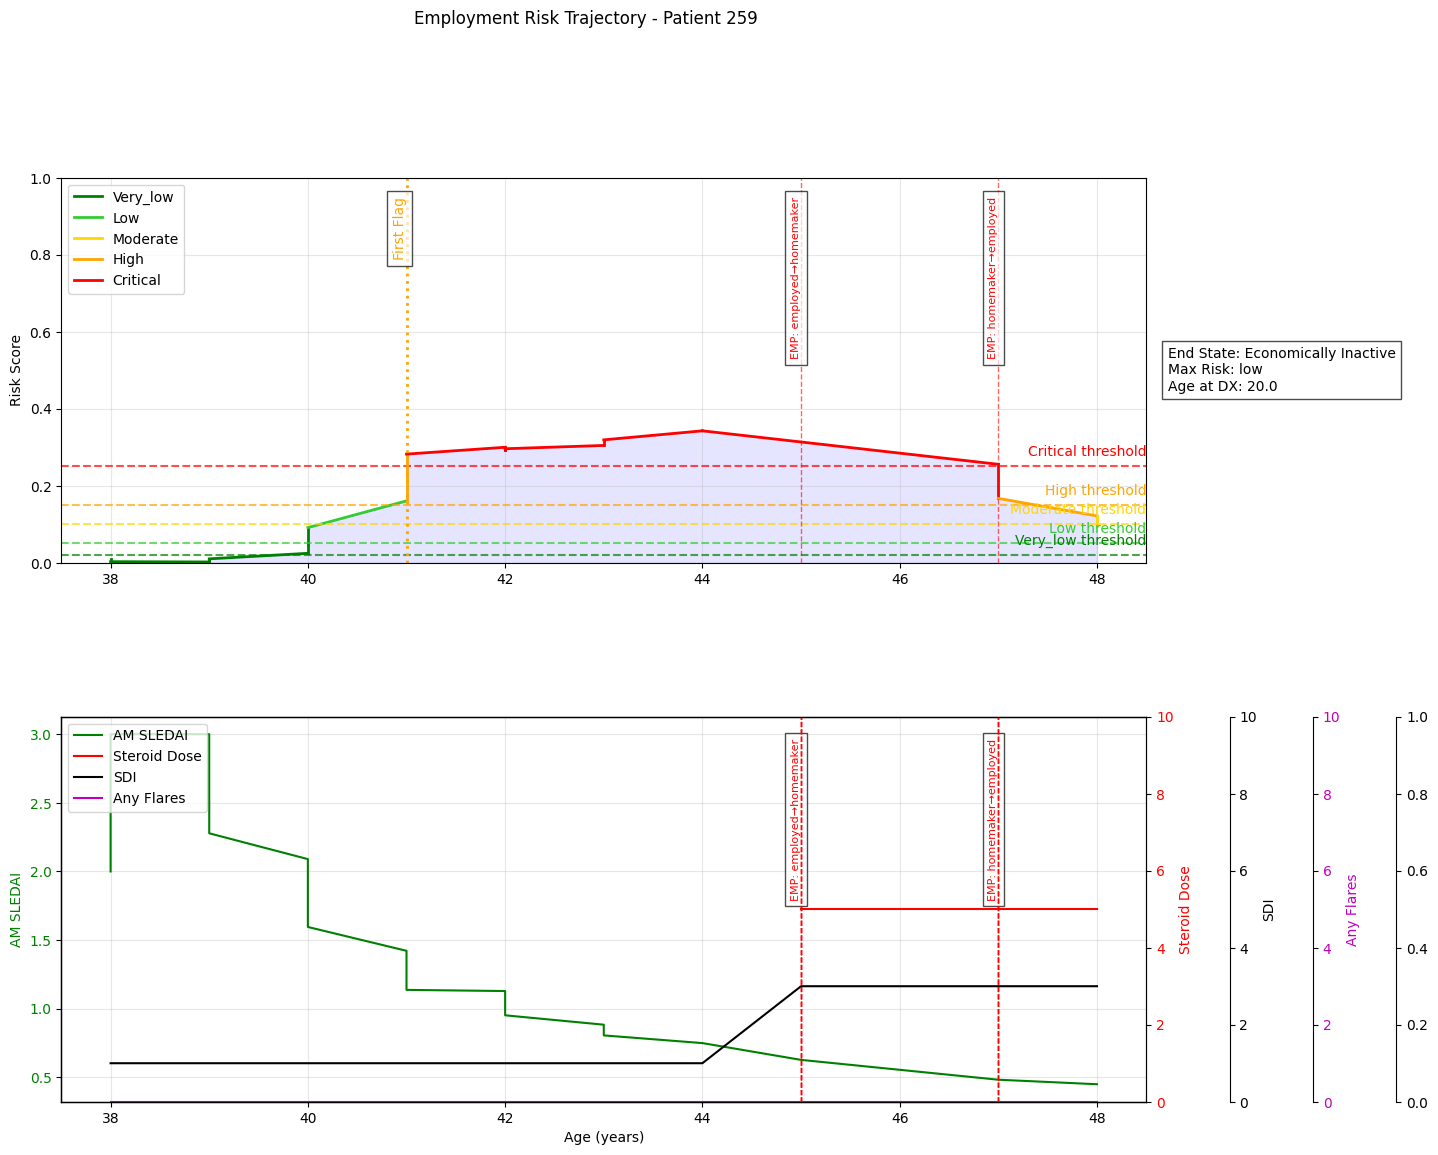


Displaying patient 260 (5/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


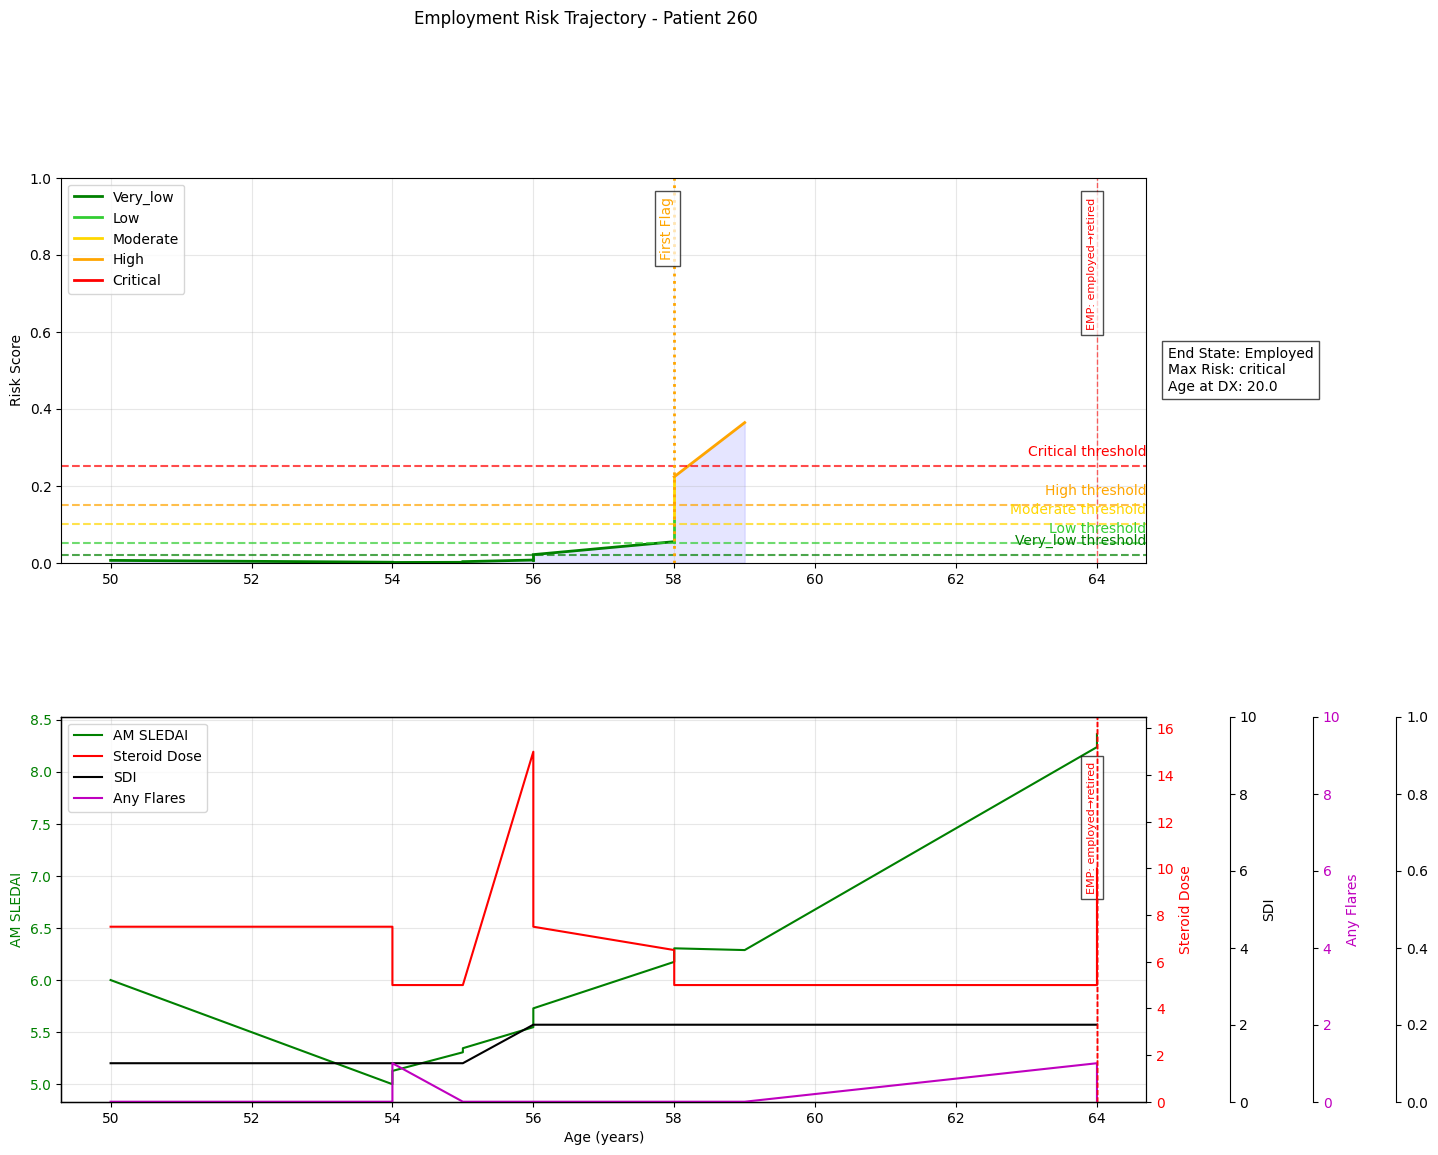


Displaying patient 289 (6/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


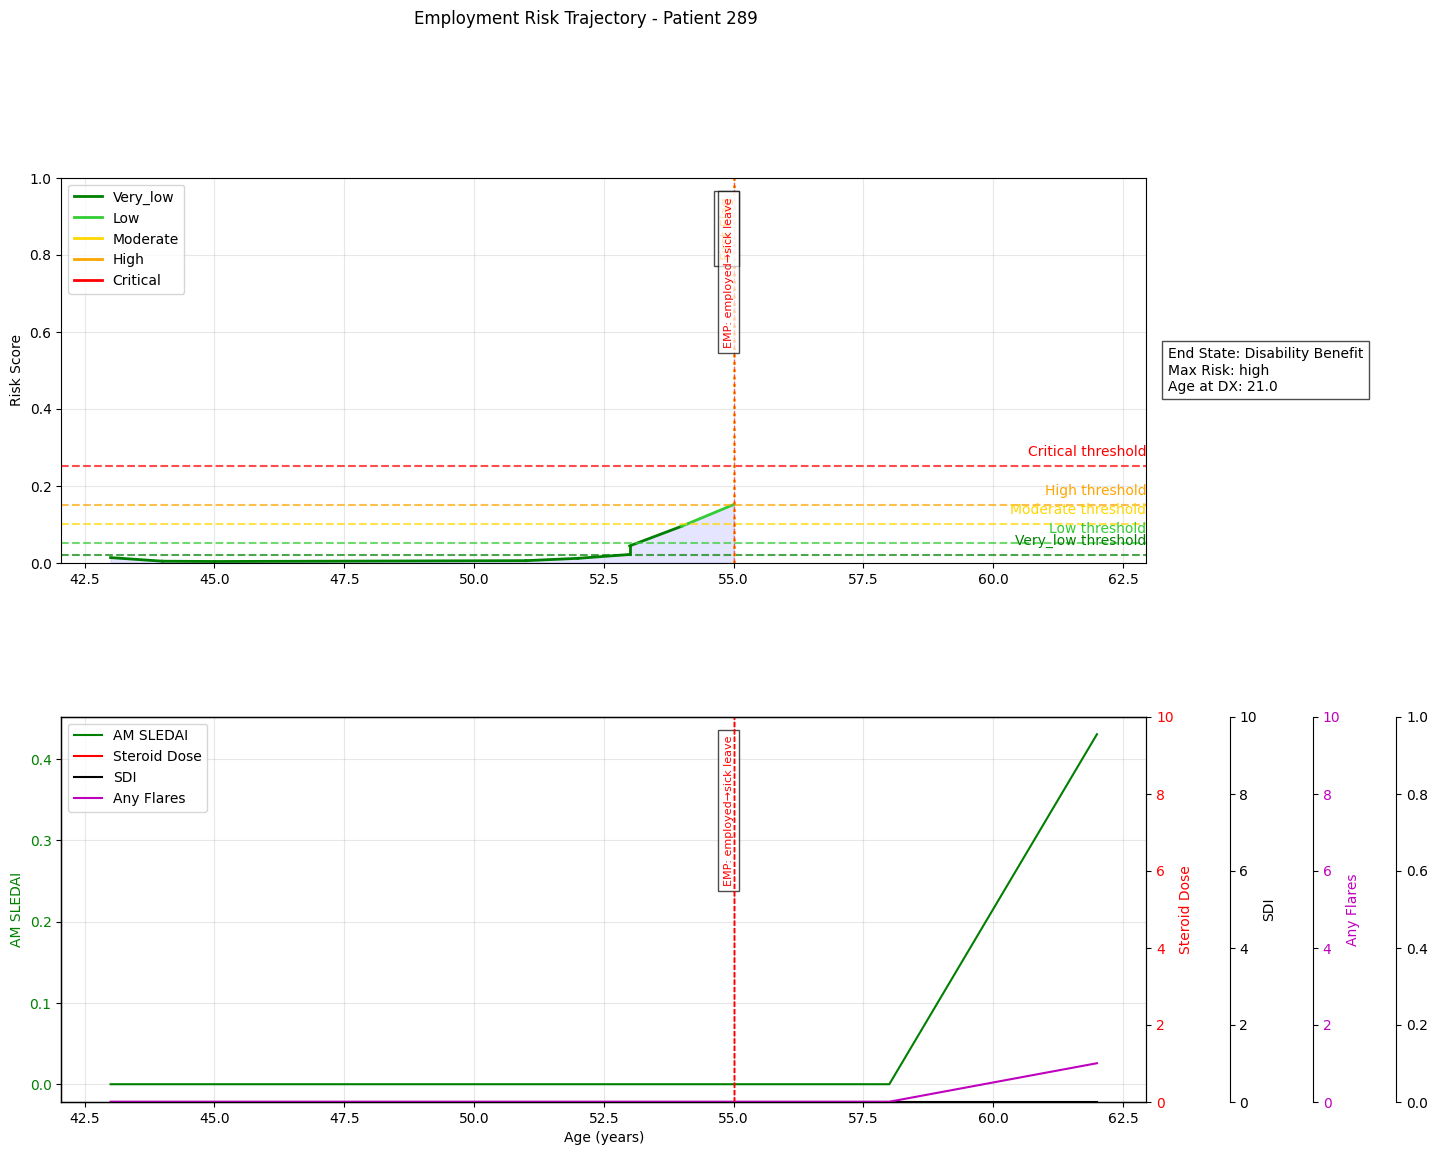


Displaying patient 293 (7/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


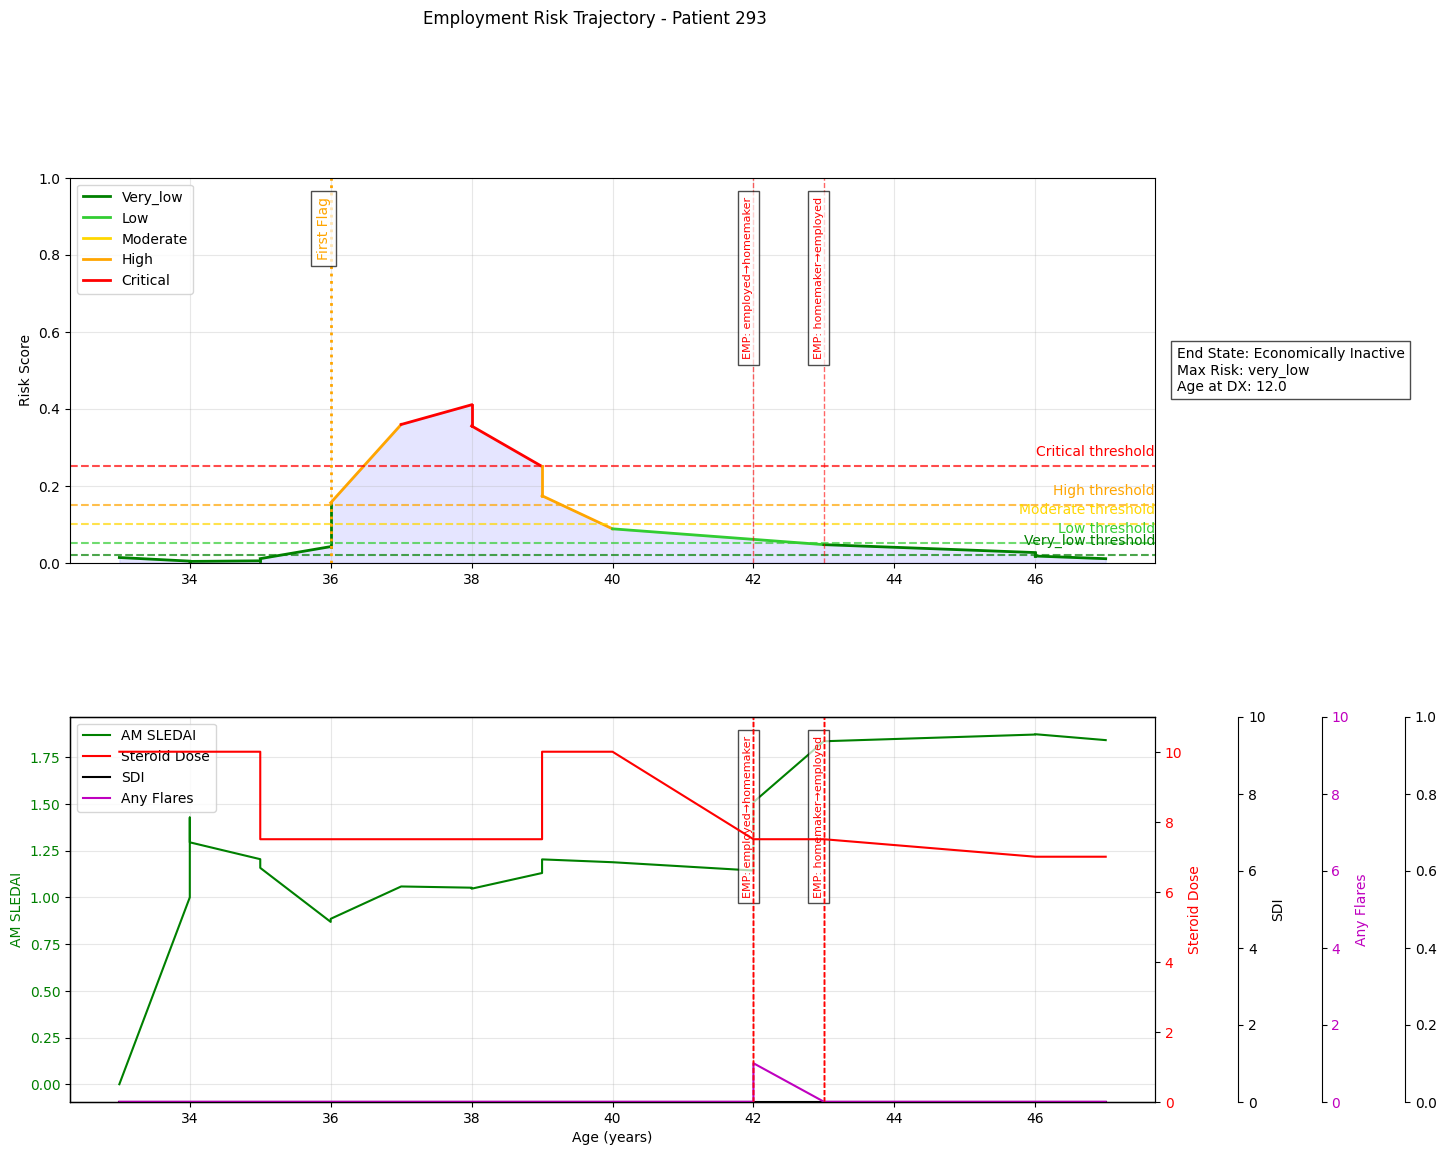


Displaying patient 320 (8/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


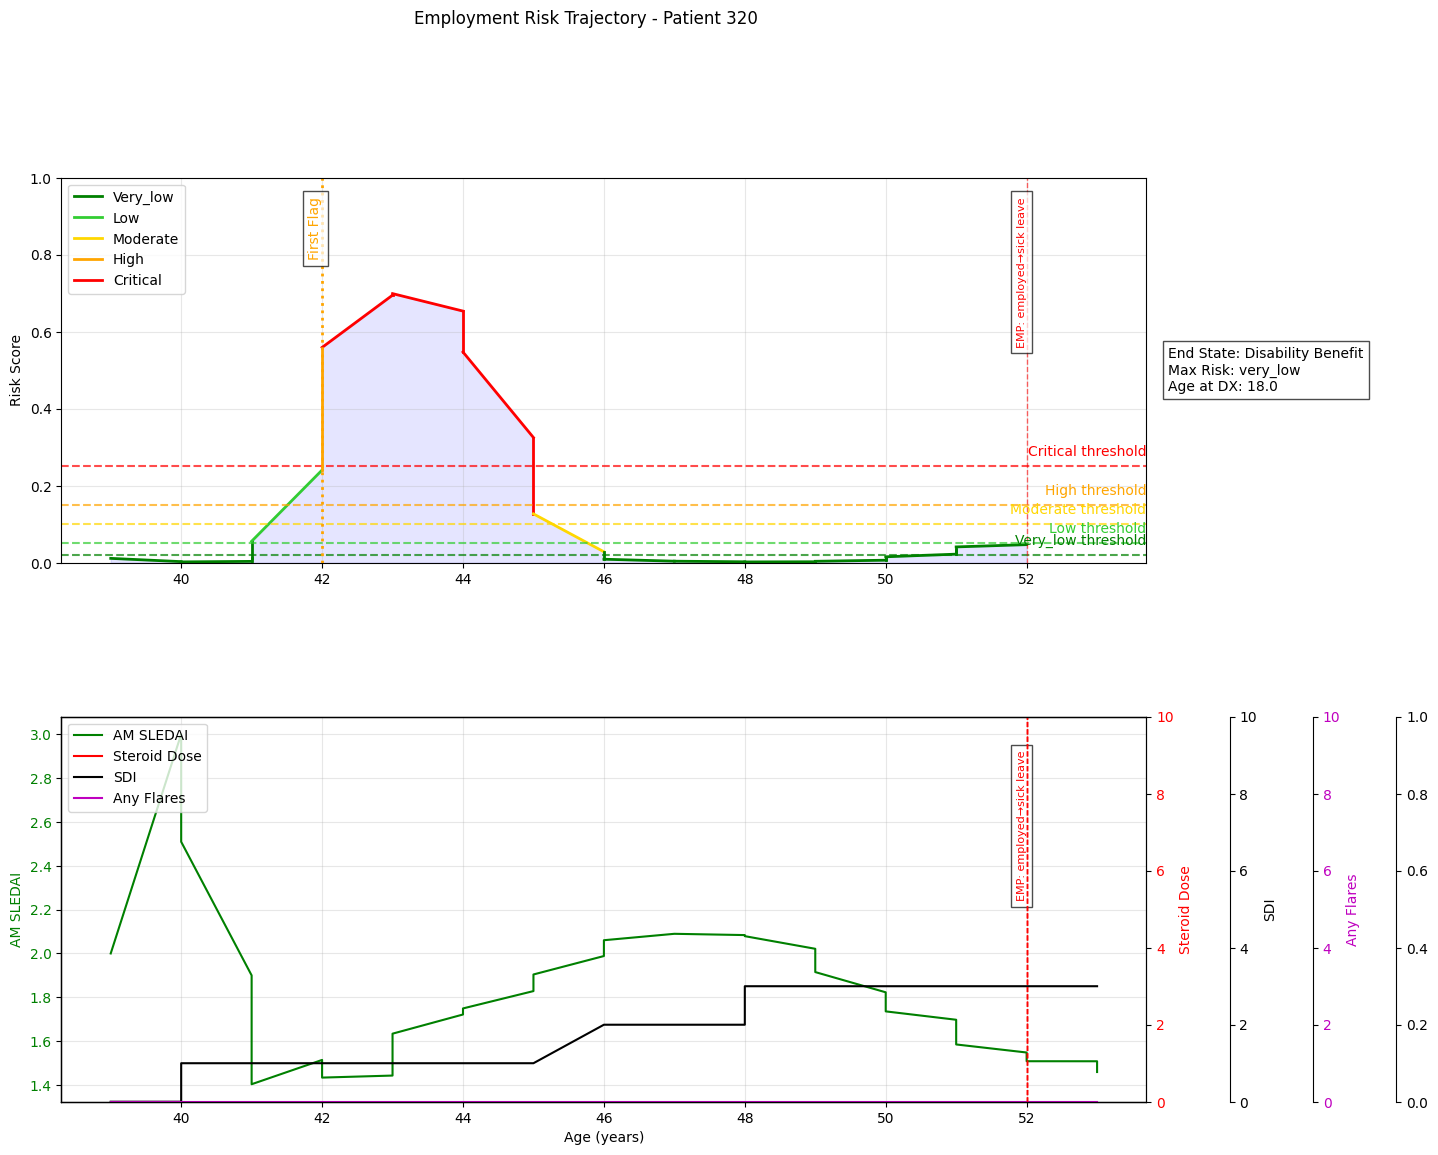


Displaying patient 353 (9/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


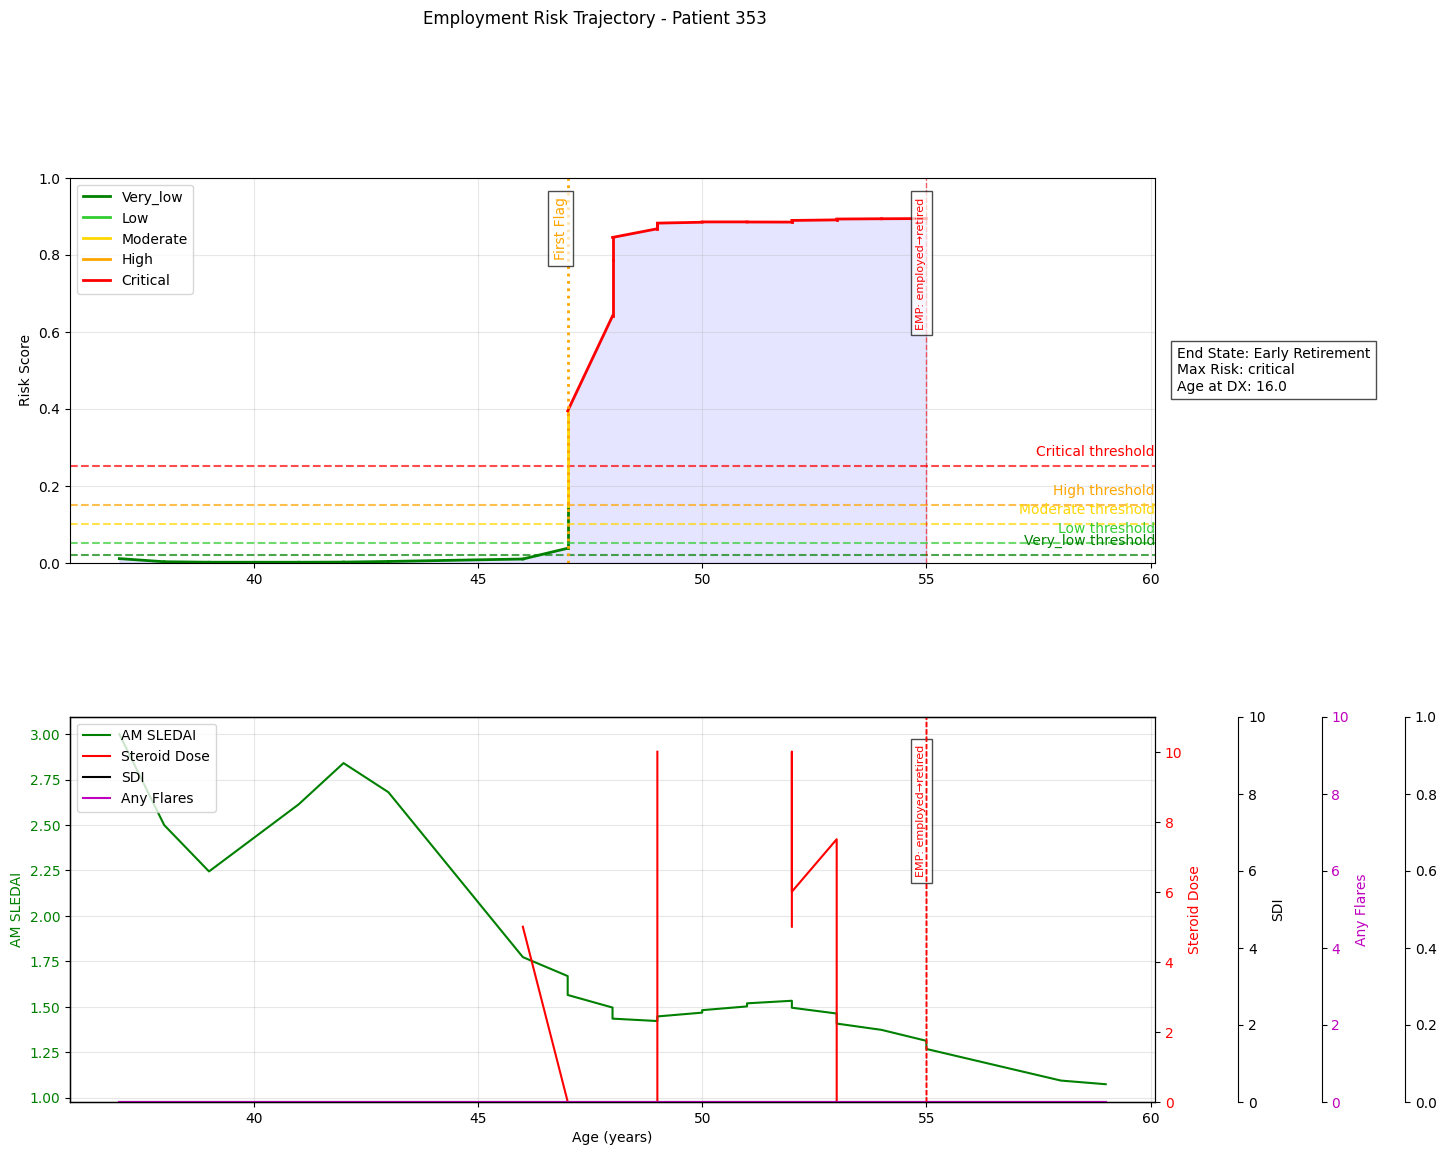


Displaying patient 367 (10/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


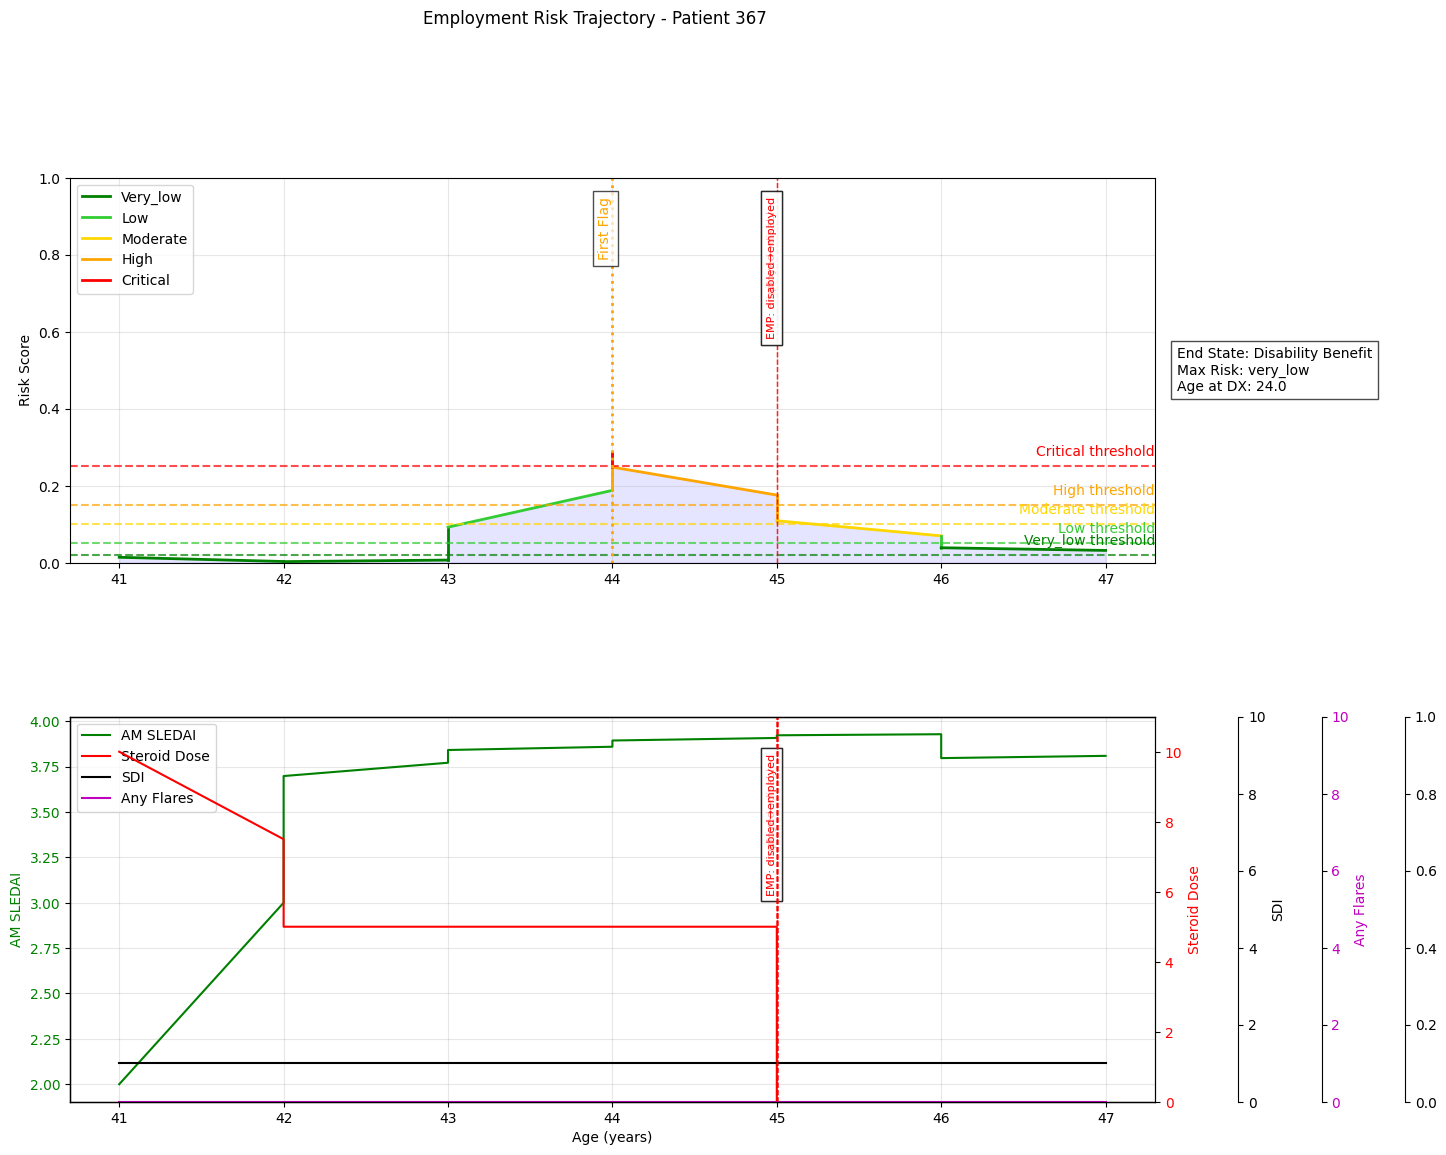


Displaying patient 380 (11/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


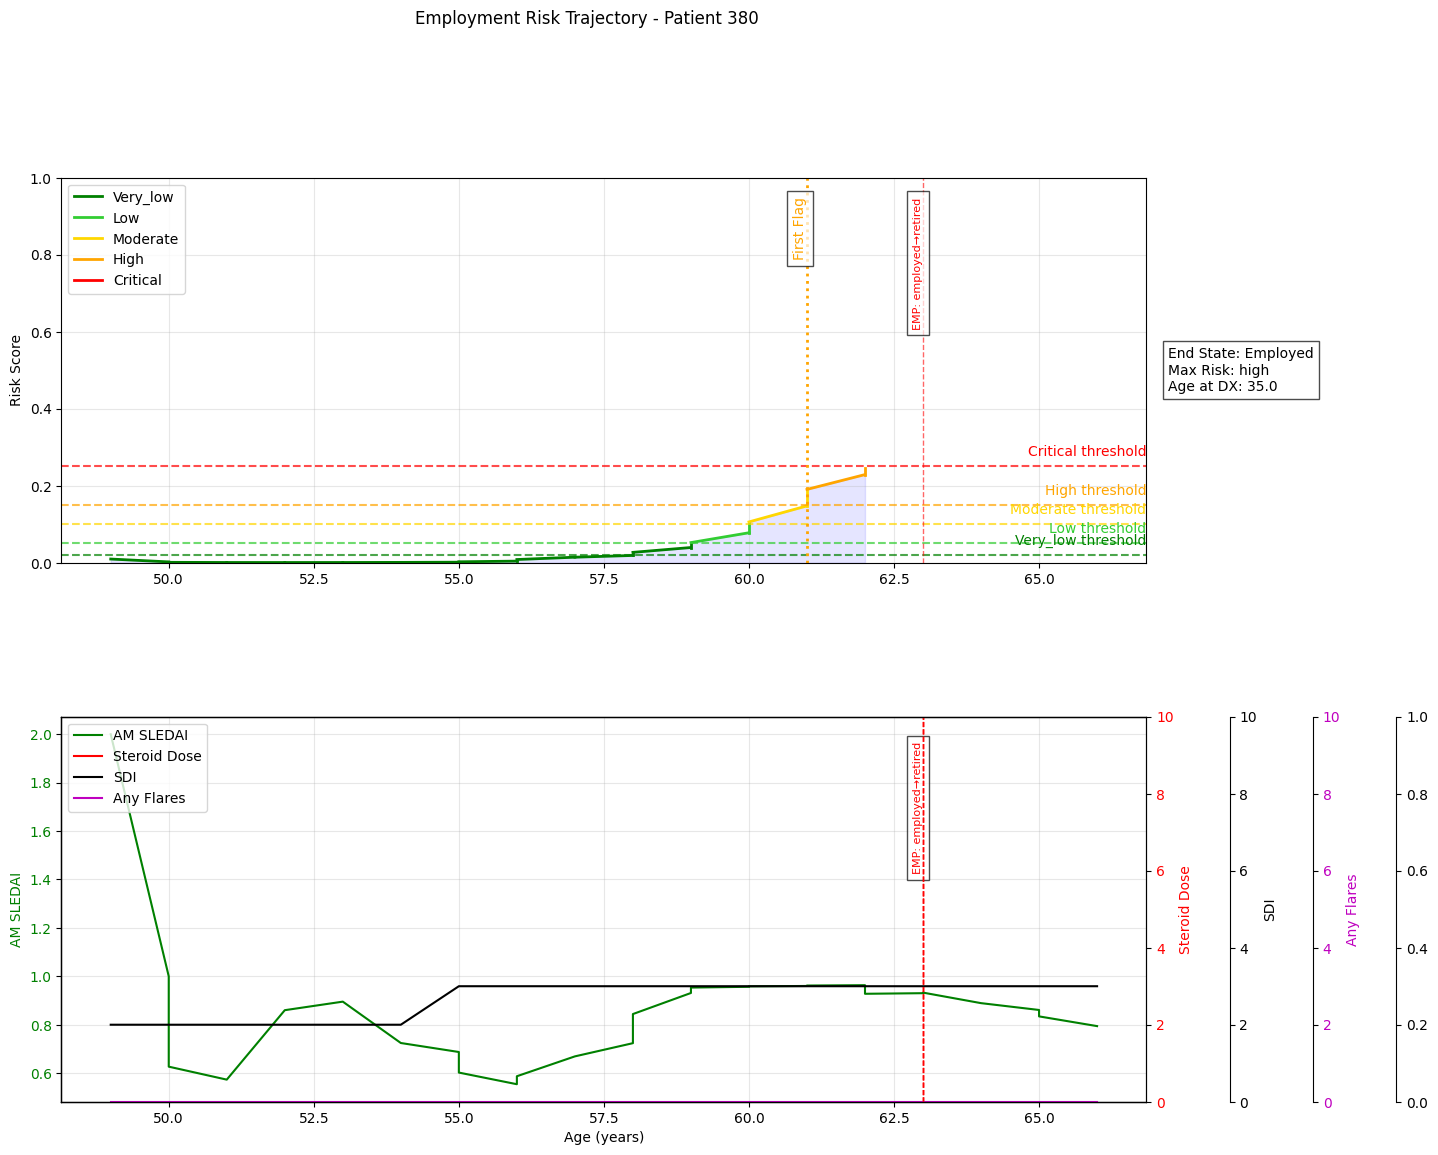


Displaying patient 404 (12/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


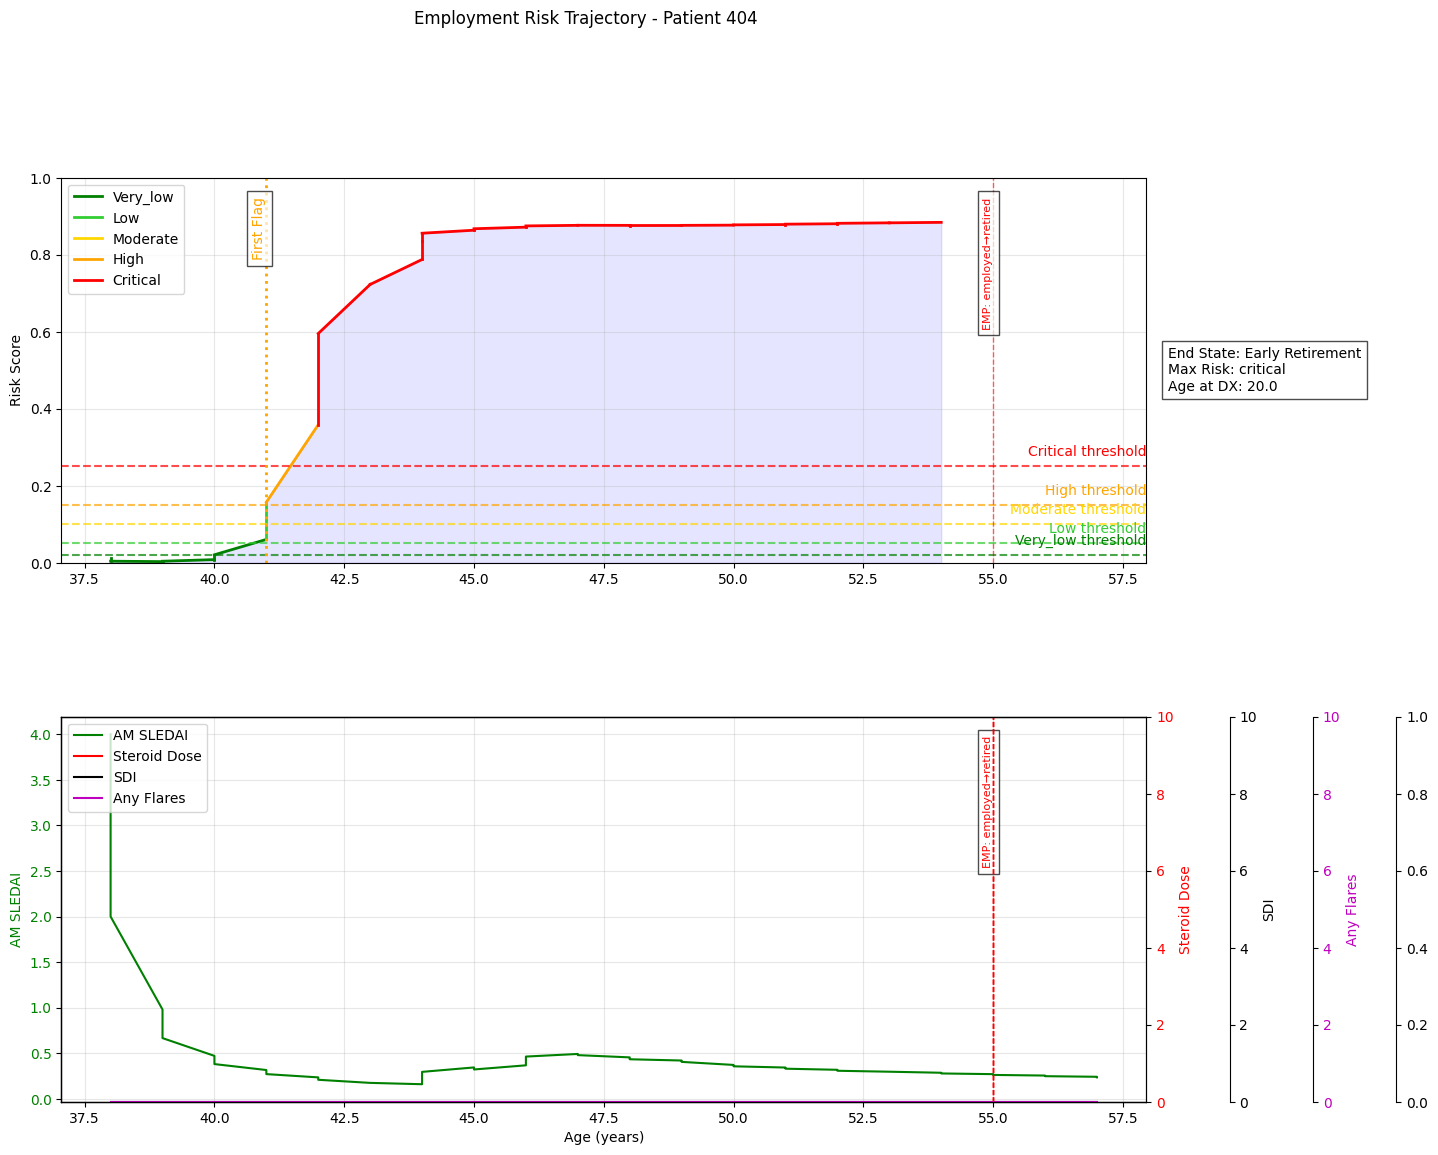


Displaying patient 461 (13/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


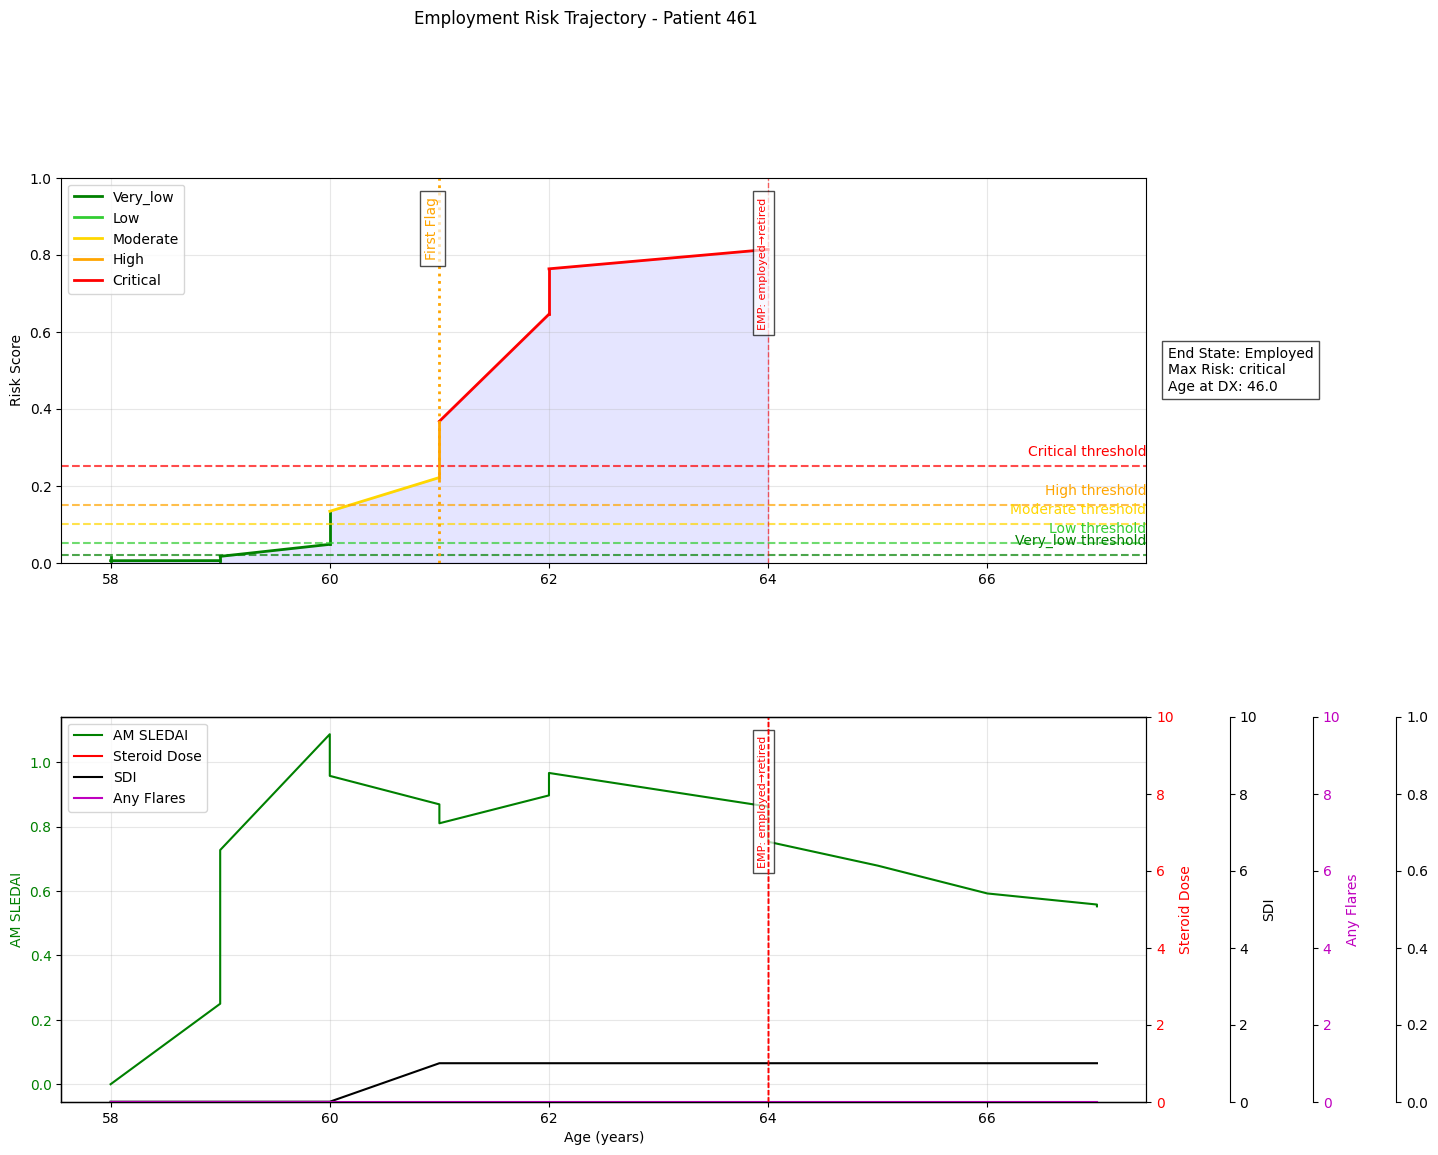


Displaying patient 507 (14/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


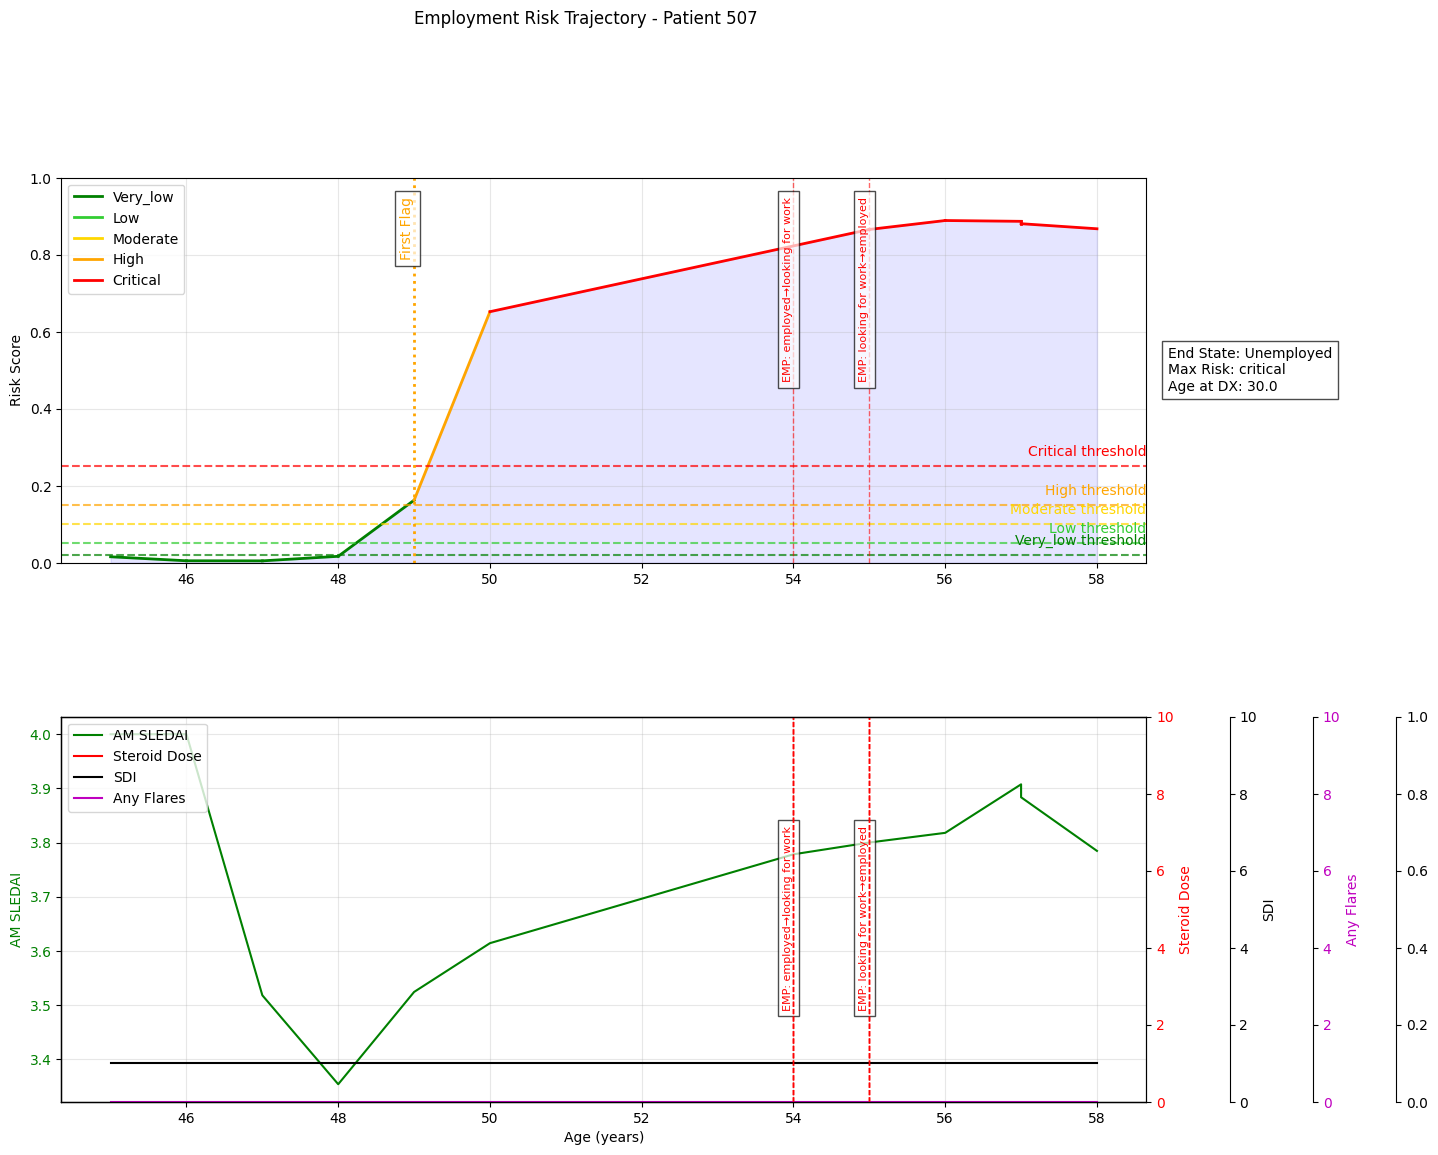


Displaying patient 534 (15/65)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_70199/1424866514.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


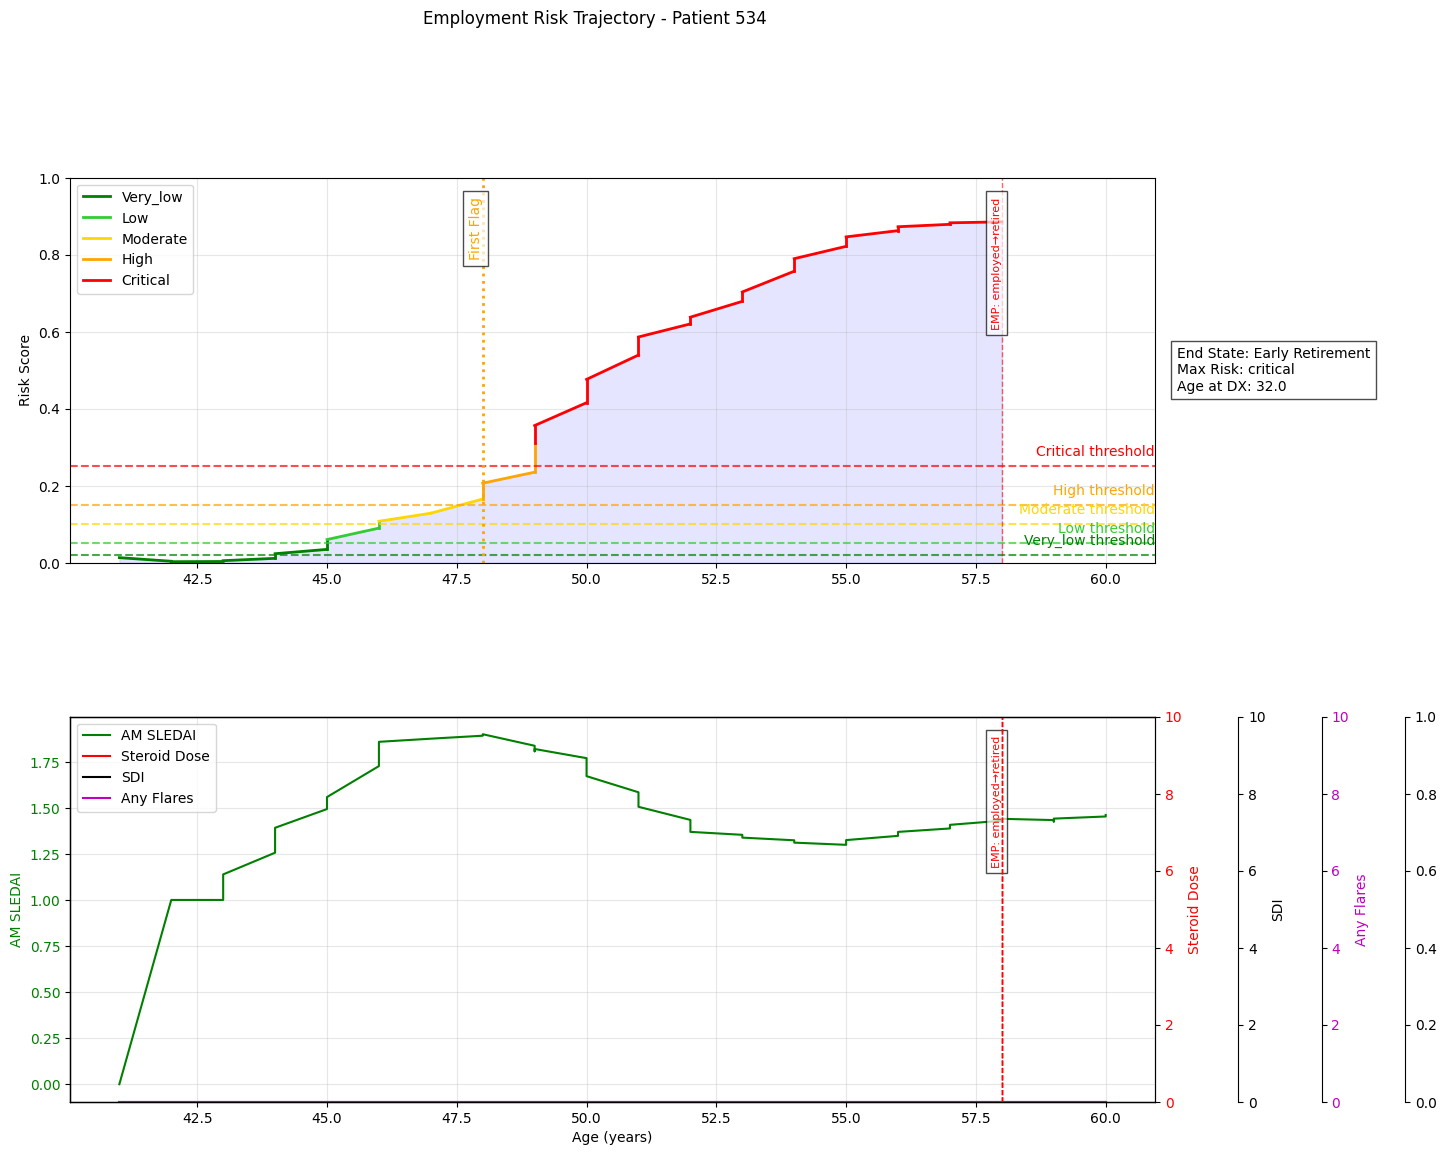


All patient trajectories displayed.


In [24]:
def plot_risk_trajectory(ptno, risk_df, clinical_data, origdata, analyzer=None, risk_thresholds=None):
    """
    Generate and display a comprehensive risk trajectory plot for a single patient
    with age on x-axis, markers for employment status changes, and clinical predictors
    combined in one plot with separate y-axes. Incorporates unscaled variables and risk groups.
    
    Parameters:
    - ptno: Patient ID
    - risk_df: DataFrame containing risk data with columns: 'ASSDT', 'enhanced_risk'
    - clinical_data: DataFrame containing clinical data with columns: 'ASSDT', 'age_at_record', 'EMP', and optionally 'AMS', 'STERDOSE', 'score_n'
    - origdata: DataFrame containing original unscaled data
    - analyzer: EmploymentRiskAnalyzer instance (optional)
    - risk_thresholds: Dictionary of risk thresholds (default is analyzer's thresholds or {'low': 0.3, 'moderate': 0.5, 'high': 0.7, 'critical': 0.9})
    """
    # Use analyzer's thresholds if available, otherwise default
    if risk_thresholds is None:
        if analyzer is not None:
            risk_thresholds = analyzer.risk_thresholds
        else:
            risk_thresholds = {'low': 0.3, 'moderate': 0.5, 'high': 0.7, 'critical': 0.9}
    
    if len(risk_df) == 0:
        print(f"No data available for patient {ptno}")
        return
        
    try:
        # Create figure with subplots - risk plot on top, clinical markers combined below
        fig = plt.figure(figsize=(14, 12))
        gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.4)
        ax1 = fig.add_subplot(gs[0])  # Risk plot on top
        ax2 = fig.add_subplot(gs[1])  # Combined clinical plot on bottom
        fig.suptitle(f'Employment Risk Trajectory - Patient {ptno}', y=1.02)
        
        # Get original unscaled data for this patient
        pt_origdata = origdata[origdata['PTNO'] == ptno].sort_values('ASSDT')
        
        # Replace scaled columns with original values where available
        for col in ['age_at_record', 'score_n', 'any_flare', 'AMS', 'STERDOSE', 'ISDOSE', 'AGE_DX']:
            if col in pt_origdata.columns:
                clinical_data[col] = pt_origdata[col].values
        
        # Verify required columns exist
        if 'age_at_record' not in clinical_data.columns:
            print(f"Age data not available for patient {ptno}")
            return
        
        # Get end_state if available
        end_state = clinical_data['end_state'].iloc[-1] if 'end_state' in clinical_data.columns else 'Unknown'
        
        # Get age at diagnosis if available (static value)
        age_dx = clinical_data['AGE_DX'].iloc[0] if 'AGE_DX' in clinical_data.columns else None
        
        # --- Data Preparation ---
        # Sort by date and calculate age
        clinical_data = clinical_data.sort_values('ASSDT').reset_index(drop=True)
        risk_df = risk_df.merge(clinical_data[['ASSDT', 'age_at_record']], 
                              on='ASSDT', how='left')
        
        # Calculate shared x-axis limits (age range)
        all_ages = pd.concat([risk_df['age_at_record'], clinical_data['age_at_record']])
        x_min = all_ages.min()
        x_max = all_ages.max()
        # Add 5% padding on each side
        x_padding = (x_max - x_min) * 0.05
        x_min = max(0, x_min - x_padding)  # Don't go below 0 for age
        x_max = x_max + x_padding
        
        # Add risk category to the data
        def categorize_risk(risk_score):
            if risk_score >= risk_thresholds.get('critical', 0.9):
                return 'critical'
            elif risk_score >= risk_thresholds.get('high', 0.7):
                return 'high'
            elif risk_score >= risk_thresholds.get('moderate', 0.5):
                return 'moderate'
            elif risk_score >= risk_thresholds.get('low', 0.3):
                return 'low'
            else:
                return 'very_low'
        
        risk_df['risk_category'] = risk_df['enhanced_risk'].apply(categorize_risk)
        
        # --- Risk Plot ---
        # Create a color map for risk categories
        risk_colors = {
            'very_low': 'green',
            'low': 'limegreen',
            'moderate': 'gold',
            'high': 'orange',
            'critical': 'red'
        }
        
        # Plot risk trajectory with category-based coloring
        for i in range(len(risk_df)-1):
            x = risk_df['age_at_record'].iloc[i:i+2]
            y = risk_df['enhanced_risk'].iloc[i:i+2]
            cat = risk_df['risk_category'].iloc[i]
            ax1.plot(x, y, color=risk_colors[cat], linewidth=2)
        
        ax1.fill_between(risk_df['age_at_record'], risk_df['enhanced_risk'], 
                        color='blue', alpha=0.1)
        
        # Add threshold lines with labels
        for name, threshold in risk_thresholds.items():
            color = risk_colors.get(name, 'gray')
            ax1.axhline(y=threshold, color=color, linestyle='--', alpha=0.7)
            ax1.text(x_max, threshold+0.02, 
                    f'{name.capitalize()} threshold', 
                    color=color, ha='right', va='bottom')
        
        # Mark first high-risk flag
        high_risk_flags = risk_df[risk_df['enhanced_risk'] >= risk_thresholds.get('high', 0.7)]
        if not high_risk_flags.empty:
            first_flag_age = high_risk_flags.iloc[0]['age_at_record']
            ax1.axvline(x=first_flag_age, color='orange', linestyle=':', 
                       linewidth=2, label='First High-Risk Flag')
            ax1.text(x=first_flag_age, y=0.95, s='First Flag', 
                    rotation=90, va='top', ha='right', color='orange',
                    bbox=dict(facecolor='white', alpha=0.7))
        
        ax1.set_ylabel('Risk Score')
        ax1.set_ylim(0, 1)
        ax1.set_xlim(x_min, x_max)  # Set x-axis limits
        ax1.grid(True, alpha=0.3)
        
        # Add end_state, max risk category, and age at diagnosis in the info box
        max_risk = risk_df['risk_category'].iloc[-1]
        info_text = f'End State: {end_state}\nMax Risk: {max_risk}'
        if age_dx is not None:
            info_text += f'\nAge at DX: {age_dx:.1f}'
            
        ax1.text(1.02, 0.5, info_text, 
                transform=ax1.transAxes, va='center', ha='left', 
                bbox=dict(facecolor='white', alpha=0.7))
        
        # Create legend for risk categories
        legend_elements = [plt.Line2D([0], [0], color=color, lw=2, label=cat.capitalize())
                          for cat, color in risk_colors.items()]
        ax1.legend(handles=legend_elements, loc='upper left')
        
        # --- Combined Clinical Markers Plot ---
        # Create additional y-axes for each clinical predictor
        ax_ster = ax2.twinx() if 'STERDOSE' in clinical_data.columns else None
        ax_sdi = ax2.twinx() if 'score_n' in clinical_data.columns else None
        ax_total_flares = ax2.twinx() if 'total_flares' in clinical_data.columns else None
        ax_ams = ax2.twinx() if 'AMS' in clinical_data.columns else None

        # Offset the spines for the additional axes
        offset = 0
        for ax in [ax_ster, ax_sdi, ax_total_flares, ax_ams]:
            if ax is not None:
                ax.spines['right'].set_position(('outward', offset))
                offset += 60
                
        # Plot AMS on primary y-axis (left)
        if 'AMS' in clinical_data.columns:
            ax2.plot(clinical_data['age_at_record'], clinical_data['AMS'],
                   'g-', label='AM SLEDAI')
            ax2.set_ylabel('AM SLEDAI', color='g')
            ax2.tick_params(axis='y', labelcolor='g')
        
        # Plot Steroid Dose on first secondary y-axis (right)
        if ax_ster is not None and 'STERDOSE' in clinical_data.columns:
            ax_ster.plot(clinical_data['age_at_record'], clinical_data['STERDOSE'],
                        'r-', label='Steroid Dose')
            ax_ster.set_ylabel('Steroid Dose', color='r')
            ax_ster.tick_params(axis='y', labelcolor='r')
            ax_ster.set_ylim(0, max(10, clinical_data['STERDOSE'].max() * 1.1))
        
        # Plot SDI on second secondary y-axis (right, offset)
        if ax_sdi is not None and 'score_n' in clinical_data.columns:
            ax_sdi.plot(clinical_data['age_at_record'], clinical_data['score_n'],
                       'k-', label='SDI')
            ax_sdi.set_ylabel('SDI', color='k')
            ax_sdi.tick_params(axis='y', labelcolor='k')
            ax_sdi.set_ylim(0, max(10, clinical_data['score_n'].max() * 1.1))

        if ax_total_flares is not None and 'total_flares' in clinical_data.columns:
            ax_total_flares.plot(clinical_data['age_at_record'], clinical_data['any_flare'],
                    'm-', label='Any Flares')
            ax_total_flares.set_ylabel('Any Flares', color='m')
            ax_total_flares.tick_params(axis='y', labelcolor='m')
            ax_total_flares.set_ylim(0, max(10, clinical_data['any_flare'].max() * 1.1))
        
        ax2.set_xlabel('Age (years)')
        ax2.set_xlim(x_min, x_max)  # Set same x-axis limits as top plot
        ax2.grid(True, alpha=0.3)
        
        # Combine legends from all clinical axes
        lines, labels = ax2.get_legend_handles_labels()
        for ax in [ax_ster, ax_sdi, ax_total_flares, ax_ams]:
            if ax is not None:
                lines2, labels2 = ax.get_legend_handles_labels()
                lines += lines2
                labels += labels2

        if lines:  # Only add legend if there are any lines to show
            ax2.legend(lines, labels, loc='upper left')
        
        # --- Employment Status Changes ---
        # Clean EMP data and find all transitions
        clinical_data['EMP_clean'] = clinical_data['EMP'].fillna('Unknown').str.strip().str.lower()
        
        # Find all employment status changes (not just first loss)
        emp_changes = clinical_data[clinical_data['EMP_clean'] != clinical_data['EMP_clean'].shift()]
        
        # Mark all employment status changes
        for _, change in emp_changes.iterrows():
            try:
                change_age = change['age_at_record']
                change_status = change['EMP'].strip() if pd.notna(change['EMP']) else 'Unknown'
                
                # Skip if this is the first record (no previous status to compare)
                if change.name == 0:
                    continue
                    
                # Get previous status for label
                prev_status = clinical_data.loc[change.name - 1, 'EMP_clean'] if change.name > 0 else 'Unknown'
                
                # Vertical lines on all subplots
                for ax in [ax1, ax2]:
                    if ax is not None:
                        ax.axvline(x=change_age, color='red', linestyle='--', 
                                  linewidth=1, alpha=0.6)
                        
                        # Label with employment status change
                        ax.text(x=change_age, y=ax.get_ylim()[1]*0.95, 
                               s=f"EMP: {prev_status}→{change_status}", rotation=90,
                               va='top', ha='right', color='red', fontsize=8,
                               bbox=dict(facecolor='white', alpha=0.7))
                
                # Also add to secondary axes if they exist
                for ax in [ax_ster, ax_sdi, ax_total_flares, ax_ams]:
                    if ax is not None:
                        ax.axvline(x=change_age, color='red', linestyle='--', 
                                  linewidth=1, alpha=0.6)
            except Exception as e:
                print(f"Error processing employment change for patient {ptno}: {str(e)}")
                continue
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error generating plot for patient {ptno}: {str(e)}")

# Generate and display plots for all patients flagged while employed
try:
    if analyzer is not None:
        risk_thresholds = analyzer.risk_thresholds
    else:
        risk_thresholds = {'low': 0.3, 'moderate': 0.5, 'high': 0.7, 'critical': 0.9}
    
    high_risk_threshold = risk_thresholds.get('high', 0.7)
    flagged_patients = risk_results[risk_results['enhanced_risk'] >= high_risk_threshold]['PTNO'].unique()

    print(f"Displaying trajectories for {len(flagged_patients)} patients flagged while employed...")
    print("Close each figure to see the next one.")

    for i, ptno in enumerate(flagged_patients[10:25]):  # Limit to first 10 for demonstration
        pt_risk = risk_results[risk_results['PTNO'] == ptno].sort_values('ASSDT')
        pt_clinical = data[data['PTNO'] == ptno].sort_values('ASSDT')
        
        print(f"\nDisplaying patient {ptno} ({i+1}/{len(flagged_patients)})")
        plot_risk_trajectory(ptno, pt_risk, pt_clinical, origdata, analyzer, risk_thresholds)
        
    print("\nAll patient trajectories displayed.")
except Exception as e:
    print(f"Error in processing patients: {str(e)}")